# Setup and imports
Load helpers and plotting libraries.


In [ ]:
## run on py11
%reload_ext autoreload
%autoreload 2

import Functions_Neuberger26
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.dates as mdates
from scipy import stats
from scipy import interpolate
from scipy.ndimage.interpolation import shift
import matplotlib as mpl
import matplotlib.colors as colors

# for wind rose plots:
import math
from matplotlib.cm import ScalarMappable

import warnings
warnings.filterwarnings("ignore")

# Fog and non-fog event times
Campaign intervals used to subset all later analyses.


In [2]:
fog_times=pd.read_excel('../Data/fog-times.xlsx')    
fog_times_Vis=pd.read_excel('../Data/fog-times_Vis.xlsx')    
nofog_times=pd.read_excel('../Data/nofog-times.xlsx')    

# Hygroscopicity ($\kappa$)
Bulk, interstitial, and fitted bimodal $\kappa$ timeseries (shifted to UTC).


In [3]:
kappa_int=pd.read_csv('../Data/Italian_Kappa_timeseries_with_BC.csv',header=0)
kappa_int.index=pd.to_datetime(kappa_int['datetime'])
kappa_int=kappa_int.drop(columns=['datetime'])
kappa_int.index=np.where(kappa_int.index>='2022-03-27 02:00',kappa_int.index-pd.Timedelta('2H'),kappa_int.index-pd.Timedelta('1H')) # to get it to UTC
kappa_int=kappa_int.resample('300S').mean()
kappa_int['kappa']=kappa_int['kappa'].interpolate()

kappa_opt=pd.read_csv('../Data/bimodal_kappa_fitting_nelder_mead.csv',header=0)
kappa_opt.index=pd.to_datetime(kappa_opt['datetime'])
kappa_opt=kappa_opt.drop(columns=['datetime'])
kappa_opt.index=np.where(kappa_opt.index>='2022-03-27 02:00',kappa_opt.index-pd.Timedelta('2H'),kappa_opt.index-pd.Timedelta('1H')) # to get it to UTC
kappa_opt=kappa_opt[~kappa_opt.index.duplicated(keep='first')]
kappa_opt=kappa_opt.dropna()

kappa_SPAMS=pd.read_csv('../Data/Predicted_CCN_SPAMS.csv',header=0).iloc[:,1:]
kappa_SPAMS.index=pd.to_datetime(kappa_SPAMS['datetime'])
kappa_SPAMS=kappa_SPAMS.drop(columns=['datetime'])
kappa_SPAMS.index=np.where(kappa_SPAMS.index>='2022-03-27 02:00',kappa_SPAMS.index-pd.Timedelta('2H'),kappa_SPAMS.index-pd.Timedelta('1H')) # to get it to UTC


# Instrument datasets
GFAS, DMPS (Rackham), GCVI, PVM, AMS, and meteorology from HDF5 archives.


In [4]:
with pd.HDFStore('../Data/GFAS_processed_corrected_3-6.hdf5',mode='r') as store:
    GFAS_processed_corrected = store['dataset']
GFAS_processed_corrected=GFAS_processed_corrected.resample('60S').mean().dropna(how='all')

with pd.HDFStore('../Data/GFAS_all_corrected.hdf5',mode='r') as store:
    GFAS_all_corrected = store['dataset']
with pd.HDFStore('../Data/GFAS_processed_3-6.hdf5',mode='r') as store:
    GFAS_processed = store['dataset']
GFAS_processed=GFAS_processed.resample('60S').mean().dropna(how='all')

with pd.HDFStore('../Data/DMPS_R.hdf5',mode='r') as store:
    DMPS_Ro = store['dataset']
    
scantime_R=720 # time (seconds) it takes for a scan in Rackham
    
## set  Rackham scan time to the end of the scan (Rackham: adding 6min as scan takes 12min)
DMPS_R=DMPS_Ro.copy()
DMPS_R.index=DMPS_Ro.index+pd.Timedelta('%fS'%float(scantime_R/2))

del DMPS_Ro
DMPS_R.index=pd.to_datetime(DMPS_R.index).round(freq='1S')

Loss_R=pd.read_csv('../Data/LossCalculation_toR_inclR_FAIRARI22.txt',sep='\t')
Loss_R.set_index('dp',inplace=True)
Loss_R_extr=Loss_R.merge(pd.DataFrame(index=DMPS_R.columns[2:].values.astype('float')*10**6,columns=['dp']), how='outer',left_index=True,right_index=True).interpolate('slinear',fill_value='extrapolate')
Loss_R_extr=Loss_R_extr.interpolate(method='slinear')
Loss_R_extr=Loss_R_extr.loc[pd.DataFrame(index=DMPS_R.columns[2:].values.astype('float')*10**6,columns=['LossX']).index]

DMPS_R.iloc[:,2:]=DMPS_R.iloc[:,2:]/(1-Loss_R_extr['LossX'].values/100)

    
with pd.HDFStore('../Data/GCVI.hdf5',mode='r') as store:
    GCVI = store['dataset']
        
with pd.HDFStore('../Data/PVM.hdf5',mode='r') as store:
    PVM = store['dataset']
PVM['LWC (g m^-3)']=np.where(PVM['LWC (g m^-3)']<=0,np.nan,PVM['LWC (g m^-3)'])/1.72

with pd.HDFStore('../Data/AMS.hdf5',mode='r') as store:
    AMS = store['dataset']
AMS=AMS.resample('300S').mean()

AMS_ratios=pd.DataFrame(index=fog_times.index,columns=['OA','NO3','SO4','NH4','Cl'])
AMS_events=pd.DataFrame(index=fog_times.index, columns=AMS.loc[:,'OA (ug/m3)':'Cl (ug/m3)'].columns)
for i in fog_times.index:
    try:
        AMS_ratios.iloc[i,:]=AMS[(AMS.index>fog_times['starttime_fog'][i])&(AMS.index<fog_times['endtime_fog'][i])].loc[:,'OA (ug/m3)':'Cl (ug/m3)'].dropna(axis=0,how='all').median().div(AMS[(AMS.index>fog_times['starttime_fog'][i])&(AMS.index<fog_times['endtime_fog'][i])].loc[:,'OA (ug/m3)':'Cl (ug/m3)'].dropna(axis=0,how='all').median().sum(),axis=0)
        AMS_events.iloc[i,:]=AMS.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'OA (ug/m3)':'Cl (ug/m3)'].mean()
    except:
        continue
    
with pd.HDFStore('../Data/Meteo.hdf5',mode='r') as store:
    Meteo = store['dataset']
    

# Pre-fog AMS composition
Median chemical mass fractions in the hour before each fog event.


In [5]:
AMS_ratios_before=pd.DataFrame(index=fog_times.index,columns=['OA','NO3','SO4','NH4','Cl'])

for i in fog_times.index:
    try:
        AMS_ratios_before.iloc[i,:]=AMS[(AMS.index>fog_times['starttime_fog'][i]-pd.Timedelta('1H'))&(AMS.index<fog_times['starttime_fog'][i])].loc[:,'OA (ug/m3)':'Cl (ug/m3)'].dropna(axis=0,how='all').median().div(AMS[(AMS.index>fog_times['starttime_fog'][i]-pd.Timedelta('1H'))&(AMS.index<fog_times['starttime_fog'][i])].loc[:,'OA (ug/m3)':'Cl (ug/m3)'].dropna(axis=0,how='all').median().sum(),axis=0)
    except:
        continue
AMS_ratios_before.iloc[1,:]=AMS_ratios_before.iloc[0,:]
AMS_ratios_before.iloc[4,:]=AMS_ratios_before.iloc[3,:]
AMS_ratios_before.iloc[7,:]=AMS_ratios_before.iloc[6,:]
AMS_ratios_before.iloc[8,:]=AMS_ratios_before.iloc[6,:]
AMS_ratios_before.iloc[10,:]=AMS_ratios_before.iloc[9,:]
AMS_ratios_before.iloc[12,:]=AMS_ratios_before.iloc[11,:]
AMS_ratios_before.iloc[15,:]=AMS_ratios_before.iloc[14,:]
AMS_ratios_before.iloc[20,:]=AMS_ratios_before.iloc[19,:]


In [8]:
vol_fractions=pd.read_csv('../Data/volume_fractions.csv',header=0)
vol_fractions.index=pd.to_datetime(vol_fractions['datetime'])
vol_fractions=vol_fractions.drop(columns=['datetime'])
vol_fractions.index=np.where(vol_fractions.index>='2022-03-27 02:00',vol_fractions.index-pd.Timedelta('2H'),vol_fractions.index-pd.Timedelta('1H')) # to get it to UTC
vol_fractions=vol_fractions.resample('60S').mean()

cols = list(vol_fractions.columns)
cols[1], cols[2] = cols[2], cols[1]  # Swap column names at positions 1 and 2
vol_fractions = vol_fractions[cols]

Functions_Neuberger26.keepData(vol_fractions,nofog_times['starttime_nofog'],nofog_times['endtime_nofog']).mean()[:-1]


Org       0.455722
NH4NO3    0.320507
NH4SO4    0.125937
BC        0.097834
dtype: float64

# Dry size distributions
Rackham/DMPS bin midpoints, $d\log D_p$, and fog-period number distributions.


In [9]:
Dpmin_R=13.3*10**(-9) # smallest Dp measured by Rackham (calculated with python)

Dp_R=(DMPS_R.iloc[:,2:].columns.astype('float')+shift(DMPS_R.iloc[:,2:].columns.astype('float'),1,cval=Dpmin_R))/2
dlogDp_R=np.log10(Functions_Neuberger26.keepData(DMPS_R,fog_times['starttime_fog'],fog_times['endtime_fog']).dropna(axis=1).columns[2:].astype(float).values)-shift(np.log10(Functions_Neuberger26.keepData(DMPS_R,fog_times['starttime_fog'],fog_times['endtime_fog']).dropna(axis=1).columns[2:].astype(float).values),1,cval=np.nan)
dlogDp_R[0]=np.log10(Functions_Neuberger26.keepData(DMPS_R,fog_times['starttime_fog'],fog_times['endtime_fog']).dropna(axis=1).columns[2:].astype(float).values)[0]-np.log10(Dpmin_R)

Dpmin_processed=0.03989999890327*10**(-6)
Dpmin_all=0.3989999890327*10**(-6)

dlogDp_processed=np.log10(GFAS_processed_corrected.loc[:,'0.00000005':'0.00007200'].columns.astype(float).values)-shift(np.log10(GFAS_processed_corrected.loc[:,'0.00000005':'0.00007200'].columns.astype(float).values),1,cval=np.nan)
dlogDp_processed[0]=np.log10(GFAS_processed_corrected.loc[:,'0.00000005':'0.00007200'].columns.astype(float).values)[0]-np.log10(Dpmin_processed)

dlogDp_all=np.log10(GFAS_all_corrected.loc[:,'0.000000500':'0.000060000'].columns.astype(float).values)-shift(np.log10(GFAS_all_corrected.loc[:,'0.000000500':'0.000060000'].columns.astype(float).values),1,cval=np.nan)
dlogDp_all[0]=np.log10(GFAS_all_corrected.loc[:,'0.000000500':'0.000060000'].columns.astype(float).values)[0]-np.log10(Dpmin_all)

Dpmid_processed=(GFAS_processed_corrected.loc[:,'0.00000005':'0.00007200'].columns.values.astype('float')+shift(GFAS_processed_corrected.loc[:,'0.00000005':'0.00007200'].columns.values.astype('float'),1))/2
Dpmid_processed[0]=((GFAS_processed_corrected.loc[:,'0.00000005':'0.00007200'].columns.values.astype('float'))[0]+Dpmin_processed)/2

Dpmid=(GFAS_all_corrected.loc[:,'0.000000500':'0.000060000'].columns.values.astype('float')+shift(GFAS_all_corrected.loc[:,'0.000000500':'0.000060000'].columns.values.astype('float'),1))/2
Dpmid[0]=((GFAS_all_corrected.loc[:,'0.000000500':'0.000060000'].columns.values.astype('float'))[0]+Dpmin_all)/2

Dpmid_p=(GFAS_processed.loc[:,'0.00000005':'0.00007200'].columns.values.astype('float')+shift(GFAS_processed.loc[:,'0.00000005':'0.00007200'].columns.values.astype('float'),1))/2
Dpmid_p[0]=((GFAS_processed.loc[:,'0.00000005':'0.00007200'].columns.values.astype('float'))[0]+Dpmin_processed)/2
dlogDp_p=np.log10(GFAS_processed.loc[:,'0.00000005':'0.00007200'].columns.astype(float).values)-shift(np.log10(GFAS_processed.loc[:,'0.00000005':'0.00007200'].columns.astype(float).values),1,cval=np.nan)
dlogDp_p[0]=np.log10(GFAS_processed.loc[:,'0.00000005':'0.00007200'].columns.astype(float).values)[0]-np.log10(Dpmin_processed)


# GFAS bulk fog properties
Derive volume concentration, effective diameter (ED), liquid water content (LWC), and cloud droplet number concentration (CDNC) from size spectra, using different minimum diameters.


In [10]:
GFAS_processed['Volume Conc (um^3/cc)']=(math.pi/6*dlogDp_p*(Dpmid_p*10**6)**3*GFAS_processed.loc[:,'0.00000005':'0.00007200']).sum(axis=1,min_count=1)
GFAS_processed['ED (um)']=(dlogDp_p*GFAS_processed.loc[:,'0.00000005':'0.00007200']*(Dpmid_p*10**6)**3).sum(axis=1,min_count=1)/(dlogDp_p*GFAS_processed.loc[:,'0.00000005':'0.00007200']*(Dpmid_p*10**6)**2).sum(axis=1,min_count=1)
GFAS_processed['ED_2']=(dlogDp_p[40:]*GFAS_processed.loc[:,'0.00000005':'0.00007200'].iloc[:,40:]*(Dpmid_p[40:]*10**6)**3).sum(axis=1,min_count=1)/(dlogDp_p[40:]*GFAS_processed.loc[:,'0.00000005':'0.00007200'].iloc[:,40:]*(Dpmid_p[40:]*10**6)**2).sum(axis=1,min_count=1)
GFAS_processed['Nconc_2']=(dlogDp_p[40:]*GFAS_processed.loc[:,'0.00000005':'0.00007200'].iloc[:,40:]).sum(axis=1,min_count=1)
GFAS_processed['Nconc_7-8']=(dlogDp_p[79:]*GFAS_processed.loc[:,'0.00000005':'0.00007200'].iloc[:,79:]).sum(axis=1,min_count=1)

GFAS_processed_corrected['Volume Conc (um^3/cc)']=(math.pi/6*dlogDp_processed*(Dpmid_processed*10**6)**3*GFAS_processed_corrected.loc[:,'0.00000005':'0.00007200']).sum(axis=1,min_count=186).replace(0,np.nan).dropna()
GFAS_processed_corrected['ED (um)']=(dlogDp_p*GFAS_processed_corrected.loc[:,'0.00000005':'0.00007200']*(Dpmid_processed*10**6)**3).sum(axis=1,min_count=1)/(dlogDp_p*GFAS_processed_corrected.loc[:,'0.00000005':'0.00007200']*(Dpmid_processed*10**6)**2).sum(axis=1,min_count=1)
GFAS_processed_corrected['ED_2']=(dlogDp_p[40:]*GFAS_processed_corrected.loc[:,'0.00000005':'0.00007200'].iloc[:,40:]*(Dpmid_processed[40:]*10**6)**3).sum(axis=1,min_count=1)/(dlogDp_p[40:]*GFAS_processed_corrected.loc[:,'0.00000005':'0.00007200'].iloc[:,40:]*(Dpmid_processed[40:]*10**6)**2).sum(axis=1,min_count=1)
GFAS_processed_corrected['ED_7-8']=(dlogDp_p[79:]*GFAS_processed_corrected.loc[:,'0.00000005':'0.00007200'].iloc[:,79:]*(Dpmid_processed[79:]*10**6)**3).sum(axis=1,min_count=1)/(dlogDp_p[79:]*GFAS_processed_corrected.loc[:,'0.00000005':'0.00007200'].iloc[:,79:]*(Dpmid_processed[79:]*10**6)**2).sum(axis=1,min_count=1)
GFAS_processed_corrected['ED_10-8']=(dlogDp_p[84:]*GFAS_processed_corrected.loc[:,'0.00000005':'0.00007200'].iloc[:,84:]*(Dpmid_processed[84:]*10**6)**3).sum(axis=1,min_count=1)/(dlogDp_p[84:]*GFAS_processed_corrected.loc[:,'0.00000005':'0.00007200'].iloc[:,84:]*(Dpmid_processed[84:]*10**6)**2).sum(axis=1,min_count=1)
GFAS_processed_corrected['Nconc_2']=(dlogDp_processed[40:]*GFAS_processed_corrected.loc[:,'0.00000005':'0.00007200'].iloc[:,40:]).sum(axis=1,min_count=1).replace(0,np.nan)
GFAS_processed_corrected['Nconc_7-8']=(dlogDp_processed[79:]*GFAS_processed_corrected.loc[:,'0.00000005':'0.00007200'].iloc[:,79:]).sum(axis=1,min_count=1).replace(0,np.nan)
GFAS_processed_corrected['Nconc_10-8']=(dlogDp_processed[84:]*GFAS_processed_corrected.loc[:,'0.00000005':'0.00007200'].iloc[:,84:]).sum(axis=1,min_count=1).replace(0,np.nan)
GFAS_processed_corrected['LWC_2']=((math.pi/6*dlogDp_processed[40:]*(Dpmid_processed[40:]*10**6)**3*GFAS_processed_corrected.loc[:,'0.00000005':'0.00007200'].iloc[:,40:]).sum(axis=1,min_count=146).replace(0,np.nan).dropna().apply(pd.to_numeric, errors='coerce')*10**(-18)*997*10**3/(10**(-6)))

GFAS_processed_corrected_fog=GFAS_processed_corrected.rolling('720S').mean()
GFAS_processed_corrected_fog=GFAS_processed_corrected_fog.resample('60S').mean().loc[Functions_Neuberger26.keepData(DMPS_R,fog_times['starttime_fog'],fog_times['endtime_fog']).resample('60S').mean().dropna(how='all').index]

GFAS_all_corrected['Volume Conc (um^3/cc)']=(math.pi/6*dlogDp_all*(Dpmid*10**6)**3*GFAS_all_corrected.loc[:,'0.000000500':'0.000060000']).sum(axis=1,min_count=1)
GFAS_all_corrected['ED (um)']=(dlogDp_all*GFAS_all_corrected.loc[:,'0.000000500':'0.000060000']*(Dpmid*10**6)**3).sum(axis=1,min_count=1)/(dlogDp_all*GFAS_all_corrected.loc[:,'0.000000500':'0.000060000']*(Dpmid*10**6)**2).sum(axis=1,min_count=1)

GFAS_processed_corrected_infog=Functions_Neuberger26.keepData(GFAS_processed_corrected,fog_times_Vis['starttime_fog'][:16],fog_times_Vis['endtime_fog'][:16])


In [11]:
resample_S=60

LWC_processed_corrected=pd.concat([(Functions_Neuberger26.keepData(GFAS_processed_corrected['Volume Conc (um^3/cc)'],fog_times['starttime_fog'],fog_times['endtime_fog']).replace(0, np.nan).apply(pd.to_numeric, errors='coerce')*10**(-18)*997*10**3/(10**(-6))).resample('%iS'%resample_S).median().dropna(axis=0),
               Functions_Neuberger26.keepData(PVM['LWC (g m^-3)'],fog_times['starttime_fog'],fog_times['endtime_fog']).resample('%iS'%resample_S).median().dropna(axis=0)],
              axis=1)
LWC_processed_corrected['LWC (g m^-3)']=np.where(LWC_processed_corrected['LWC (g m^-3)']<0,np.nan,LWC_processed_corrected['LWC (g m^-3)'])
LWC_processed_corrected=LWC_processed_corrected.dropna(how='any')


In [12]:
import warnings
warnings.filterwarnings("ignore")
d_dum=np.linspace(10*10**(-9),1000*10**(-9),1000)

DMPS_R_fit=pd.DataFrame(index=Functions_Neuberger26.keepData(DMPS_R,fog_times['starttime_fog'],fog_times['endtime_fog']).index,
                      columns=['N1','sigma1','D1','N2','sigma2','D2'])

for t in DMPS_R_fit.index:
    popt, pcov = curve_fit(Functions_Neuberger26.lognorm,Dp_R ,(DMPS_R.loc[t,:][2:]) , [20, 4,150*10**(-9)])
    try:
        popt2, pcov2 = curve_fit(Functions_Neuberger26.lognorm2,Dp_R ,(DMPS_R.loc[t,:][2:]) , [5,2,60*10**(-9),tuple(popt)[0],tuple(popt)[1],tuple(popt)[2]])
        DMPS_R_fit.loc[t,:]=popt2
    except:
        DMPS_R_fit.loc[t,:][0:3]=popt
        continue
    fig,ax=plt.subplots()
    plt.title('%s'%t,fontsize=16)
    plt.scatter(Dp_R,(DMPS_R.loc[t,:][2:]),c='C3',label='Meas.')
    plt.semilogx(d_dum,Functions_Neuberger26.lognorm2(d_dum,*popt2),'-',color='C3',label='Fit')
    plt.semilogx(d_dum,Functions_Neuberger26.lognorm(d_dum,popt2[0],popt2[1],popt2[2]),'-',color='C2',ls=':')
    plt.semilogx(d_dum,Functions_Neuberger26.lognorm(d_dum,popt2[3],popt2[4],popt2[5]),'-',color='C2',label='large fit')
    plt.ylabel('dN/dlogD$_{dry}$ (cm$^{-3}$)',fontsize=16)
    plt.xlabel('D$_{dry}$ (m)',fontsize=16)
    ax.tick_params(axis='both',which='major',labelsize=16)
    plt.legend(loc='upper left',fontsize=16)
    plt.xscale('log')
    plt.xlim(10**(-8),10**(-6))

DMPS_R_fit[(DMPS_R_fit['N1']<0)|(DMPS_R_fit['N2']<0)]=np.nan


In [13]:
from scipy.optimize import curve_fit

d_dum=np.linspace(1*10**(-6),60*10**(-6),100000)
GFAS_processed_corrected_fog_fitted=pd.DataFrame(np.nan,index=GFAS_processed_corrected_fog.index,
                    columns=['fog_event','D_Sact','ED_DSact','Nconc_DSact','N_amb1','sigma_amb1','D_amb1','N_amb2','sigma_amb2','D_amb2',
                             'N_amb3','sigma_amb3','D_amb3','N_amb4','sigma_amb4','D_amb4'],
                   dtype='float')

for t in GFAS_processed_corrected_fog_fitted.index:
    print(t)
    try:
        popt, pcov = curve_fit(Functions_Neuberger26.lognorm,Dpmid_processed ,math.pi*(Dpmid_processed*10**6)**2*GFAS_processed_corrected_fog.loc[t,'0.00000005':'0.00007200'] , [16000, 1.2,30*10**(-6)])
        try:
            popt2, pcov2 = curve_fit(Functions_Neuberger26.lognorm2,Dpmid_processed ,math.pi*(Dpmid_processed*10**6)**2*GFAS_processed_corrected_fog.loc[t,'0.00000005':'0.00007200'] , [60,2,10*10**(-6),tuple(popt)[0],tuple(popt)[1],tuple(popt)[2]])
            try:
                popt3, pcov3 = curve_fit(Functions_Neuberger26.lognorm3,Dpmid_processed ,math.pi*(Dpmid_processed*10**6)**2*GFAS_processed_corrected_fog.loc[t,'0.00000005':'0.00007200'] , [200, 2,6*10**(-6),tuple(popt2)[0],tuple(popt2)[1],tuple(popt2)[2],tuple(popt2)[3],tuple(popt2)[4],tuple(popt2)[5]])
                try:
                    popt4, pcov4 = curve_fit(Functions_Neuberger26.lognorm4,Dpmid_processed ,math.pi*(Dpmid_processed*10**6)**2*GFAS_processed_corrected_fog.loc[t,'0.00000005':'0.00007200'] , [200, 2,2*10**(-6),tuple(popt3)[0],tuple(popt3)[1],tuple(popt3)[2],tuple(popt3)[3],tuple(popt3)[4],tuple(popt3)[5],tuple(popt3)[6],tuple(popt3)[7],tuple(popt3)[8]])
                    GFAS_processed_corrected_fog_fitted.loc[t,'N_amb1']=tuple(popt4)[0]
                    GFAS_processed_corrected_fog_fitted.loc[t,'sigma_amb1']=tuple(popt4)[1]
                    GFAS_processed_corrected_fog_fitted.loc[t,'D_amb1']=tuple(popt4)[2]
                    GFAS_processed_corrected_fog_fitted.loc[t,'N_amb2']=tuple(popt4)[3]
                    GFAS_processed_corrected_fog_fitted.loc[t,'sigma_amb2']=tuple(popt4)[4]
                    GFAS_processed_corrected_fog_fitted.loc[t,'D_amb2']=tuple(popt4)[5]
                    GFAS_processed_corrected_fog_fitted.loc[t,'N_amb3']=tuple(popt4)[6]
                    GFAS_processed_corrected_fog_fitted.loc[t,'sigma_amb3']=tuple(popt4)[7]
                    GFAS_processed_corrected_fog_fitted.loc[t,'D_amb3']=tuple(popt4)[8]
                    GFAS_processed_corrected_fog_fitted.loc[t,'N_amb4']=tuple(popt4)[9]
                    GFAS_processed_corrected_fog_fitted.loc[t,'sigma_amb4']=tuple(popt4)[10]
                    GFAS_processed_corrected_fog_fitted.loc[t,'D_amb4']=tuple(popt4)[11]
                    GFAS_processed_corrected_fog_fitted.loc[t,'D_Sact']=d_dum[Functions_Neuberger26.zero_crossing(np.diff(Functions_Neuberger26.lognorm4(d_dum,*popt4)/(math.pi*(d_dum*10**6)**2)))][-2]
                except:
                    GFAS_processed_corrected_fog_fitted.loc[t,'N_amb1']=tuple(popt2)[0]
                    GFAS_processed_corrected_fog_fitted.loc[t,'sigma_amb1']=tuple(popt2)[1]
                    GFAS_processed_corrected_fog_fitted.loc[t,'D_amb1']=tuple(popt2)[2]
                    GFAS_processed_corrected_fog_fitted.loc[t,'N_amb2']=tuple(popt2)[3]
                    GFAS_processed_corrected_fog_fitted.loc[t,'sigma_amb2']=tuple(popt2)[4]
                    GFAS_processed_corrected_fog_fitted.loc[t,'D_amb2']=tuple(popt2)[5]
                    GFAS_processed_corrected_fog_fitted.loc[t,'N_amb3']=tuple(popt2)[6]
                    GFAS_processed_corrected_fog_fitted.loc[t,'sigma_amb3']=tuple(popt2)[7]
                    GFAS_processed_corrected_fog_fitted.loc[t,'D_amb3']=tuple(popt2)[8]
                    GFAS_processed_corrected_fog_fitted.loc[t,'D_Sact']=d_dum[Functions_Neuberger26.zero_crossing(np.diff(Functions_Neuberger26.lognorm3(d_dum,*popt3)/(math.pi*(d_dum*10**6)**2)))][-2]
                    GFAS_processed_corrected_fog_fitted.loc[t,'N_amb4':'D_amb4']=np.nan                    
            except:
                GFAS_processed_corrected_fog_fitted.loc[t,'N_amb1']=tuple(popt1)[0]
                GFAS_processed_corrected_fog_fitted.loc[t,'sigma_amb1']=tuple(popt1)[1]
                GFAS_processed_corrected_fog_fitted.loc[t,'D_amb1']=tuple(popt1)[2]
                GFAS_processed_corrected_fog_fitted.loc[t,'N_amb2']=tuple(popt1)[3]
                GFAS_processed_corrected_fog_fitted.loc[t,'sigma_amb2']=tuple(popt1)[4]
                GFAS_processed_corrected_fog_fitted.loc[t,'D_amb2']=tuple(popt1)[5]
                GFAS_processed_corrected_fog_fitted.loc[t,'D_Sact']=d_dum[Functions_Neuberger26.zero_crossing(np.diff(Functions_Neuberger26.lognorm2(d_dum,*popt2)/(math.pi*(d_dum*10**6)**2)))][-2]
                GFAS_processed_corrected_fog_fitted.loc[t,'N_amb3':'D_amb4']=np.nan                
        except:
            GFAS_processed_corrected_fog_fitted.loc[t,'N_amb1']=tuple(popt)[0]
            GFAS_processed_corrected_fog_fitted.loc[t,'sigma_amb1']=tuple(popt)[1]
            GFAS_processed_corrected_fog_fitted.loc[t,'D_amb1']=tuple(popt)[2]
            GFAS_processed_corrected_fog_fitted.loc[t,'N_amb2':'D_amb4']=np.nan
    except:
        GFAS_processed_corrected_fog_fitted.loc[t,'N_amb1':'D_amb4']=np.nan
    d_cut=Functions_Neuberger26.nearest(GFAS_processed_corrected.loc[:,'0.00000005':'0.00007200'].columns.astype('float'),GFAS_processed_corrected_fog_fitted.loc[t,'D_Sact'],twosided=True)
    GFAS_processed_corrected_fog_fitted.loc[t,'Nconc_DSact']=(dlogDp_processed[d_cut:]*GFAS_processed_corrected_fog.loc[t,'0.00000005':'0.00007200'][d_cut:]).sum(min_count=186-d_cut)
    GFAS_processed_corrected_fog_fitted.loc[t,'ED_DSact']=(dlogDp_processed[d_cut:]*GFAS_processed_corrected_fog.loc[t,'0.00000005':'0.00007200'][d_cut:]*(Dpmid_processed[d_cut:]*10**6)**3).sum(min_count=186-d_cut)/(dlogDp_processed[d_cut:]*GFAS_processed_corrected_fog.loc[t,'0.00000005':'0.00007200'][d_cut:]*(Dpmid_processed[d_cut:]*10**6)**2).sum(min_count=186-d_cut)
    
GFAS_processed_corrected_fog_fitted[(GFAS_processed_corrected_fog_fitted['N_amb1']<0)|(GFAS_processed_corrected_fog_fitted['N_amb2']<0)|(GFAS_processed_corrected_fog_fitted['N_amb3']<0)|(GFAS_processed_corrected_fog_fitted['N_amb4']<0)]=np.nan
GFAS_processed_corrected_fog_fitted[(GFAS_processed_corrected_fog_fitted['sigma_amb1']<1.01)|(GFAS_processed_corrected_fog_fitted['sigma_amb2']<1.01)|(GFAS_processed_corrected_fog_fitted['sigma_amb3']<1.01)|(GFAS_processed_corrected_fog_fitted['sigma_amb4']<1.01)]=np.nan
GFAS_processed_corrected_fog_fitted['Nconc_DSact']=np.where(GFAS_processed_corrected_fog_fitted['D_Sact']<5*10**(-6),0,GFAS_processed_corrected_fog_fitted['Nconc_DSact'])
GFAS_processed_corrected_fog_fitted['ED_DSact']=np.where(GFAS_processed_corrected_fog_fitted['D_Sact']<5*10**(-6),np.nan,GFAS_processed_corrected_fog_fitted['ED_DSact'])
GFAS_processed_corrected_fog_fitted['D_Sact']=np.where(GFAS_processed_corrected_fog_fitted['D_Sact']<5*10**(-6),np.nan,GFAS_processed_corrected_fog_fitted['D_Sact'])


In [15]:
d_dum=np.linspace(1*10**(-6),60*10**(-6),100000)
GFAS_processed_corrected_fog_fitted_1m=pd.DataFrame(np.nan,index=GFAS_processed_corrected_infog.index,
                    columns=['fog_event','D_Sact','Nconc_DSact','N_amb1','sigma_amb1','D_amb1','N_amb2','sigma_amb2','D_amb2',
                             'N_amb3','sigma_amb3','D_amb3','N_amb4','sigma_amb4','D_amb4'],
                   dtype='float')

for t in GFAS_processed_corrected_fog_fitted_1m.index:
    print(t)
    try:
        popt, pcov = curve_fit(Functions_Neuberger26.lognorm,Dpmid_processed ,math.pi*(Dpmid_processed*10**6)**2*GFAS_processed_corrected_infog.loc[t,'0.00000005':'0.00007200'] , [16000, 1.2,30*10**(-6)])
        try:
            popt2, pcov2 = curve_fit(Functions_Neuberger26.lognorm2,Dpmid_processed ,math.pi*(Dpmid_processed*10**6)**2*GFAS_processed_corrected_infog.loc[t,'0.00000005':'0.00007200'] , [60,2,10*10**(-6),tuple(popt)[0],tuple(popt)[1],tuple(popt)[2]])
            try:
                popt3, pcov3 = curve_fit(Functions_Neuberger26.lognorm3,Dpmid_processed ,math.pi*(Dpmid_processed*10**6)**2*GFAS_processed_corrected_infog.loc[t,'0.00000005':'0.00007200'] , [200, 2,6*10**(-6),tuple(popt2)[0],tuple(popt2)[1],tuple(popt2)[2],tuple(popt2)[3],tuple(popt2)[4],tuple(popt2)[5]])
                try:
                    popt4, pcov4 = curve_fit(Functions_Neuberger26.lognorm4,Dpmid_processed ,math.pi*(Dpmid_processed*10**6)**2*GFAS_processed_corrected_infog.loc[t,'0.00000005':'0.00007200'] , [200, 2,2*10**(-6),tuple(popt3)[0],tuple(popt3)[1],tuple(popt3)[2],tuple(popt3)[3],tuple(popt3)[4],tuple(popt3)[5],tuple(popt3)[6],tuple(popt3)[7],tuple(popt3)[8]])
                    GFAS_processed_corrected_fog_fitted_1m.loc[t,'N_amb1']=tuple(popt4)[0]
                    GFAS_processed_corrected_fog_fitted_1m.loc[t,'sigma_amb1']=tuple(popt4)[1]
                    GFAS_processed_corrected_fog_fitted_1m.loc[t,'D_amb1']=tuple(popt4)[2]
                    GFAS_processed_corrected_fog_fitted_1m.loc[t,'N_amb2']=tuple(popt4)[3]
                    GFAS_processed_corrected_fog_fitted_1m.loc[t,'sigma_amb2']=tuple(popt4)[4]
                    GFAS_processed_corrected_fog_fitted_1m.loc[t,'D_amb2']=tuple(popt4)[5]
                    GFAS_processed_corrected_fog_fitted_1m.loc[t,'N_amb3']=tuple(popt4)[6]
                    GFAS_processed_corrected_fog_fitted_1m.loc[t,'sigma_amb3']=tuple(popt4)[7]
                    GFAS_processed_corrected_fog_fitted_1m.loc[t,'D_amb3']=tuple(popt4)[8]
                    GFAS_processed_corrected_fog_fitted_1m.loc[t,'N_amb4']=tuple(popt4)[9]
                    GFAS_processed_corrected_fog_fitted_1m.loc[t,'sigma_amb4']=tuple(popt4)[10]
                    GFAS_processed_corrected_fog_fitted_1m.loc[t,'D_amb4']=tuple(popt4)[11]
                    GFAS_processed_corrected_fog_fitted_1m.loc[t,'D_Sact']=d_dum[Functions_Neuberger26.zero_crossing(np.diff(Functions_Neuberger26.lognorm4(d_dum,*popt4)))][-2]
                except:
                    GFAS_processed_corrected_fog_fitted_1m.loc[t,'N_amb1']=tuple(popt2)[0]
                    GFAS_processed_corrected_fog_fitted_1m.loc[t,'sigma_amb1']=tuple(popt2)[1]
                    GFAS_processed_corrected_fog_fitted_1m.loc[t,'D_amb1']=tuple(popt2)[2]
                    GFAS_processed_corrected_fog_fitted_1m.loc[t,'N_amb2']=tuple(popt2)[3]
                    GFAS_processed_corrected_fog_fitted_1m.loc[t,'sigma_amb2']=tuple(popt2)[4]
                    GFAS_processed_corrected_fog_fitted_1m.loc[t,'D_amb2']=tuple(popt2)[5]
                    GFAS_processed_corrected_fog_fitted_1m.loc[t,'N_amb3']=tuple(popt2)[6]
                    GFAS_processed_corrected_fog_fitted_1m.loc[t,'sigma_amb3']=tuple(popt2)[7]
                    GFAS_processed_corrected_fog_fitted_1m.loc[t,'D_amb3']=tuple(popt2)[8]
                    GFAS_processed_corrected_fog_fitted_1m.loc[t,'D_Sact']=d_dum[Functions_Neuberger26.zero_crossing(np.diff(Functions_Neuberger26.lognorm3(d_dum,*popt3)))][-2]
                    GFAS_processed_corrected_fog_fitted_1m.loc[t,'N_amb4':'D_amb4']=np.nan                    
            except:
                GFAS_processed_corrected_fog_fitted_1m.loc[t,'N_amb1']=tuple(popt1)[0]
                GFAS_processed_corrected_fog_fitted_1m.loc[t,'sigma_amb1']=tuple(popt1)[1]
                GFAS_processed_corrected_fog_fitted_1m.loc[t,'D_amb1']=tuple(popt1)[2]
                GFAS_processed_corrected_fog_fitted_1m.loc[t,'N_amb2']=tuple(popt1)[3]
                GFAS_processed_corrected_fog_fitted_1m.loc[t,'sigma_amb2']=tuple(popt1)[4]
                GFAS_processed_corrected_fog_fitted_1m.loc[t,'D_amb2']=tuple(popt1)[5]
                GFAS_processed_corrected_fog_fitted_1m.loc[t,'D_Sact']=d_dum[Functions_Neuberger26.zero_crossing(np.diff(Functions_Neuberger26.lognorm2(d_dum,*popt2)))][-2]
                GFAS_processed_corrected_fog_fitted_1m.loc[t,'N_amb3':'D_amb4']=np.nan                
        except:
            GFAS_processed_corrected_fog_fitted_1m.loc[t,'N_amb1']=tuple(popt)[0]
            GFAS_processed_corrected_fog_fitted_1m.loc[t,'sigma_amb1']=tuple(popt)[1]
            GFAS_processed_corrected_fog_fitted_1m.loc[t,'D_amb1']=tuple(popt)[2]
            GFAS_processed_corrected_fog_fitted_1m.loc[t,'N_amb2':'D_amb4']=np.nan
    except:
        GFAS_processed_corrected_fog_fitted_1m.loc[t,'N_amb1':'D_amb4']=np.nan
    d_cut=Functions_Neuberger26.nearest(GFAS_processed_corrected_infog.loc[:,'0.00000005':'0.00007200'].columns.astype('float'),GFAS_processed_corrected_fog_fitted_1m.loc[t,'D_Sact'],twosided=True)
    GFAS_processed_corrected_fog_fitted_1m.loc[t,'Nconc_DSact']=(dlogDp_processed[d_cut:]*GFAS_processed_corrected_infog.loc[t,'0.00000005':'0.00007200'][d_cut:]).sum(min_count=186-d_cut)
    GFAS_processed_corrected_fog_fitted_1m.loc[t,'ED_DSact']=(dlogDp_processed[d_cut:]*GFAS_processed_corrected_infog.loc[t,'0.00000005':'0.00007200'][d_cut:]*(Dpmid_processed[d_cut:]*10**6)**3).sum(min_count=186-d_cut)/(dlogDp_processed[d_cut:]*GFAS_processed_corrected_infog.loc[t,'0.00000005':'0.00007200'][d_cut:]*(Dpmid_processed[d_cut:]*10**6)**2).sum(min_count=186-d_cut)
    GFAS_processed_corrected_fog_fitted_1m.loc[t,'LWC_DSact']=((math.pi/6*dlogDp_processed[d_cut:]*(Dpmid_processed[d_cut:]*10**6)**3*GFAS_processed_corrected_infog.loc[t,'0.00000005':'0.00007200'][d_cut:]).sum(min_count=186-d_cut)*10**(-18)*997*10**3/(10**(-6)))

GFAS_processed_corrected_fog_fitted_1m[(GFAS_processed_corrected_fog_fitted_1m['N_amb1']<0)|(GFAS_processed_corrected_fog_fitted_1m['N_amb2']<0)|(GFAS_processed_corrected_fog_fitted_1m['N_amb3']<0)|(GFAS_processed_corrected_fog_fitted_1m['N_amb4']<0)]=np.nan
GFAS_processed_corrected_fog_fitted_1m[(GFAS_processed_corrected_fog_fitted_1m['sigma_amb1']<1.01)|(GFAS_processed_corrected_fog_fitted_1m['sigma_amb2']<1.01)|(GFAS_processed_corrected_fog_fitted_1m['sigma_amb3']<1.01)|(GFAS_processed_corrected_fog_fitted_1m['sigma_amb4']<1.01)]=np.nan
GFAS_processed_corrected_fog_fitted_1m['Nconc_DSact']=np.where(GFAS_processed_corrected_fog_fitted_1m['D_Sact']<5*10**(-6),0,GFAS_processed_corrected_fog_fitted_1m['Nconc_DSact'])
GFAS_processed_corrected_fog_fitted_1m['ED_DSact']=np.where(GFAS_processed_corrected_fog_fitted_1m['D_Sact']<5*10**(-6),np.nan,GFAS_processed_corrected_fog_fitted_1m['ED_DSact'])
GFAS_processed_corrected_fog_fitted_1m['LWC_DSact']=np.where(GFAS_processed_corrected_fog_fitted_1m['D_Sact']<5*10**(-6),np.nan,GFAS_processed_corrected_fog_fitted_1m['LWC_DSact'])
GFAS_processed_corrected_fog_fitted_1m['D_Sact']=np.where(GFAS_processed_corrected_fog_fitted_1m['D_Sact']<5*10**(-6),np.nan,GFAS_processed_corrected_fog_fitted_1m['D_Sact'])
GFAS_processed_corrected_fog_fitted_1m['D_Sact']=np.where(GFAS_processed_corrected_fog_fitted_1m['Nconc_DSact']>0,GFAS_processed_corrected_fog_fitted_1m['D_Sact'],np.nan)


In [17]:
Act_D_long=pd.DataFrame(np.nan,index=range(len(Functions_Neuberger26.keepData(DMPS_R,fog_times['starttime_fog'],fog_times['endtime_fog']))),
                   columns=['fog_event',
                            'D_l2','D_l10-8','D_lact','Nconc_GFAS_l2','Nconc_GFAS_l10-8','Nconc_Dlact']+list(DMPS_R.iloc[:,2:].columns[::-1]),
                  dtype='float')

import warnings
## use threshold in Nconc GFAS to calculate Dact (1 cm-1)
Act_D_long.index=Functions_Neuberger26.keepData(DMPS_R,fog_times['starttime_fog'],fog_times['endtime_fog']).resample('60S').mean().dropna().index
GFAS_processed_corrected_fog.index=Act_D_long.index
for i in range(len(fog_times)):
    Act_D_long.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'fog_event']=i
for j in range(len(DMPS_R.iloc[:,2:].columns)):
    Act_D_long[list(DMPS_R.iloc[:,2:].columns)[::-1][j]]=(dlogDp_R[::-1][0:j]*(Functions_Neuberger26.keepData(DMPS_R,fog_times['starttime_fog'],fog_times['endtime_fog']).resample('60S').mean().dropna().iloc[:,2:]).iloc[:,::-1].iloc[:,0:j]).sum(axis=1)
Act_D_long['Nconc_GFAS_l2']=(dlogDp_processed[40:]*GFAS_processed_corrected_fog.loc[:,'0.00000005':'0.00007200'].iloc[:,40:]).sum(axis=1,min_count=1).replace(0, np.nan)
Act_D_long['Nconc_GFAS_l2']=Act_D_long[Act_D_long['Nconc_GFAS_l2']>=1]['Nconc_GFAS_l2']
Act_D_long.loc[Act_D_long['fog_event']>=16,'Nconc_GFAS_l2']=np.nan
Act_D_long['Nconc_GFAS_l10-8']=(dlogDp_processed[84:]*GFAS_processed_corrected_fog.loc[:,'0.00000005':'0.00007200'].iloc[:,84:]).sum(axis=1,min_count=1).replace(0, np.nan)
Act_D_long['Nconc_GFAS_l10-8']=Act_D_long[Act_D_long['Nconc_GFAS_l10-8']>=1]['Nconc_GFAS_l10-8']
Act_D_long.loc[Act_D_long['fog_event']>=16,'Nconc_GFAS_l10-8']=np.nan
Act_D_long['Nconc_Dlact']=GFAS_processed_corrected_fog_fitted['Nconc_DSact']
for k in range(len(Act_D_long)):
    print(Act_D_long.index[k])
    Act_D_long.loc[Act_D_long.index[k],'D_l2']=list(DMPS_R.iloc[:,2:].columns)[::-1][Functions_Neuberger26.nearest(Act_D_long[list(DMPS_R.iloc[:,2:].columns)[::-1]].iloc[k,:],Act_D_long['Nconc_GFAS_l2'][k],twosided=True)]
    Act_D_long.loc[Act_D_long.index[k],'D_l10-8']=list(DMPS_R.iloc[:,2:].columns)[::-1][Functions_Neuberger26.nearest(Act_D_long[list(DMPS_R.iloc[:,2:].columns)[::-1]].iloc[k,:],Act_D_long['Nconc_GFAS_l10-8'][k],twosided=True)]
    Act_D_long.loc[Act_D_long.index[k],'D_lact']=list(DMPS_R.iloc[:,2:].columns)[::-1][Functions_Neuberger26.nearest(Act_D_long[list(DMPS_R.iloc[:,2:].columns)[::-1]].iloc[k,:],Act_D_long['Nconc_Dlact'][k],twosided=True)]
Act_D_long['D_l2']=np.where(Act_D_long['Nconc_GFAS_l2']>0,Act_D_long['D_l2'].astype('float'),np.nan)
Act_D_long['D_l10-8']=np.where(Act_D_long['Nconc_GFAS_l10-8']>0,Act_D_long['D_l10-8'].astype('float'),np.nan)
Act_D_long['D_lact']=np.where(Act_D_long['Nconc_Dlact']>0,Act_D_long['D_lact'].astype('float'),np.nan)


In [18]:
# with DMPS_R data 1m resolution
from scipy.optimize import curve_fit
DMPS_R_1m = DMPS_R.resample('60S').mean().interpolate(method='linear')

Act_D_long_1m=pd.DataFrame(np.nan,index=range(len(Functions_Neuberger26.keepData(DMPS_R_1m,fog_times['starttime_fog'],fog_times['endtime_fog']))),
                   columns=['fog_event',
                            'D_l2','D_l10-8','D_lact','Nconc_GFAS_l2','Nconc_GFAS_l10-8','Nconc_Dlact']+list(DMPS_R_1m.iloc[:,2:].columns[::-1]),
                  dtype='float')
import warnings
## use threshold in Nconc GFAS to calculate Dact (1 cm-1)
Act_D_long_1m.index=Functions_Neuberger26.keepData(DMPS_R_1m,fog_times['starttime_fog'],fog_times['endtime_fog']).resample('60S').mean().dropna().index
GFAS_processed_corrected_temp=Functions_Neuberger26.keepData(GFAS_processed_corrected,fog_times['starttime_fog'],fog_times['endtime_fog']).resample('60S').mean()
for i in range(len(fog_times)):
    Act_D_long_1m.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'fog_event']=i
for j in range(len(DMPS_R_1m.iloc[:,2:].columns)):
    Act_D_long_1m[list(DMPS_R_1m.iloc[:,2:].columns)[::-1][j]]=(dlogDp_R[::-1][0:j]*(Functions_Neuberger26.keepData(DMPS_R_1m,fog_times['starttime_fog'],fog_times['endtime_fog']).resample('60S').mean().dropna().iloc[:,2:]).iloc[:,::-1].iloc[:,0:j]).sum(axis=1)
Act_D_long_1m['Nconc_GFAS_l2']=(dlogDp_processed[40:]*GFAS_processed_corrected_temp.loc[:,'0.00000005':'0.00007200'].iloc[:,40:]).sum(axis=1,min_count=1).replace(0, np.nan)
Act_D_long_1m['Nconc_GFAS_l2']=Act_D_long_1m[Act_D_long_1m['Nconc_GFAS_l2']>=1]['Nconc_GFAS_l2']
Act_D_long_1m.loc[Act_D_long_1m['fog_event']>=16,'Nconc_GFAS_l2']=np.nan
Act_D_long_1m['Nconc_GFAS_l10-8']=(dlogDp_processed[84:]*GFAS_processed_corrected_temp.loc[:,'0.00000005':'0.00007200'].iloc[:,84:]).sum(axis=1,min_count=1).replace(0, np.nan)
Act_D_long_1m['Nconc_GFAS_l10-8']=Act_D_long_1m[Act_D_long_1m['Nconc_GFAS_l10-8']>=1]['Nconc_GFAS_l10-8']
Act_D_long_1m.loc[Act_D_long_1m['fog_event']>=16,'Nconc_GFAS_l10-8']=np.nan
Act_D_long_1m['Nconc_Dlact']=GFAS_processed_corrected_fog_fitted_1m['Nconc_DSact']
for k in range(len(Act_D_long_1m)):
    print(Act_D_long_1m.index[k])
    Act_D_long_1m.loc[Act_D_long_1m.index[k],'D_l2']=list(DMPS_R_1m.iloc[:,2:].columns)[::-1][Functions_Neuberger26.nearest(Act_D_long_1m[list(DMPS_R_1m.iloc[:,2:].columns)[::-1]].iloc[k,:],Act_D_long_1m['Nconc_GFAS_l2'][k],twosided=True)]
    Act_D_long_1m.loc[Act_D_long_1m.index[k],'D_l10-8']=list(DMPS_R_1m.iloc[:,2:].columns)[::-1][Functions_Neuberger26.nearest(Act_D_long_1m[list(DMPS_R_1m.iloc[:,2:].columns)[::-1]].iloc[k,:],Act_D_long_1m['Nconc_GFAS_l10-8'][k],twosided=True)]
    Act_D_long_1m.loc[Act_D_long_1m.index[k],'D_lact']=list(DMPS_R_1m.iloc[:,2:].columns)[::-1][Functions_Neuberger26.nearest(Act_D_long_1m[list(DMPS_R_1m.iloc[:,2:].columns)[::-1]].iloc[k,:],Act_D_long_1m['Nconc_Dlact'][k],twosided=True)]
Act_D_long_1m['D_l2']=np.where(Act_D_long_1m['Nconc_GFAS_l2']>0,Act_D_long_1m['D_l2'].astype('float'),np.nan)
Act_D_long_1m['D_l10-8']=np.where(Act_D_long_1m['Nconc_GFAS_l10-8']>0,Act_D_long_1m['D_l10-8'].astype('float'),np.nan)
Act_D_long_1m['D_lact']=np.where(Act_D_long_1m['Nconc_Dlact']>0,Act_D_long_1m['D_lact'].astype('float'),np.nan)


In [19]:
Meteo_dum=Meteo.copy()
Meteo_dum.loc['2022-02-07',:]=np.nan
Meteo_fog=Meteo_dum.resample('60S').mean().rolling('720S').mean()
Meteo_fog=Meteo_fog.resample('60S').mean().loc[Functions_Neuberger26.keepData(DMPS_R,fog_times['starttime_fog'],fog_times['endtime_fog']).resample('60S').mean().dropna(how='all').index]
Meteo_fog.index=Act_D_long.index

kappa_opt_dum=kappa_opt.copy()
kappa_opt_dum.loc['2022-02-07',:]=np.nan
kappa_opt_fog=kappa_opt_dum.resample('60S').interpolate().rolling('720S').mean()
kappa_opt_fog=kappa_opt_fog.loc[Functions_Neuberger26.keepData(DMPS_R,fog_times['starttime_fog'],fog_times['endtime_fog']).resample('60S').mean().dropna(how='all').index]
kappa_opt_fog.index=Act_D_long.index
diam=np.linspace(10**(-6),100*10**(-6),10**6)

Mw= 0.01801428; # molecular weight of water (kg/mol)
sigmaw=72.8*10**(-3); # surface tension of water at 
R=8.314472; # gas constant
rhow=1000; # density of pure water

event=pd.DataFrame(np.nan,index=Act_D_long.index,
                   columns=['Nconc_Dlact','D_lact','T','kappa','SS_crit','D_crit'],dtype='float')

for t in event.index:
    event.loc[t,'Nconc_Dlact']=Act_D_long.loc[t,'Nconc_Dlact']
    event.loc[t,'D_lact']=Act_D_long.loc[t,'D_lact'] # in m
    event.loc[t,'T']=273.15+Meteo_fog.loc[t,'T_air[C]']
    A=4*Mw*sigmaw/(R*event.loc[t,'T']*rhow);
   
    # kappa-equation
    event.loc[t,'kappa']=kappa_opt_fog.loc[t,'k2']
    if (np.isnan(event.loc[t,'D_lact'])==False) & (np.isnan(event.loc[t,'T'])==False) & (np.isnan(event.loc[t,'kappa'])==False):
        SS=(diam**3-event.loc[t,'D_lact']**3)/(diam**3-(event.loc[t,'D_lact']**3.*(1-event.loc[t,'kappa'])))*np.exp(A/diam );
        event.loc[t,'SS_crit']=(np.max(SS)-1)*100
        event.loc[t,'D_crit']=diam[np.argmax(SS)]*10**6
    else:
        continue
for i in fog_times.index:
    event.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'SS_crit_mean']=event.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'SS_crit'].mean()
    event.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'SS_crit_median']=event.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'SS_crit'].median()
        
event.to_excel(excel_writer='../Data/SS.xlsx',
               header=True, index=True,na_rep='NaN',index_label='Datetime')


In [20]:
Meteo_dum=Meteo.copy()
Meteo_dum.loc['2022-02-07',:]=np.nan
Meteo_fog=Meteo_dum.resample('60S').mean()
Meteo_fog=Meteo_fog.resample('60S').mean().loc[Functions_Neuberger26.keepData(DMPS_R_1m,fog_times['starttime_fog'],fog_times['endtime_fog']).resample('60S').mean().dropna(how='all').index]
Meteo_fog.index=Act_D_long_1m.index

kappa_opt_dum=kappa_opt.copy()
kappa_opt_dum.loc['2022-02-07',:]=np.nan
kappa_opt_fog=kappa_opt_dum.resample('60S').interpolate()
kappa_opt_fog=kappa_opt_fog.loc[Functions_Neuberger26.keepData(DMPS_R_1m,fog_times['starttime_fog'],fog_times['endtime_fog']).resample('60S').mean().dropna(how='all').index]
kappa_opt_fog.index=Act_D_long_1m.index
diam=np.linspace(10**(-6),100*10**(-6),10**6)

Mw= 0.01801428; # molecular weight of water (kg/mol)
sigmaw=72.8*10**(-3); # surface tension of water at 
R=8.314472; # gas constant
rhow=1000; # density of pure water

event_1m=pd.DataFrame(np.nan,index=Act_D_long_1m.index,
                   columns=['Nconc_Dlact','D_lact','T','kappa','SS_crit','D_crit'],dtype='float')
print(Act_D_long_1m)
for t in event_1m.index:
    event_1m.loc[t,'Nconc_Dlact']=Act_D_long_1m.loc[t,'Nconc_Dlact']
    event_1m.loc[t,'D_lact']=Act_D_long_1m.loc[t,'D_lact'] # in m
    event_1m.loc[t,'T']=273.15+Meteo_fog.loc[t,'T_air[C]']
    A=4*Mw*sigmaw/(R*event_1m.loc[t,'T']*rhow);
   
    # kappa-equation
    event_1m.loc[t,'kappa']=kappa_opt_fog.loc[t,'k2']
    if (np.isnan(event_1m.loc[t,'D_lact'])==False) & (np.isnan(event_1m.loc[t,'T'])==False) & (np.isnan(event_1m.loc[t,'kappa'])==False):
        SS=(diam**3-event_1m.loc[t,'D_lact']**3)/(diam**3-(event_1m.loc[t,'D_lact']**3.*(1-event_1m.loc[t,'kappa'])))*np.exp(A/diam );
        event_1m.loc[t,'SS_crit']=(np.max(SS)-1)*100
        event_1m.loc[t,'D_crit']=diam[np.argmax(SS)]*10**6
    else:
        continue
for i in fog_times.index:
    event_1m.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'SS_crit_mean']=event_1m.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'SS_crit'].mean()
    event_1m.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'SS_crit_median']=event_1m.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'SS_crit'].median()
        

In [21]:
D100=Functions_Neuberger26.rh100(Dp_R,
         Functions_Neuberger26.keepData(kappa,fog_times['starttime_fog']-pd.Timedelta('4H'),fog_times['endtime_fog']+pd.Timedelta('4H'))['kappa'].resample('300S').mean(),
         Functions_Neuberger26.keepData(Meteo,fog_times['starttime_fog']-pd.Timedelta('4H'),fog_times['endtime_fog']+pd.Timedelta('4H'))['T_air[C]'].resample('300S').mean(),
         Functions_Neuberger26.keepData(Meteo,fog_times['starttime_fog']-pd.Timedelta('4H'),fog_times['endtime_fog']+pd.Timedelta('4H'))['RH[%]'].resample('300S').mean()*0+100)

kappa_opt_med=Functions_Neuberger26.keepData(kappa_opt.loc[:,'k1':'k2'],fog_times['starttime_fog']-pd.Timedelta('1H'),fog_times['endtime_fog']+pd.Timedelta('1H')).resample('300S').median().interpolate()
for i in fog_times.index:
    kappa_opt_med.loc[fog_times['starttime_fog'][i]-pd.Timedelta('1H'):fog_times['endtime_fog'][i]+pd.Timedelta('1H'),'k1']=kappa_opt_med.loc[fog_times['starttime_fog'][i]-pd.Timedelta('1H'):fog_times['endtime_fog'][i]+pd.Timedelta('1H'),'k1'].median()
    kappa_opt_med.loc[fog_times['starttime_fog'][i]-pd.Timedelta('1H'):fog_times['endtime_fog'][i]+pd.Timedelta('1H'),'k2']=kappa_opt_med.loc[fog_times['starttime_fog'][i]-pd.Timedelta('1H'):fog_times['endtime_fog'][i]+pd.Timedelta('1H'),'k2'].median()
D100_opt=Functions_Neuberger26.rh100_1(Dp_R,
         Functions_Neuberger26.keepData(kappa_opt_med,fog_times['starttime_fog']-pd.Timedelta('1H'),fog_times['endtime_fog']+pd.Timedelta('1H'))['k2'].resample('300S').mean(),
         Functions_Neuberger26.keepData(Meteo,fog_times['starttime_fog']-pd.Timedelta('1H'),fog_times['endtime_fog']+pd.Timedelta('1H'))['T_air[C]'].resample('300S').mean(),
         Functions_Neuberger26.keepData(Meteo,fog_times['starttime_fog']-pd.Timedelta('1H'),fog_times['endtime_fog']+pd.Timedelta('1H'))['RH[%]'].resample('300S').mean()*0+100)

DSS_opt=Functions_Neuberger26.rh100(Dp_R,
         Functions_Neuberger26.keepData(kappa_opt_med,fog_times['starttime_fog']-pd.Timedelta('1H'),fog_times['endtime_fog']+pd.Timedelta('1H'))['k2'].resample('300S').mean(),
         Functions_Neuberger26.keepData(Meteo,fog_times['starttime_fog']-pd.Timedelta('1H'),fog_times['endtime_fog']+pd.Timedelta('1H'))['T_air[C]'].resample('300S').mean(),
         Functions_Neuberger26.keepData(event,fog_times['starttime_fog']-pd.Timedelta('1H'),fog_times['endtime_fog']+pd.Timedelta('1H'))['SS_crit'].resample('300S').mean()+100)
DSS_med_opt=Functions_Neuberger26.rh100(Dp_R,
         Functions_Neuberger26.keepData(kappa_opt_med,fog_times['starttime_fog']-pd.Timedelta('1H'),fog_times['endtime_fog']+pd.Timedelta('1H'))['k2'].resample('300S').mean(),
         Functions_Neuberger26.keepData(Meteo,fog_times['starttime_fog']-pd.Timedelta('1H'),fog_times['endtime_fog']+pd.Timedelta('1H'))['T_air[C]'].resample('300S').mean(),
         Functions_Neuberger26.keepData(event,fog_times['starttime_fog']-pd.Timedelta('1H'),fog_times['endtime_fog']+pd.Timedelta('1H'))['SS_crit_median'].resample('300S').mean().bfill()+100)

D99_035=Functions_Neuberger26.rh100(Dp_R,
         Functions_Neuberger26.keepData(kappa,fog_times['starttime_fog']-pd.Timedelta('4H'),fog_times['endtime_fog']+pd.Timedelta('4H'))['kappa'].resample('300S').mean()*0+0.35,
         Functions_Neuberger26.keepData(Meteo,fog_times['starttime_fog']-pd.Timedelta('4H'),fog_times['endtime_fog']+pd.Timedelta('4H'))['T_air[C]'].resample('300S').mean(),
         Functions_Neuberger26.keepData(Meteo,fog_times['starttime_fog']-pd.Timedelta('4H'),fog_times['endtime_fog']+pd.Timedelta('4H'))['RH[%]'].resample('300S').mean()*0+99)

D100_035=Functions_Neuberger26.rh100(Dp_R,
         Functions_Neuberger26.keepData(kappa,fog_times['starttime_fog']-pd.Timedelta('4H'),fog_times['endtime_fog']+pd.Timedelta('4H'))['kappa'].resample('300S').mean()*0+0.35,
         Functions_Neuberger26.keepData(Meteo,fog_times['starttime_fog']-pd.Timedelta('4H'),fog_times['endtime_fog']+pd.Timedelta('4H'))['T_air[C]'].resample('300S').mean(),
         Functions_Neuberger26.keepData(Meteo,fog_times['starttime_fog']-pd.Timedelta('4H'),fog_times['endtime_fog']+pd.Timedelta('4H'))['RH[%]'].resample('300S').mean()*0+100)

D100_05=Functions_Neuberger26.rh100(Dp_R,
         Functions_Neuberger26.keepData(kappa,fog_times['starttime_fog']-pd.Timedelta('4H'),fog_times['endtime_fog']+pd.Timedelta('4H'))['kappa'].resample('300S').mean()*0+0.5,
         Functions_Neuberger26.keepData(Meteo,fog_times['starttime_fog']-pd.Timedelta('4H'),fog_times['endtime_fog']+pd.Timedelta('4H'))['T_air[C]'].resample('300S').mean(),
         Functions_Neuberger26.keepData(Meteo,fog_times['starttime_fog']-pd.Timedelta('4H'),fog_times['endtime_fog']+pd.Timedelta('4H'))['RH[%]'].resample('300S').mean()*0+100)


In [22]:
# merged DSS_med_opt[] and GFAS at max of DSS_med_opt
Dpmin_R100=0.02*10**(-6) 
Vis_corrected=pd.DataFrame(np.nan,index=Functions_Neuberger26.keepData(GFAS_processed_corrected,fog_times['starttime_fog'],fog_times['endtime_fog']).index,
                 columns=['event','visiblty_Mie_activated','visiblty_Mie_combined','hydrated_2-6','hydrated_contribution_2-6','hydrated_contribution_10-8','hydrated_contribution_D_Sact'],dtype='float')
a=[]
for i in fog_times.index:
    Vis_corrected.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'event']=i
    if (i>=3) & (i!=16) & (i<20):
        Dp_R100=(D100_opt.loc[fog_times['endtime_fog'][i]-pd.Timedelta('719S'):fog_times['endtime_fog'][i]+pd.Timedelta('60S')].dropna(axis=1).mean(axis=0)+shift(D100_opt.loc[fog_times['endtime_fog'][i]-pd.Timedelta('719S'):fog_times['endtime_fog'][i]+pd.Timedelta('60S')].dropna(axis=1).mean(axis=0),1,cval=Dpmin_R100))/2
        dlogDp_R100=np.log10(D100_opt.loc[fog_times['endtime_fog'][i]-pd.Timedelta('719S'):fog_times['endtime_fog'][i]+pd.Timedelta('60S')].dropna(axis=1).mean(axis=0))-shift(np.log10(D100_opt.loc[fog_times['endtime_fog'][i]-pd.Timedelta('719S'):fog_times['endtime_fog'][i]+pd.Timedelta('60S')].dropna(axis=1).mean(axis=0)),1,cval=np.nan)
        dlogDp_R100[0]=np.log10(D100_opt.loc[fog_times['endtime_fog'][i]-pd.Timedelta('719S'):fog_times['endtime_fog'][i]+pd.Timedelta('60S')].dropna(axis=1).mean(axis=0).values[0])-np.log10(Dpmin_R100)
        Dmax=len(Dp_R100)
        Dthresh=Dp_R100.values[-1]
        Dthresh_idx=Functions_Neuberger26.nearest(Dpmid_processed,Dthresh,upper=True)
        D=np.array(list(Dp_R100.values)+list(Dpmid_processed[Dthresh_idx:]))
        print(Dthresh)
        dlogD=Functions_Neuberger26.dlogDp(Dpmin_R100,D)
        dNdlogD=pd.concat([(dlogDp_R[:Dmax]*DMPS_R.loc[fog_times['starttime_fog'][i]-pd.Timedelta('719S'):fog_times['endtime_fog'][i]+pd.Timedelta('60S'),:].iloc[:,2:Dmax+2]).resample('60S').fillna('backfill')/dlogDp_R100.values,
                     GFAS_processed_corrected.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'0.00000005':'0.00007200'].iloc[:,Dthresh_idx:]],axis=1).dropna(how='any')

        Dp_SS_med_opt=(DSS_med_opt.loc[fog_times['endtime_fog'][i]-pd.Timedelta('719S'):fog_times['endtime_fog'][i]+pd.Timedelta('60S')].dropna(axis=1).mean(axis=0)+shift(DSS_med_opt.loc[fog_times['endtime_fog'][i]-pd.Timedelta('719S'):fog_times['endtime_fog'][i]+pd.Timedelta('60S')].dropna(axis=1).mean(axis=0),1,cval=Dpmin_R100))/2
        dlogDp_SS_med_opt=np.log10(DSS_med_opt.loc[fog_times['endtime_fog'][i]-pd.Timedelta('719S'):fog_times['endtime_fog'][i]+pd.Timedelta('60S')].dropna(axis=1).mean(axis=0))-shift(np.log10(DSS_med_opt.loc[fog_times['endtime_fog'][i]-pd.Timedelta('719S'):fog_times['endtime_fog'][i]+pd.Timedelta('60S')].dropna(axis=1).mean(axis=0)),1,cval=np.nan)
        dlogDp_SS_med_opt[0]=np.log10(DSS_med_opt.loc[fog_times['endtime_fog'][i]-pd.Timedelta('719S'):fog_times['endtime_fog'][i]+pd.Timedelta('60S')].dropna(axis=1).mean(axis=0).values[0])-np.log10(Dpmin_R100)
        Dmax_SS_med_opt=len(Dp_SS_med_opt)
        Dthresh_SS_med_opt=Dp_SS_med_opt.values[-1]
        Dthresh_idx_SS_med_opt=Functions_Neuberger26.nearest(Dpmid_processed,Dthresh_SS_med_opt,upper=True)
        D_SS_med_opt=np.array(list(Dp_SS_med_opt.values)+list(Dpmid_processed[Dthresh_idx_SS_med_opt:]))
        print(Dthresh_SS_med_opt)
        dlogD_SS_med_opt=Functions_Neuberger26.dlogDp(Dpmin_R100,D_SS_med_opt)
        dNdlogD_SS_med_opt=pd.concat([(dlogDp_R[:Dmax_SS_med_opt]*DMPS_R.loc[fog_times['starttime_fog'][i]-pd.Timedelta('719S'):fog_times['endtime_fog'][i]+pd.Timedelta('60S'),:].iloc[:,2:Dmax_SS_med_opt+2]).resample('60S').fillna('backfill')/dlogDp_SS_med_opt.values,
                     GFAS_processed_corrected.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'0.00000005':'0.00007200'].iloc[:,Dthresh_idx_SS_med_opt:]],axis=1).dropna(how='any')

        dNdlogD3=pd.concat([(dlogDp_R[:Dmax]*DMPS_R.loc[fog_times['starttime_fog'][i]-pd.Timedelta('719S'):fog_times['endtime_fog'][i]+pd.Timedelta('60S'),:].iloc[:,2:Dmax+2]).resample('60S').fillna('backfill')/dlogDp_R100.values,
                     3*GFAS_processed_corrected.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'0.00000005':'0.00007200'].iloc[:,Dthresh_idx:]],axis=1).dropna(how='any')
        D_Sact=GFAS_processed_corrected_fog_fitted.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'D_Sact'].median()
        D_Sact_idx=Functions_Neuberger26.nearest(D,D_Sact,twosided=True)
        D_2_idx=Functions_Neuberger26.nearest(D,2*10**(-6),twosided=True)
        try:
            Vis_corrected.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'hydrated_2-6']=(np.array(dlogD[:28]*Functions_Neuberger26.Q_sca(D[:28],0.88)['qext'])*math.pi*D[:28]**2/4*dNdlogD.iloc[:,:28]).sum(axis=1,min_count=26).replace(0, np.nan)
            Vis_corrected.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'hydrated_contribution_2-6']=((np.array(dlogD[:28]*Functions_Neuberger26.Q_sca(D[:28],0.88)['qext'])*math.pi*D[:28]**2/4*dNdlogD.iloc[:,:28]).sum(axis=1,min_count=26).replace(0, np.nan)/(np.array(dlogD*Functions_Neuberger26.Q_sca(D,0.88)['qext'])*math.pi*D**2/4*dNdlogD).sum(axis=1,min_count=139).replace(0, np.nan))*100
            Vis_corrected.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'hydrated_contribution_10-8']=((np.array(dlogD[:-102]*Functions_Neuberger26.Q_sca(D[:-102],0.88)['qext'])*math.pi*D[:-102]**2/4*dNdlogD.iloc[:,:-102]).sum(axis=1,min_count=26).replace(0, np.nan)/(np.array(dlogD*Functions_Neuberger26.Q_sca(D,0.88)['qext'])*math.pi*D**2/4*dNdlogD).sum(axis=1,min_count=139).replace(0, np.nan))*100
            Vis_corrected.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'hydrated_contribution_D_Sact']=((np.array(dlogD[:D_Sact_idx]*Functions_Neuberger26.Q_sca(D[:D_Sact_idx],0.88)['qext'])*math.pi*D[:D_Sact_idx]**2/4*dNdlogD.iloc[:,:D_Sact_idx]).sum(axis=1,min_count=26).replace(0, np.nan)/(np.array(dlogD*Functions_Neuberger26.Q_sca(D,0.88)['qext'])*math.pi*D**2/4*dNdlogD).sum(axis=1,min_count=139).replace(0, np.nan))*100
            Vis_corrected.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'visiblty_Mie_activated']=Functions_Neuberger26.visibility_Mie(dlogD[D_Sact_idx:],D[D_Sact_idx:],dNdlogD.iloc[:,D_Sact_idx:],0.88)
            Vis_corrected.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'visiblty_Mie_combined']=Functions_Neuberger26.visibility_Mie(dlogD_SS_med_opt,D_SS_med_opt,dNdlogD_SS_med_opt,0.88)
            Vis_corrected.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'visiblty_Mie_combinedrh100']=Functions_Neuberger26.visibility_Mie(dlogD,D,dNdlogD,0.88)
            Vis_corrected.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'visiblty_Mie_combined3']=Functions_Neuberger26.visibility_Mie(dlogD,D,dNdlogD3,0.88)
            Vis_corrected.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'LWC_activated']=(math.pi/6*dlogD[D_Sact_idx:]*(D[D_Sact_idx:]*10**6)**3*dNdlogD.iloc[:,D_Sact_idx:]).sum(axis=1,min_count=26).replace(0,np.nan).dropna().apply(pd.to_numeric, errors='coerce')*10**(-18)*997*10**3/(10**(-6))
            Vis_corrected.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'D_Sact']=GFAS_processed_corrected_fog_fitted.resample('60S').bfill().loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'D_Sact']
            Vis_corrected.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'Nconc_2_SScrit']=(dlogD[D_2_idx:]*dNdlogD.iloc[:,D_2_idx:]).sum(axis=1,min_count=20).replace(0,np.nan)
            a.append(Vis_corrected.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'hydrated_contribution_2-6'].median())
        except:
            continue
        plt.figure()
        plt.title('Fog event %i'%i)
        plt.plot(D,dNdlogD.mean(),label='DMPS_R at SS=%.3f%% + GFAS'%event.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'SS_crit'].median())
        plt.xlabel('D (m)')
        plt.ylabel('dN/dlogD (cm$^{-3}$)')
        plt.legend(loc='upper right')
        plt.xscale('log')
        plt.yscale('log')
    else:
        Vis_corrected.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'event':].iloc[:,1:]=np.nan
Vis_corrected['hydrated_contribution_D_Sact']=np.where(Vis_corrected['D_Sact']>5*10**(-6),Vis_corrected['hydrated_contribution_D_Sact'],100)
Vis_corrected['visiblty_Mie_activated']=np.where(Vis_corrected['D_Sact']>5*10**(-6),Vis_corrected['visiblty_Mie_activated'],np.nan)



In [27]:
GFAS_processed_corrected['ED_D_Sact']=Vis_corrected['ED_D_Sact']
GFAS_processed_corrected['Nconc_D_Sact']=Vis_corrected['Nconc_D_Sact']
GFAS_processed_corrected['hydrated_contribution_2-6']=Vis_corrected['hydrated_contribution_2-6']
GFAS_processed_corrected['hydrated_contribution_10-8']=Vis_corrected['hydrated_contribution_10-8']
GFAS_processed_corrected['hydrated_contribution_D_Sact']=Vis_corrected['hydrated_contribution_D_Sact']
GFAS_processed_corrected['hydrated_2-6']=Vis_corrected['hydrated_2-6']
GFAS_processed_corrected['visiblty_Mie_activated']=Vis_corrected['visiblty_Mie_activated']
GFAS_processed_corrected['visiblty_Mie_combined']=Vis_corrected['visiblty_Mie_combined']
GFAS_processed_corrected['LWC_activated']=Vis_corrected['LWC_activated']
GFAS_processed_corrected['LWC_combined']=Vis_corrected['LWC_combined']
GFAS_processed_corrected['visiblty_Mie_GFAS']=Functions_Neuberger26.visibility_Mie(dlogDp_processed,Dpmid_processed,Functions_Neuberger26.keepData(GFAS_processed_corrected,fog_times['starttime_fog'],fog_times['endtime_fog']).loc[:,'0.00000005':'0.00007200'],0.88)
GFAS_processed_corrected['visiblty_Mie_3GFAS']=Functions_Neuberger26.visibility_Mie(dlogDp_processed,Dpmid_processed,3*Functions_Neuberger26.keepData(GFAS_processed_corrected,fog_times['starttime_fog'],fog_times['endtime_fog']).loc[:,'0.00000005':'0.00007200'],0.88)
GFAS_processed_corrected['visiblty_GFAS']=Functions_Neuberger26.visibility(dlogDp_processed,Dpmid_processed,Functions_Neuberger26.keepData(GFAS_processed_corrected,fog_times['starttime_fog'],fog_times['endtime_fog']).loc[:,'0.00000005':'0.00007200'])
GFAS_processed_corrected['visiblty_3-GFAS']=Functions_Neuberger26.visibility(dlogDp_processed,Dpmid_processed,Functions_Neuberger26.keepData(GFAS_processed_corrected,fog_times['starttime_fog'],fog_times['endtime_fog']).loc[:,'0.00000005':'0.00007200']*3)
GFAS_processed_corrected['visiblty_10-GFAS']=Functions_Neuberger26.visibility(dlogDp_processed,Dpmid_processed,Functions_Neuberger26.keepData(GFAS_processed_corrected,fog_times['starttime_fog'],fog_times['endtime_fog']).loc[:,'0.00000005':'0.00007200']*10)
GFAS_processed_corrected['visiblty_LWC_GFAS']=Functions_Neuberger26.visibility_LWC((Functions_Neuberger26.keepData(GFAS_processed_corrected.loc[:,'Volume Conc (um^3/cc)'],fog_times['starttime_fog'],fog_times['endtime_fog']).apply(pd.to_numeric, errors='coerce')*10**(-18)*997*10**3/(10**(-6))))
PVM['visiblty_LWC_PVM']=Functions_Neuberger26.visibility_LWC(Functions_Neuberger26.keepData(PVM,fog_times['starttime_fog'],fog_times['endtime_fog'])['LWC (g m^-3)'])

GFAS_processed_corrected_fog['LWC_PVM']=PVM['LWC (g m^-3)'].rolling('720S',min_periods=12,center=False).mean()
GFAS_processed_corrected_fog['ED_D_Sact']=GFAS_processed_corrected['ED_D_Sact'].rolling('720S',min_periods=12,center=False).mean()

# LWC sensitivity inputs
Event-wise LWC fractions and supporting percentile tables.


In [28]:
LWC_sensitivity=pd.read_csv('../Data/LWC_sensitivity_all_events_SS_VS_N2.csv',header=0)
Measurements=pd.read_csv('../Data/initials_percentiles.csv',header=0)
LWC_fraction=[]
Meteo_dT=[]
SS_25=[]
SS_75=[]
for i in fog_times.index:
    LWC_fraction.append(((GFAS_processed_corrected.loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'LWC_2']-GFAS_processed_corrected_fog_fitted_1m.loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'LWC_DSact'])/GFAS_processed_corrected.loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'LWC_2']).median())
    Meteo_dT.append(Meteo.loc[fog_times_Vis['starttime_fog'][i]-pd.Timedelta('12H'):fog_times_Vis['starttime_fog'][i],'T_air[C]'].max()-Meteo.loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'T_air[C]'].min())
    SS_25.append(event.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'SS_crit'].quantile(0.25))
    SS_75.append(event.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'SS_crit'].quantile(0.75))
Measurements['LWC_fraction']=[LWC_fraction[i-1] for i in list(Measurements['Fog_Event'].values)]
Measurements['dT']=[Meteo_dT[i-1] for i in list(Measurements['Fog_Event'].values)]
Measurements['SS_25']=[SS_25[i-1] for i in list(Measurements['Fog_Event'].values)]
Measurements['SS_75']=[SS_75[i-1] for i in list(Measurements['Fog_Event'].values)]


# Literature CDNC-LWC values
Digitized comparison points from published fog studies.


In [30]:
Wang21b=pd.DataFrame(np.array([[4.6,5.9,9.3,5.5,3.7,5.3,4.6,21.8],
                               [0.026,0.015,0.018,0.015,0.016,0.018,0.009,0.047]]).transpose(),
                     columns=['CDNC','LWC'])
print(Wang21b.describe().iloc[1:3,:])

Wang21b2=pd.DataFrame(np.array([[39.5,8.3,63.2,26.7,37.2,49.2,12.9],
                               [0.023,0.003,0.038,0.006,0.008,0.009,0.003]]).transpose(),
                      columns=['CDNC','LWC'])
Wang21b2.describe().iloc[1:3,:]

#############
Wang21c=pd.DataFrame(np.array([[40,48,58,65,82,51,55,44,19,43,39,60,54,62,25,72,62,59,46,44],
                               [0.004,0.004,0.117,0.096,0.093,0.089,0.141,0.157,0.027,0.055,0.136,0.08,0.007,0.007,0.019,0.084,0.129,0.151,0.05,0.025]]).transpose(),
                     columns=['CDNC','LWC'])
Wang21c.describe().iloc[1:3,:]

################
Quan11=pd.DataFrame(np.array([[715,782,683],
                            [0.201,0.308,0.294]]).transpose(),
                     columns=['CDNC','LWC'])
Quan11.describe().iloc[1:3,:]

################
Lu13=pd.DataFrame(np.array([[64,173,22,82,129,139,40,141],
                            [0.022,0.074,0.001,0.021,0.041,0.037,0.003,0.040]]).transpose(),
                     columns=['CDNC','LWC'])
Lu13.describe().iloc[1:3,:]


###############
Zhao13=pd.DataFrame(np.array([[28.2,72.1,40.4,28.4,99.8,47.2,13.9,17.5,39.6,73.0,38.8,86.1,12.1,54.3],
                            [0.012,0.031,0.022,0.009,0.015,0.008,0.003,0.004,0.013,0.029,0.003,0.026,0.009,0.021]]).transpose(),
                     columns=['CDNC','LWC'])
Zhao13.describe().iloc[1:3,:]


################
Shen18=pd.DataFrame(np.array([[503,609,577],
                            [0.21,0.31,0.28]]).transpose(),
                     columns=['CDNC','LWC'])
Shen18.describe().iloc[1:3,:]

###################
Mazoyer22=pd.DataFrame(np.array([[25,53,52,5,74,50,63,30,84,91,65,32,41,51,38,19,21,61,13,20,28,9,12,71,4,23,24,37,27,11,29,43,40,18,36,30,18,28,200,14,38,56],
                            [0.01,0.046,0.039,0.008,0.096,0.044,0.058,0.015,0.064,0.072,0.014,0.011,0.009,0.007,0.08,0.026,0.029,0.05,0.05,0.015,0.025,0.002,0.003,0.014,0.002,0.028,0.037,0.024,0.041,0.011,0.022,0.038,0.038,0.01,0.014,0.02,0.017,0.017,0.078,0.013,0.01,0.015]]).transpose(),
                     columns=['CDNC','LWC'])
Mazoyer22.describe().iloc[1:3,:]

################
Liu25=pd.DataFrame(np.array([[146,276,834,305,469,312,231,504],
                            [0.009,0.167,0.216,0.107,0.116,0.160,0.068,0.025]]).transpose(),
                     columns=['CDNC','LWC'])
Liu25.describe().iloc[1:3,:]


#######################
# Liu11, CDNC, LWC
print(3/14*2.3+6/14*15.2+2/14*329.8+3/14*2.5, 3/14*0.000038+6/14*0.000396+2/14*0.131+3/14*0.000243)


##################
Neuberger25_Vis=pd.DataFrame(np.nan,index=fog_times.index,
                     columns=['CDNC','LWC'])
for i in fog_times.index:
    Neuberger25_Vis.iloc[i,0]=GFAS_processed_corrected.loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'Nconc_2'].replace(0,np.nan).dropna().median()
    Neuberger25_Vis.iloc[i,1]=GFAS_processed_corrected.loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'LWC_2'].replace(0,np.nan).dropna().median()
Neuberger25_Vis.describe().iloc[1:3,:]


#################
LWC_thresh=0.08/1.72

Neuberger25h_LWC=pd.DataFrame(np.nan,index=fog_times.index,
                     columns=['CDNC','LWC'])
for i in fog_times.index:
    Neuberger25h_LWC.iloc[i,0]=Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresh].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'Nconc_2'].median()
    Neuberger25h_LWC.iloc[i,1]=Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresh].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'LWC_2'].median()
Neuberger25h_LWC.describe().iloc[1:3,:]


###################
Neuberger25h_Sact=pd.DataFrame(np.nan,index=fog_times.index,
                     columns=['CDNC','LWC'])
for i in fog_times.index:
    Neuberger25h_Sact.iloc[i,0]=Vis_corrected.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'Nconc_D_Sact'].replace(0,np.nan).dropna().median()
    Neuberger25h_Sact.iloc[i,1]=Vis_corrected.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'LWC_combined'].replace(0,np.nan).dropna().median()
Neuberger25h_Sact.describe().iloc[1:3,:]


          CDNC       LWC
mean  7.587500  0.020500
std   5.980071  0.011699
54.65714285714285 0.018944214285714286


,CDNC,LWC
mean,11.562255,0.038722
std,9.054919,0.032197


In [31]:
Wendisch98=pd.DataFrame(np.array([[201,206,49,57,135,108,71,284],
                            [0.266,0.177,0.022,0.028,0.054,0.115,0.092,0.308]]).transpose(),
                     columns=['CDNC','LWC'])
Wendisch98.describe().iloc[1:3,:]


,CDNC,LWC
mean,138.875000,0.132750
std,84.331722,0.108128


# Model case outputs
Load NetCDF sensitivity and aerosol-fit cases for the selected fog period.


In [32]:
import xarray as xr

m6a6c6=xr.open_dataset('../Data/m6a6c6.nc').to_dataframe()
m6a6c6=m6a6c6[(m6a6c6.index.get_level_values(0)==2.5)].droplevel(level=0)
m6a6c6['datetime']=pd.to_datetime('2022-02-18 17:00')+pd.to_timedelta(m6a6c6.index.values,unit='s')
m6a6c6.index=m6a6c6['datetime']

m6a14c6=xr.open_dataset('../Data/m6a14c6.nc').to_dataframe()
m6a14c6=m6a14c6[(m6a14c6.index.get_level_values(0)==2.5)].droplevel(level=0)
m6a14c6['datetime']=pd.to_datetime('2022-02-18 17:00')+pd.to_timedelta(m6a14c6.index.values,unit='s')
m6a14c6.index=m6a14c6['datetime']

m6a6c14=xr.open_dataset('../Data/m6a6c14.nc').to_dataframe()
m6a6c14=m6a6c14[(m6a6c14.index.get_level_values(0)==2.5)].droplevel(level=0)
m6a6c14['datetime']=pd.to_datetime('2022-02-18 17:00')+pd.to_timedelta(m6a6c14.index.values,unit='s')
m6a6c14.index=m6a6c14['datetime']

m6a14c14=xr.open_dataset('../Data/m6a14c14.nc').to_dataframe()
m6a14c14=m6a14c14[(m6a14c14.index.get_level_values(0)==2.5)].droplevel(level=0)
m6a14c14['datetime']=pd.to_datetime('2022-02-18 17:00')+pd.to_timedelta(m6a14c14.index.values,unit='s')
m6a14c14.index=m6a14c14['datetime']


In [33]:
tail6_ref=xr.open_dataset('../Data/[case6]reference_test.nc').to_dataframe()
tail6_ref=tail6_ref[(tail6_ref.index.get_level_values(0)==2.5)].droplevel(level=0)
tail6_ref['datetime']=pd.to_datetime('2022-02-18 17:00')+pd.to_timedelta(tail6_ref.index.values,unit='s')
tail6_ref.index=tail6_ref['datetime']

tail6_rmin=xr.open_dataset('../Data/[case6]aerofit_from_rmin_(fit0).nc').to_dataframe()
tail6_rmin=tail6_rmin[(tail6_rmin.index.get_level_values(0)==2.5)].droplevel(level=0)
tail6_rmin['datetime']=pd.to_datetime('2022-02-18 17:00')+pd.to_timedelta(tail6_rmin.index.values,unit='s')
tail6_rmin.index=tail6_rmin['datetime']

tail6_r100=xr.open_dataset('../Data/[case6]aerofit_from_r100nm_(fit1).nc').to_dataframe()
tail6_r100=tail6_r100[(tail6_r100.index.get_level_values(0)==2.5)].droplevel(level=0)
tail6_r100['datetime']=pd.to_datetime('2022-02-18 17:00')+pd.to_timedelta(tail6_r100.index.values,unit='s')
tail6_r100.index=tail6_r100['datetime']

tail6_r150=xr.open_dataset('../Data/[case6]aerofit_from_r150nm_(fit2).nc').to_dataframe()
tail6_r150=tail6_r150[(tail6_r150.index.get_level_values(0)==2.5)].droplevel(level=0)
tail6_r150['datetime']=pd.to_datetime('2022-02-18 17:00')+pd.to_timedelta(tail6_r150.index.values,unit='s')
tail6_r150.index=tail6_r150['datetime']

tail6_r250=xr.open_dataset('../Data/[case6]aerofit_from_r250nm_(fit3).nc').to_dataframe()
tail6_r250=tail6_r250[(tail6_r250.index.get_level_values(0)==2.5)].droplevel(level=0)
tail6_r250['datetime']=pd.to_datetime('2022-02-18 17:00')+pd.to_timedelta(tail6_r250.index.values,unit='s')
tail6_r250.index=tail6_r250['datetime']


# Predicted $D_\mathrm{act}$ and $SS_\mathrm{crit}$
Kohler-based activation diameters and event supersaturation summaries.


In [34]:
dact_rahul = pd.read_csv('../Data/dact_predicted_kappa_kohler_FAIRARI.csv')
dact_rahul['datetime'] = pd.to_datetime(dact_rahul['datetime'])
dact_rahul.set_index('datetime', inplace=True)

SS_used_in_dact = np.loadtxt('../Data/ss_amb_values_used_in_predicted_dact.dat')

# Load data

# Create empty lists to store results
event_id, start_list, end_list = [], [], []
min_SS, max_SS, mean_SS = [], [], []

# Loop through each fog event
for i in fog_times.index:
    start = pd.to_datetime(fog_times.loc[i, 'starttime_fog'])
    end = pd.to_datetime(fog_times.loc[i, 'endtime_fog'])
    
    # Extract SS_crit values for this fog period
    ss_values = event.loc[start:end, 'SS_crit'].dropna()
    
    event_id.append(i + 1)  # fog event number
    start_list.append(start)
    end_list.append(end)
    
    if len(ss_values) > 0:
        min_SS.append(ss_values.min())
        max_SS.append(ss_values.max())
        mean_SS.append(ss_values.mean())
    else:
        min_SS.append(np.nan)
        max_SS.append(np.nan)
        mean_SS.append(np.nan)

# Create a new dataframe for the results
SScrit_summary = pd.DataFrame({
    'event_id': event_id,
    'starttime_fog': start_list,
    'endtime_fog': end_list,
    'SS_crit_min': min_SS,
    'SS_crit_max': max_SS,
    'SS_crit_mean': mean_SS
})

SScrit_summary

,event_id,starttime_fog,endtime_fog,SS_crit_min,SS_crit_max,SS_crit_mean
0,1,2022-02-11 02:44:16,2022-02-11 03:20:15,0.022796,0.027022,0.024909
1,2,2022-02-11 03:56:18,2022-02-11 07:56:24,0.022768,0.022872,0.022817
2,3,2022-02-11 22:20:51,2022-02-11 22:56:50,NaN,NaN,NaN
3,4,2022-02-16 23:00:34,2022-02-17 00:48:37,NaN,NaN,NaN
4,5,2022-02-17 03:00:40,2022-02-17 09:12:52,0.010418,0.020644,0.014772
5,6,2022-02-17 22:25:18,2022-02-18 11:37:43,0.009211,0.021107,0.014514
6,7,2022-02-18 17:49:54,2022-02-18 23:14:05,0.011740,0.023799,0.017753
7,8,2022-02-19 00:14:07,2022-02-19 03:02:13,0.011746,0.016687,0.013590
8,9,2022-02-19 03:14:14,2022-02-19 06:38:20,0.014139,0.020340,0.017304
9,10,2022-02-19 23:10:44,2022-02-20 01:10:48,NaN,NaN,NaN


In [35]:
# Create an empty array to store the results: (n_events x 2)
# Column 0 → index of nearest to SS_min
# Column 1 → index of nearest to SS_max
ss_index_array = np.full((len(SScrit_summary), 2), np.nan)

# Loop through each event
for i, row in SScrit_summary.iterrows():
    ss_min = row['SS_crit_min']
    ss_max = row['SS_crit_max']
    
    # If either is NaN, skip or assign NaN
    if not np.isnan(ss_min):
        # Find index of SS_used_in_dact value nearest to ss_min
        idx_min = np.abs(SS_used_in_dact - ss_min).argmin()
    else:
        idx_min = np.nan

    if not np.isnan(ss_max):
        # Find index of SS_used_in_dact value nearest to ss_max
        idx_max = np.abs(SS_used_in_dact - ss_max).argmin()
    else:
        idx_max = np.nan
    
    # Store in array
    ss_index_array[i, 0] = idx_min
    ss_index_array[i, 1] = idx_max

# Optionally create a labeled DataFrame for clarity
SScrit_indices = pd.DataFrame(
    ss_index_array,
    columns=['SS_min_index', 'SS_max_index'],
    index=SScrit_summary['event_id']
)


# --- Extract subset of dact dataframe for each fog event ---
dact_subsets = []     # list of DataFrames
event_ids = []

for i in fog_times.index:
    start = fog_times.loc[i, 'starttime_fog']
    end = fog_times.loc[i, 'endtime_fog']
    
    # Select rows of dact_rahul that fall within the fog event time range
    subset = dact_rahul.loc[start:end]
    
    dact_subsets.append(subset)
    event_ids.append(i + 1)

# --- Prepare storage ---
dact_arrays = []   # will store 2D numpy arrays per event
event_ids = SScrit_indices.index.tolist()

for i, event_id in enumerate(event_ids):
    # get dact subset for that fog event
    dact_df = dact_subsets[i]

    # get min and max SS column indices
    idx_min = SScrit_indices.loc[event_id, 'SS_min_index']
    idx_max = SScrit_indices.loc[event_id, 'SS_max_index']

    # skip if either NaN
    if np.isnan(idx_min) or np.isnan(idx_max):
        dact_arrays.append(np.nan)
        continue

    # ensure indices are integers and ordered correctly
    i1, i2 = sorted([int(idx_min), int(idx_max)])

    # get corresponding column names from dact_rahul (assuming they match SS_used_in_dact order)
    ss_cols = dact_df.columns[i1:i2+1]

    # extract just those columns
    dact_range = dact_df[ss_cols].values  # numpy array

    # store result (each item can have different shape)
    dact_arrays.append(dact_range)

# Flatten each event's dact values into a single 1D array
dact_flat_arrays = []

for arr in dact_arrays:
    if isinstance(arr, np.ndarray):
        # flatten removes 2D structure and keeps only valid finite values
        flat = arr.flatten()
        flat = flat[np.isfinite(flat)]  # remove NaN or inf if any
        dact_flat_arrays.append(flat)
    else:
        dact_flat_arrays.append(np.array([]))  # if no data, keep empty array


# Interstitial vs residual $\kappa$
Prepare paired $\kappa$ series for residual/interstitial comparisons.


In [53]:
# --- Load data ---
kappa_interstitial = pd.read_csv('../Data/italian_Kappa_timeseries_with_BC_interstitial.csv')
kappa_interstitial['datetime'] = pd.to_datetime(kappa_interstitial['datetime'])
kappa_interstitial.set_index('datetime', inplace=True)

kappa_for_residual = pd.read_csv('../Data/Kappa_timeseries_with_new_BC.csv')
kappa_for_residual['datetime'] = pd.to_datetime(kappa_for_residual['datetime'])
kappa_for_residual.set_index('datetime', inplace=True)

# --- Remove duplicate indices ---
kappa_interstitial = kappa_interstitial[~kappa_interstitial.index.duplicated(keep='first')]
kappa_for_residual = kappa_for_residual[~kappa_for_residual.index.duplicated(keep='first')]


# Create an IntervalIndex from the fog start–end times
fog_intervals = pd.IntervalIndex.from_arrays(
    pd.to_datetime(fog_times['starttime_fog']),
    pd.to_datetime(fog_times['endtime_fog']),
    closed='both'
)

# Create a boolean mask: True where datetime is inside ANY fog interval
fog_mask = kappa_interstitial.index.to_series().apply(
    lambda t: fog_intervals.contains(t).any()
)

kappa_interstitial_fog = kappa_interstitial.loc[fog_mask, ['kappa']].dropna()

# Create a boolean mask: True where datetime is inside ANY fog interval
fog_mask = kappa_for_residual.index.to_series().apply(
    lambda t: fog_intervals.contains(t).any()
)

kappa_residual_fog = kappa_for_residual.loc[fog_mask, ['kappa']].dropna()


##############################################################
# --- Harmonize using pd.concat (keep only common timestamps) ---
harmonized = pd.concat([kappa_interstitial, kappa_for_residual], axis=1, join='inner').dropna()

kappa_interstitial_harmonized = harmonized.iloc[:, [4]].copy()
kappa_for_residual_harmonized    = harmonized.iloc[:, [9]].copy()
# Create a boolean mask: True where datetime is inside ANY fog interval
fog_mask = kappa_interstitial_harmonized.index.to_series().apply(
    lambda t: fog_intervals.contains(t).any()
)

kappa_interstitial_harmonized_fog = kappa_interstitial_harmonized.loc[fog_mask, ['kappa']].dropna()

# Create a boolean mask: True where datetime is inside ANY fog interval
fog_mask = kappa_for_residual_harmonized.index.to_series().apply(
    lambda t: fog_intervals.contains(t).any()
)

kappa_residual_harmonized_fog = kappa_for_residual_harmonized.loc[fog_mask, ['kappa']].dropna()
kappa_residual_harmonized_fog

,kappa
datetime,
2022-02-17 03:05:00,0.398719
2022-02-17 03:10:00,0.404365
2022-02-17 03:15:00,0.398689
2022-02-17 03:30:00,0.429309
2022-02-17 03:35:00,0.418780
...,...
2022-03-30 04:50:00,0.413025
2022-03-30 05:05:00,0.416152
2022-03-30 05:20:00,0.383554


In [58]:
import pandas as pd

# Load interstitial
kappa_for_interstitial = pd.read_csv('../Data/italian_Kappa_timeseries_with_BC_interstitial.csv')
kappa_for_interstitial['datetime'] = pd.to_datetime(kappa_for_interstitial['datetime'])
kappa_for_interstitial.set_index('datetime', inplace=True)
kappa_for_interstitial.index = np.where(
    kappa_for_interstitial.index >= '2022-03-27 02:00',
    kappa_for_interstitial.index - pd.Timedelta('2H'),
    kappa_for_interstitial.index - pd.Timedelta('1H')
)

kappa_for_interstitial.index = pd.to_datetime(kappa_for_interstitial.index)   # ensure index stays datetime-like
kappa_for_interstitial = kappa_for_interstitial.resample('5min').mean() 


# Load residual
kappa_for_residual = pd.read_csv('../Data/Kappa_timeseries_with_new_BC.csv')
kappa_for_residual['datetime'] = pd.to_datetime(kappa_for_residual['datetime'])
kappa_for_residual.set_index('datetime', inplace=True)

kappa_for_residual.index = np.where(
    kappa_for_residual.index >= '2022-03-27 02:00',
    kappa_for_residual.index - pd.Timedelta('2H'),
    kappa_for_residual.index - pd.Timedelta('1H')
)

kappa_for_residual.index = pd.to_datetime(kappa_for_residual.index)   # ensure index stays datetime-like
kappa_for_residual = kappa_for_residual.resample('5min').mean() 


# Load fog times
fog_times['starttime_fog'] = pd.to_datetime(fog_times['starttime_fog'])
fog_times['endtime_fog']   = pd.to_datetime(fog_times['endtime_fog'])


kappa_interstitial_events = []
kappa_residual_events = []
# --- NEW (300-second resampled) event lists ---
kappa_interstitial_events_300s = []
kappa_residual_events_300s = []

# --- Create 300s-resampled versions ---
kappa_interstitial_300s = kappa_for_interstitial.resample('300s').mean()
kappa_residual_300s     = kappa_for_residual.resample('300s').mean()

for i in fog_times.index:
    start = fog_times.loc[i, 'starttime_fog']
    end   = fog_times.loc[i, 'endtime_fog']

    # masks
    mask_inter = (kappa_for_interstitial.index >= start) & (kappa_for_interstitial.index <= end)
    mask_resid = (kappa_for_residual.index >= start) & (kappa_for_residual.index <= end)

    # original resolution values
    kappa_interstitial_events.append(kappa_for_interstitial.loc[mask_inter, 'kappa'].dropna().values)
    kappa_residual_events.append(kappa_for_residual.loc[mask_resid, 'kappa'].dropna().values)

    # masks for 300s-resampled data
    mask_inter_300s = (kappa_interstitial_300s.index >= start) & (kappa_interstitial_300s.index <= end)
    mask_resid_300s = (kappa_residual_300s.index >= start) & (kappa_residual_300s.index <= end)

    # 300s resolution values
    kappa_interstitial_events_300s.append(kappa_interstitial_300s.loc[mask_inter_300s, 'kappa'].dropna().values)
    kappa_residual_events_300s.append(kappa_residual_300s.loc[mask_resid_300s, 'kappa'].dropna().values)


In [37]:
# --- Load data ---
kappa_interstitial = pd.read_csv('../Data/italian_Kappa_timeseries_with_BC_interstitial.csv')
kappa_interstitial['datetime'] = pd.to_datetime(kappa_interstitial['datetime'])
kappa_interstitial.set_index('datetime', inplace=True)

kappa_for_residual = pd.read_csv('../Data/Kappa_timeseries_with_new_BC.csv')
kappa_for_residual['datetime'] = pd.to_datetime(kappa_for_residual['datetime'])
kappa_for_residual.set_index('datetime', inplace=True)

# --- Remove duplicate indices ---
kappa_interstitial = kappa_interstitial[~kappa_interstitial.index.duplicated(keep='first')]
kappa_for_residual = kappa_for_residual[~kappa_for_residual.index.duplicated(keep='first')]

# --- Harmonize using pd.concat (keep only common timestamps) ---
harmonized = pd.concat([kappa_interstitial, kappa_for_residual], axis=1, join='inner').dropna()

kappa_interstitial_harmonized = harmonized.iloc[:, [4]].copy()
kappa_for_residual_harmonized    = harmonized.iloc[:, [9]].copy()


# Create an IntervalIndex from the fog start–end times
fog_intervals = pd.IntervalIndex.from_arrays(
    pd.to_datetime(fog_times['starttime_fog']),
    pd.to_datetime(fog_times['endtime_fog']),
    closed='both'
)

# Create a boolean mask: True where datetime is inside ANY fog interval
fog_mask = kappa_interstitial_harmonized.index.to_series().apply(
    lambda t: fog_intervals.contains(t).any()
)

kappa_interstitial_harmonized_fog = kappa_interstitial_harmonized.loc[fog_mask, ['kappa']].dropna()

# Create a boolean mask: True where datetime is inside ANY fog interval
fog_mask = kappa_for_residual_harmonized.index.to_series().apply(
    lambda t: fog_intervals.contains(t).any()
)

kappa_residual_harmonized_fog = kappa_for_residual_harmonized.loc[fog_mask, ['kappa']].dropna()
kappa_residual_harmonized_fog

,kappa
datetime,
2022-02-17 03:05:00,0.398719
2022-02-17 03:10:00,0.404365
2022-02-17 03:15:00,0.398689
2022-02-17 03:30:00,0.429309
2022-02-17 03:35:00,0.418780
...,...
2022-03-30 04:50:00,0.413025
2022-03-30 05:05:00,0.416152
2022-03-30 05:20:00,0.383554


# Main figures and results
From here: paper figures and quantitative summaries (data loading is above).


# RH check
Quick look at relative humidity in the sample line.


24.61608545293724 9.329941214069208


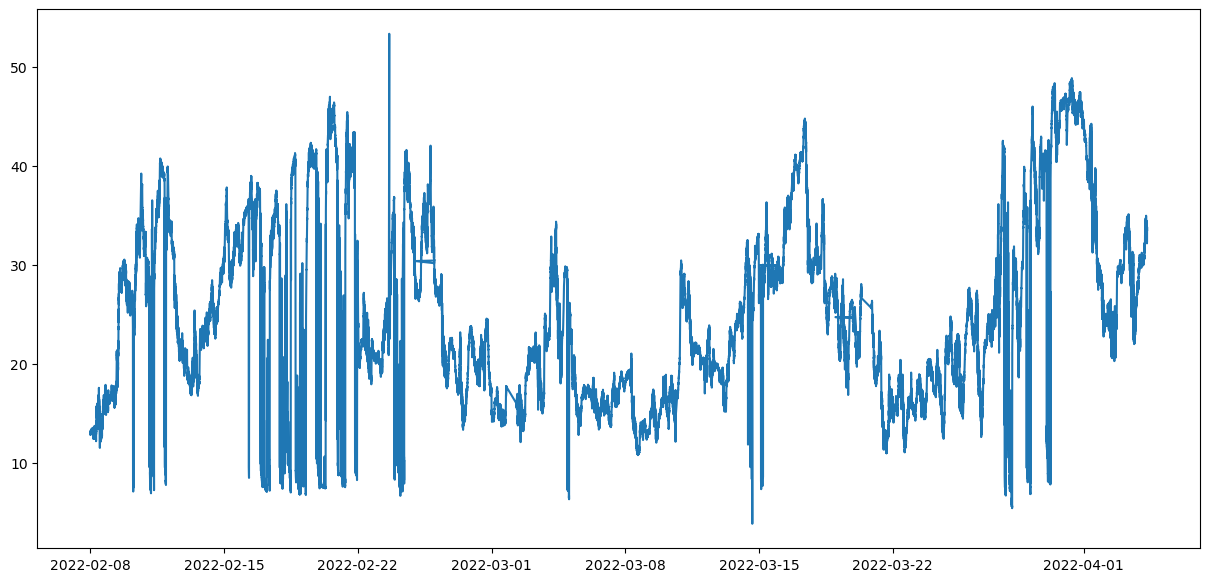

In [38]:
with pd.HDFStore('../Data/RHT_CCNC.hdf5',mode='r') as store:
    RHT_CCNC = store['dataset']

plt.figure(figsize=(15,7))
plt.plot(RHT_CCNC['RH_CCNC'])

print(RHT_CCNC['RH_CCNC'].mean(),RHT_CCNC['RH_CCNC'].std())

# Effect of GFAS loss correction
Compare effective diameter with and without inlet-loss correction.


In [39]:
### effect of loss correction for GFAS (on ED_2)
varx=Functions_Neuberger26.keepData(GFAS_processed,fog_times['starttime_fog'],fog_times['endtime_fog'])['ED_2']
vary=Functions_Neuberger26.keepData(GFAS_processed_corrected,fog_times['starttime_fog'],fog_times['endtime_fog'])['ED_2']
nanmask=~np.isnan(varx)&~np.isnan(vary)&~np.isinf(varx)&~np.isinf(vary)

print((vary[nanmask].median()-varx[nanmask].median())/varx[nanmask].median()*100)


### effect of loss correction for GFAS (on Nconc_2)
varx=Functions_Neuberger26.keepData(GFAS_processed,fog_times['starttime_fog'],fog_times['endtime_fog'])['Nconc_2']
vary=Functions_Neuberger26.keepData(GFAS_processed_corrected,fog_times['starttime_fog'],fog_times['endtime_fog'])['Nconc_2']
nanmask=~np.isnan(varx)&~np.isnan(vary)&~np.isinf(varx)&~np.isinf(vary)

print((vary[nanmask].median()-varx[nanmask].median())/varx[nanmask].median()*100)


4.146832019688696
1.8631120209935945


# Main figures

Text(0.02, 0.94, '(a)')

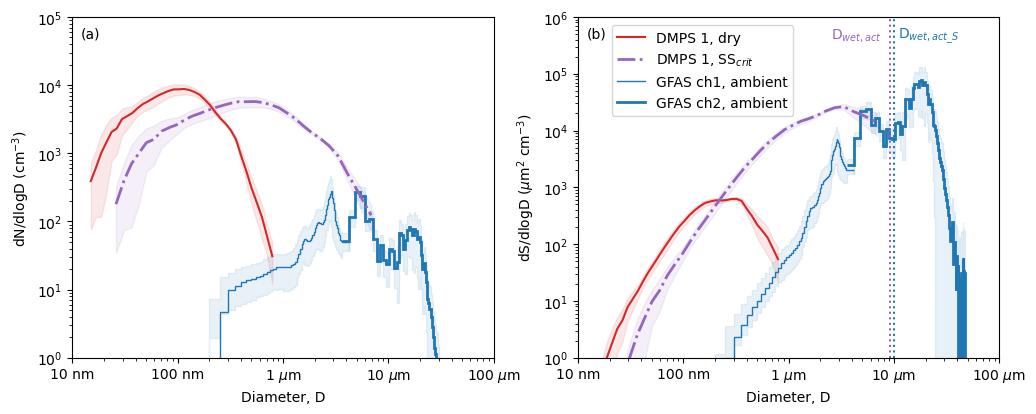

In [40]:
Dpmin_R100_opt=0.02*10**(-6)
Dp_processed=GFAS_processed_corrected_fog.loc[:,'0.00000005':'0.00007200'].columns.astype('float')

fig,ax=plt.subplots(figsize=(10,4))
fig.tight_layout()
### N 6 ###
i=6
Dp_R100_opt=(D100_opt.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i]].mean(axis=0)+shift(D100_opt.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i]].mean(axis=0),1,cval=Dpmin_R100_opt))/2
dlogDp_R100_opt=np.log10(D100_opt.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i]].mean(axis=0))-shift(np.log10(D100_opt.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i]].mean(axis=0)),1,cval=np.nan)
dlogDp_R100_opt[0]=np.log10(D100_opt.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i]].mean(axis=0).values[0])-np.log10(Dpmin_R100_opt)
Dp_RSS_med_opt=(DSS_med_opt.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i]].dropna(axis=1).mean(axis=0)+shift(DSS_med_opt.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i]].dropna(axis=1).mean(axis=0),1,cval=Dpmin_R100_opt))/2
dlogDp_RSS_med_opt=np.log10(DSS_med_opt.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i]].dropna(axis=1).mean(axis=0))-shift(np.log10(DSS_med_opt.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i]].dropna(axis=1).mean(axis=0)),1,cval=np.nan)
dlogDp_RSS_med_opt[0]=np.log10(DSS_med_opt.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i]].dropna(axis=1).mean(axis=0).values[0])-np.log10(Dpmin_R100_opt)
Dmax=len(DSS_med_opt.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i]].dropna(axis=1).mean(axis=0))
ax1=plt.subplot(122)
ax1.plot(DMPS_R.iloc[:,2:].columns.astype(float),
         math.pi*(Dp_R*10**6)**2*DMPS_R.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],:].iloc[:,2:].mean(axis=0),
         c='C3',label='DMPS 1, dry')
ax1.fill_between(DMPS_R.iloc[:,2:].columns.astype(float),
                 math.pi*(Dp_R*10**6)**2*DMPS_R.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],:].iloc[:,2:].mean(axis=0)+math.pi*(Dp_R*10**6)**2*DMPS_R.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],:].iloc[:,2:].std(axis=0),
                 math.pi*(Dp_R*10**6)**2*DMPS_R.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],:].iloc[:,2:].mean(axis=0)-math.pi*(Dp_R*10**6)**2*DMPS_R.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],:].iloc[:,2:].std(axis=0),
                 color='C3',alpha=0.1)
ax1.plot(DSS_med_opt.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],:].dropna(axis=1).mean(axis=0),
         math.pi*(Dp_RSS_med_opt*10**6)**2*(dlogDp_R[:Dmax]*DMPS_R.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],:].iloc[:,2:Dmax+2].mean(axis=0)).values/dlogDp_RSS_med_opt,
         c='C4',lw=2,ls='-.',label='DMPS 1, SS$_{crit}$')
ax1.fill_between(DSS_med_opt.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],:].dropna(axis=1).mean(axis=0),
         math.pi*(Dp_RSS_med_opt*10**6)**2*(dlogDp_R[:Dmax]*DMPS_R.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],:].iloc[:,2:Dmax+2].mean(axis=0)).values/dlogDp_RSS_med_opt+math.pi*(Dp_RSS_med_opt*10**6)**2*(dlogDp_R[:Dmax]*DMPS_R.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],:].iloc[:,2:Dmax+2].std(axis=0)).values/dlogDp_RSS_med_opt,
         math.pi*(Dp_RSS_med_opt*10**6)**2*(dlogDp_R[:Dmax]*DMPS_R.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],:].iloc[:,2:Dmax+2].mean(axis=0)).values/dlogDp_RSS_med_opt-math.pi*(Dp_RSS_med_opt*10**6)**2*(dlogDp_R[:Dmax]*DMPS_R.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],:].iloc[:,2:Dmax+2].std(axis=0)).values/dlogDp_RSS_med_opt,
         color='C4',alpha=0.1)
ax1.stairs(math.pi*(Dpmid_processed[:72]*10**6)**2*GFAS_processed_corrected_fog.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],'0.00000005':'0.00007200'].iloc[:,:72].dropna().mean(axis=0),
            edges=Dp_processed[:73],baseline=None,
            color='C0',label='GFAS ch1, ambient')
ax1.fill_between(x=Dp_processed[:73],
                 y1=math.pi*(Dpmid_processed[:73]*10**6)**2*GFAS_processed_corrected_fog.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],'0.00000005':'0.00007200'].iloc[:,:73].dropna().mean(axis=0)-math.pi*(Dpmid_processed[:73]*10**6)**2*GFAS_processed_corrected_fog.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],'0.00000005':'0.00007200'].iloc[:,:73].dropna().std(axis=0),
                 y2=math.pi*(Dpmid_processed[:73]*10**6)**2*GFAS_processed_corrected_fog.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],'0.00000005':'0.00007200'].iloc[:,:73].dropna().mean(axis=0)+math.pi*(Dpmid_processed[:73]*10**6)**2*GFAS_processed_corrected_fog.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],'0.00000005':'0.00007200'].iloc[:,:73].dropna().std(axis=0),
                 step='pre',color='C0',alpha=0.1)
ax1.stairs(math.pi*(Dpmid_processed[72:]*10**6)**2*GFAS_processed_corrected_fog.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],'0.00000005':'0.00007200'].iloc[:,72:].dropna().mean(axis=0),
            edges=Dp_processed[71:],baseline=None,
            color='C0',lw=2,label='GFAS ch2, ambient')
ax1.fill_between(x=Dp_processed[72:],
                 y1=math.pi*(Dpmid_processed[72:]*10**6)**2*GFAS_processed_corrected_fog.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],'0.00000005':'0.00007200'].iloc[:,72:].dropna().mean(axis=0)-math.pi*(Dpmid_processed[72:]*10**6)**2*GFAS_processed_corrected_fog.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],'0.00000005':'0.00007200'].iloc[:,72:].dropna().std(axis=0),
                 y2=math.pi*(Dpmid_processed[72:]*10**6)**2*GFAS_processed_corrected_fog.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],'0.00000005':'0.00007200'].iloc[:,72:].dropna().mean(axis=0)+math.pi*(Dpmid_processed[72:]*10**6)**2*GFAS_processed_corrected_fog.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],'0.00000005':'0.00007200'].iloc[:,72:].dropna().std(axis=0),
                 step='pre',color='C0',alpha=0.1)
ax1.legend(loc=[0.08,0.71])
ax1.axvline(event_1m.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],'D_crit'].mean()*10**(-6),
            c='C4',ls=':')
ax1.annotate('D$_{wet,act}$',xy=(0.6,0.94), xycoords='axes fraction',color='C4')
ax1.axvline(GFAS_processed_corrected_fog_fitted_1m.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],'D_Sact'].mean(),
            c='C0',ls=':')
ax1.annotate('D$_{wet,act\_S}$',xy=(0.76,0.94), xycoords='axes fraction',color='C0')
ax1.set_xlabel('Diameter, D')
ax1.set_ylabel('dS/dlogD ($\mu$m$^2$ cm$^{-3}$)')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlim(10**(-8),10**(-4))
ax1.set_ylim(10**0,10**6)
ax1.set_xticks(ticks=[10**(-8),10**(-7),10**(-6),10**(-5),10**(-4)],
           labels=['10 nm','100 nm','1 $\mu$m','10 $\mu$m','100 $\mu$m'])
ax1.annotate('(b)',xy=(0.02,0.94), xycoords='axes fraction')

ax3=plt.subplot(121)
ax3.plot(DMPS_R.iloc[:,2:].columns.astype(float),
         DMPS_R.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],:].iloc[:,2:].mean(axis=0),
         c='C3',label='DMPS 1, dry')
ax3.fill_between(DMPS_R.iloc[:,2:].columns.astype(float),
                 DMPS_R.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],:].iloc[:,2:].mean(axis=0)+DMPS_R.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],:].iloc[:,2:].std(axis=0),
                 DMPS_R.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],:].iloc[:,2:].mean(axis=0)-DMPS_R.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],:].iloc[:,2:].std(axis=0),
                 color='C3',alpha=0.1)
ax3.plot(DSS_med_opt.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],:].dropna(axis=1).mean(axis=0),
         (dlogDp_R[:Dmax]*DMPS_R.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],:].iloc[:,2:Dmax+2].mean(axis=0)).values/dlogDp_RSS_med_opt,
         c='C4',lw=2,ls='-.',label='DMPS 1, SS$_{crit}$')
ax3.fill_between(DSS_med_opt.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],:].dropna(axis=1).mean(axis=0),
         (dlogDp_R[:Dmax]*DMPS_R.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],:].iloc[:,2:Dmax+2].mean(axis=0)).values/dlogDp_RSS_med_opt+(dlogDp_R[:Dmax]*DMPS_R.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],:].iloc[:,2:Dmax+2].std(axis=0)).values/dlogDp_RSS_med_opt,
         (dlogDp_R[:Dmax]*DMPS_R.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],:].iloc[:,2:Dmax+2].mean(axis=0)).values/dlogDp_RSS_med_opt-(dlogDp_R[:Dmax]*DMPS_R.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],:].iloc[:,2:Dmax+2].std(axis=0)).values/dlogDp_RSS_med_opt,
         color='C4',alpha=0.1)
ax3.stairs(GFAS_processed_corrected_fog.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],'0.00000005':'0.00007200'].iloc[:,:72].dropna().mean(axis=0),
            edges=Dp_processed[:73],baseline=None,
            color='C0',label='GFAS ch1, ambient')
ax3.fill_between(x=Dp_processed[:73],
                 y1=GFAS_processed_corrected_fog.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],'0.00000005':'0.00007200'].iloc[:,:73].dropna().mean(axis=0)-GFAS_processed_corrected_fog.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],'0.00000005':'0.00007200'].iloc[:,:73].dropna().std(axis=0),
                 y2=GFAS_processed_corrected_fog.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],'0.00000005':'0.00007200'].iloc[:,:73].dropna().mean(axis=0)+GFAS_processed_corrected_fog.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],'0.00000005':'0.00007200'].iloc[:,:73].dropna().std(axis=0),
                 step='pre',color='C0',alpha=0.1)
ax3.stairs(GFAS_processed_corrected_fog.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],'0.00000005':'0.00007200'].iloc[:,72:].dropna().mean(axis=0),
            edges=Dp_processed[71:],baseline=None,
            color='C0',lw=2,label='GFAS ch2, ambient')
ax3.fill_between(x=Dp_processed[72:],
                 y1=GFAS_processed_corrected_fog.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],'0.00000005':'0.00007200'].iloc[:,72:].dropna().mean(axis=0)-GFAS_processed_corrected_fog.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],'0.00000005':'0.00007200'].iloc[:,72:].dropna().std(axis=0),
                 y2=GFAS_processed_corrected_fog.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],'0.00000005':'0.00007200'].iloc[:,72:].dropna().mean(axis=0)+GFAS_processed_corrected_fog.loc[fog_times['endtime_fog'][i]-pd.Timedelta('4H'):fog_times['endtime_fog'][i],'0.00000005':'0.00007200'].iloc[:,72:].dropna().std(axis=0),
                 step='pre',color='C0',alpha=0.1)
ax3.set_xlabel('Diameter, D')
ax3.set_ylabel('dN/dlogD (cm$^{-3}$)')
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_xlim(10**(-8),10**(-4))
ax3.set_ylim(10**0,10**5)
ax3.set_xticks(ticks=[10**(-8),10**(-7),10**(-6),10**(-5),10**(-4)],
           labels=['10 nm','100 nm','1 $\mu$m','10 $\mu$m','100 $\mu$m'])
ax3.annotate('(a)',xy=(0.02,0.94), xycoords='axes fraction')
#plt.savefig('Fig_1.jpg',bbox_inches='tight',dpi=300)


[6.68167799e+03 2.26803633e+00 8.34009875e+01]


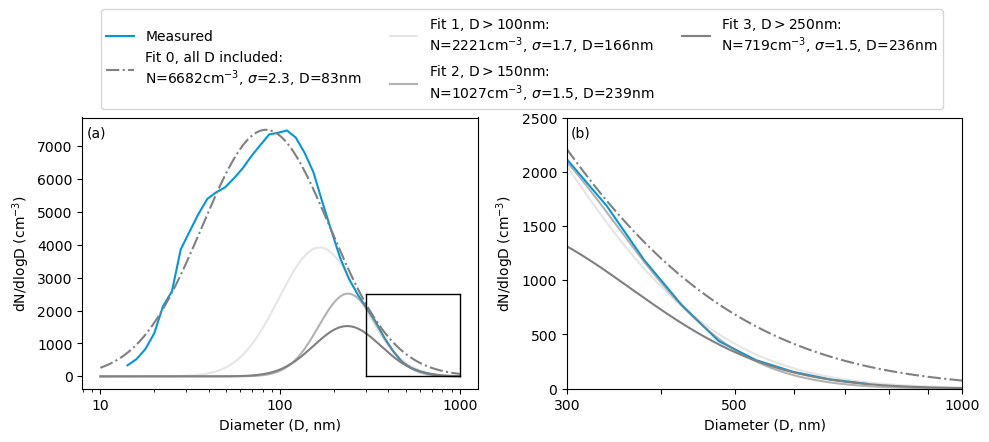

In [41]:
from scipy.optimize import curve_fit
N = 21
test_cmaps = ['nipy_spectral']
segmented_cmaps = [mpl.colors.ListedColormap(plt.get_cmap(t)(np.linspace(0,1,N))) for t in test_cmaps]

i=6
f1=np.array([[5000,1.9,48.2],[5686.397,2.018,47.291],[2221.086,1.683,82.957],[1027.048,1.455,119.348],[718.905,1.54,118.116]])

fig,ax=plt.subplots(figsize=(10,3.5))
ax2=plt.subplot(121)
ax2.plot(Dp_R*10**9,DMPS_R.loc['2022-02-18 17:07':'2022-02-19 06:56',:].iloc[:,2:].mean(),c=segmented_cmaps[0](6))
popt1, pcov1 = curve_fit(Functions_Neuberger26.lognorm,Dp_R*10**9,(DMPS_R.loc['2022-02-18 17:07':'2022-02-19 06:56',:].iloc[:,2:].mean()), [6000,2,100])
print(popt1)
ax2.plot(np.linspace(10,1000,10000),
         Functions_Neuberger26.lognorm(np.linspace(10,1000,10000),popt1[0],popt1[1],popt1[2]),c='gray',ls='-.')
ax2.plot(np.linspace(10,1000,1000),
         Functions_Neuberger26.lognorm(np.linspace(10,1000,1000),f1[2,0],f1[2,1],f1[2,2]*2),c='gray',alpha=0.2)
ax2.plot(np.linspace(10,1000,1000),
         Functions_Neuberger26.lognorm(np.linspace(10,1000,1000),f1[3,0],f1[3,1],f1[3,2]*2),c='gray',alpha=0.6)
ax2.plot(np.linspace(10,1000,1000),
         Functions_Neuberger26.lognorm(np.linspace(10,1000,1000),f1[4,0],f1[4,1],f1[4,2]*2),c='gray',alpha=1.0)
ax2.plot([300,300],[0,2500],c='black',lw=1)
ax2.plot([300,1000],[2500,2500],c='black',lw=1)
ax2.plot([1000,1000],[2500,0],c='black',lw=1)
ax2.plot([1000,300],[0,0],c='black',lw=1)
ax2.set_xlabel('Diameter (D, nm)')
ax2.set_ylabel('dN/dlogD (cm$^{-3}$)')
ax2.set_xscale('log')
ax2.set_xticks([10,100,1000])
ax2.set_xticklabels([10,100,1000])
ax2.annotate('(a)',xy=(0.01,0.93), xycoords='axes fraction')

ax3=plt.subplot(122)
ax3.plot(Dp_R*10**9,DMPS_R.loc['2022-02-18 17:07':'2022-02-19 06:56',:].iloc[:,2:].mean(),c=segmented_cmaps[0](6),label='Measured')
ax3.plot(np.linspace(10,1000,10000),
         Functions_Neuberger26.lognorm(np.linspace(10,1000,10000),popt1[0],popt1[1],popt1[2]),c='gray',ls='-.',
         label='Fit 0, all D included:\nN=%.0fcm$^{-3}$, $\sigma$=%.1f, D=%.0fnm'%(popt1[0],popt1[1],popt1[2]))
ax3.plot(np.linspace(10,1000,1000),
         Functions_Neuberger26.lognorm(np.linspace(10,1000,1000),f1[2,0],f1[2,1],f1[2,2]*2),c='gray',alpha=0.2,label='Fit 1, D$>$100nm:\nN=%.0fcm$^{-3}$, $\sigma$=%.1f, D=%.0fnm'%(f1[2,0],f1[2,1],f1[2,2]*2))
ax3.plot(np.linspace(10,1000,1000),
         Functions_Neuberger26.lognorm(np.linspace(10,1000,1000),f1[3,0],f1[3,1],f1[3,2]*2),c='gray',alpha=0.6,label='Fit 2, D$>$150nm:\nN=%.0fcm$^{-3}$, $\sigma$=%.1f, D=%.0fnm'%(f1[3,0],f1[3,1],f1[3,2]*2))
ax3.plot(np.linspace(10,1000,1000),
         Functions_Neuberger26.lognorm(np.linspace(10,1000,1000),f1[4,0],f1[4,1],f1[4,2]*2),c='gray',alpha=1.0,label='Fit 3, D$>$250nm:\nN=%.0fcm$^{-3}$, $\sigma$=%.1f, D=%.0fnm'%(f1[4,0],f1[4,1],f1[4,2]*2))
ax3.set_xlabel('Diameter (D, nm)')
ax3.set_ylabel('dN/dlogD (cm$^{-3}$)')
ax3.set_xscale('log')
ax3.set_xticks(np.linspace(300,1000,8))
ax3.set_xticklabels([300,'',500,'','','','',1000])
ax3.set_xlim(300,1000)
ax3.set_ylim(0,2500)
ax3.annotate('(b)',xy=(0.01,0.93), xycoords='axes fraction')
fig.tight_layout()
fig.legend(bbox_to_anchor=(0.955,1.27),ncols=3)
#plt.savefig('Fig_2.png',bbox_inches='tight',dpi=300)


(-0.5, 735.5, 1281.5, -0.5)

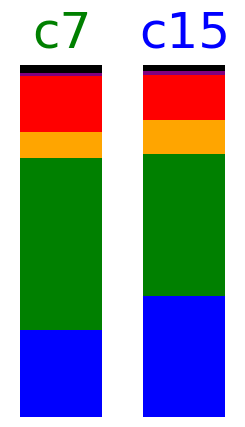

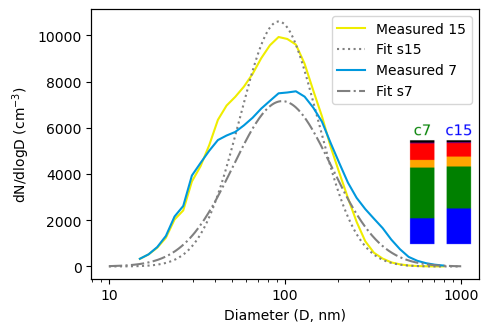

In [42]:
N = 21
test_cmaps = ['nipy_spectral']
segmented_cmaps = [mpl.colors.ListedColormap(plt.get_cmap(t)(np.linspace(0,1,N))) for t in test_cmaps]

ax1=plt.subplot(121)
Functions_Neuberger26.stacked_barchart(ax1, 0.3, AMS.loc[fog_times['starttime_fog'][6]:fog_times['endtime_fog'][6]][['OA (ug/m3)','NO3 (ug/m3)','SO4 (ug/m3)','NH4 (ug/m3)','Cl (ug/m3)','rBC (ug/m3)']].median()/AMS.loc[fog_times['starttime_fog'][6]:fog_times['endtime_fog'][6]][['OA (ug/m3)','NO3 (ug/m3)','SO4 (ug/m3)','NH4 (ug/m3)','Cl (ug/m3)','rBC (ug/m3)']].median().sum(), ['blue','green','orange','red','purple','black'])
Functions_Neuberger26.stacked_barchart(ax1, 0.45, AMS.loc[fog_times['starttime_fog'][14]:fog_times['endtime_fog'][14]][['OA (ug/m3)','NO3 (ug/m3)','SO4 (ug/m3)','NH4 (ug/m3)','Cl (ug/m3)','rBC (ug/m3)']].median()/AMS.loc[fog_times['starttime_fog'][14]:fog_times['endtime_fog'][14]][['OA (ug/m3)','NO3 (ug/m3)','SO4 (ug/m3)','NH4 (ug/m3)','Cl (ug/m3)','rBC (ug/m3)']].median().sum(), ['blue','green','orange','red','purple','black'])
plt.axis('off')
ax1.annotate('c7',xy=(0.265,1.05), xycoords='data',fontsize=36,c='green')
ax1.annotate('c15',xy=(0.395,1.05), xycoords='data',fontsize=36,c='blue')
plt.savefig('Fig_10_inlet.png',bbox_inches='tight',dpi=300)


fig,ax=plt.subplots(figsize=(5,3.5))
ax1=plt.subplot(111)
ax1.plot(DMPS_R.loc[fog_times['starttime_fog'][14]:fog_times['endtime_fog'][15],:].iloc[:,2:].columns.astype('float')*10**9,
         DMPS_R.loc[fog_times['starttime_fog'][14]:fog_times['endtime_fog'][15],:].iloc[:,2:].mean(),c=segmented_cmaps[0](14),label='Measured 15')
ax1.plot(np.linspace(10,1000,1000),
         Functions_Neuberger26.lognorm(np.linspace(10,1000,1000), 5850, 1.66, 46*2),c='gray',ls=':',label='Fit s15')
ax1.plot(DMPS_R.loc[fog_times['starttime_fog'][6]:fog_times['endtime_fog'][8],:].iloc[:,2:].columns.astype('float')*10**9,
         DMPS_R.loc[fog_times['starttime_fog'][6]:fog_times['endtime_fog'][8],:].iloc[:,2:].mean(),c=segmented_cmaps[0](6),label='Measured 7')
ax1.plot(np.linspace(10,1000,1000),
         Functions_Neuberger26.lognorm(np.linspace(10,1000,1000), 5000, 1.9, 48.2*2),c='gray',ls='-.',label='Fit s7')
ax0=ax1.twinx()
ax0.get_yaxis().set_visible(False)
ax1.set_xlabel('Diameter (D, nm)')
ax1.set_ylabel('dN/dlogD (cm$^{-3}$)')
ax1.set_xscale('log')
ax1.set_xticks([10,100,1000])
ax1.set_xticklabels([10,100,1000])
ymin,ymax=ax1.get_ylim()
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax0.get_legend_handles_labels()
all_handles = handles1 + handles2
all_labels = labels1 + labels2
ax1.legend(all_handles, all_labels)
newax = fig.add_axes([0.75, 0.2, 0.4, 0.36], anchor='SW')
im = plt.imread('/Fig_10_inlet.png')
newax.imshow(im)
newax.axis('off')
#plt.savefig('Fig_S10.png',bbox_inches='tight',dpi=300)

In [43]:
for i in fog_times.index:
    print(i,int(round((fog_times['endtime_fog'][i]-fog_times['starttime_fog'][i]).seconds/60,0)))

0 36
1 240
2 36
3 108
4 372
5 792
6 324
7 168
8 204
9 120
10 360
11 384
12 96
13 84
14 420
15 84
16 108
17 528
18 216
19 96
20 72


In [44]:
DMPS_R.iloc[:,-4:]

,5.637E-7,6.314E-7,7.071E-7,7.920E-7
datetime,,,,
2022-02-08 00:10:06,39.767734,1.950871e+01,4.516991e+00,1.812037e-29
2022-02-08 00:22:06,33.858801,3.318735e+01,1.213781e+01,4.186466e+00
2022-02-08 00:34:07,43.253800,2.540026e+01,1.618717e+01,1.252741e+01
2022-02-08 00:46:07,60.643238,3.255209e+01,2.921913e+01,1.161933e+01
2022-02-08 00:58:08,43.274246,3.319760e+01,2.020570e+01,1.046359e+01
...,...,...,...,...
2022-04-04 06:51:08,3.758000,3.903792e+00,8.097696e+00,2.093749e+00
2022-04-04 07:03:08,3.765156,3.905841e+00,1.831463e-29,2.092717e+00
2022-04-04 07:15:09,7.510888,1.855582e-29,1.831463e-29,2.093749e+00


Text(0.02, 0.91, '(f)')

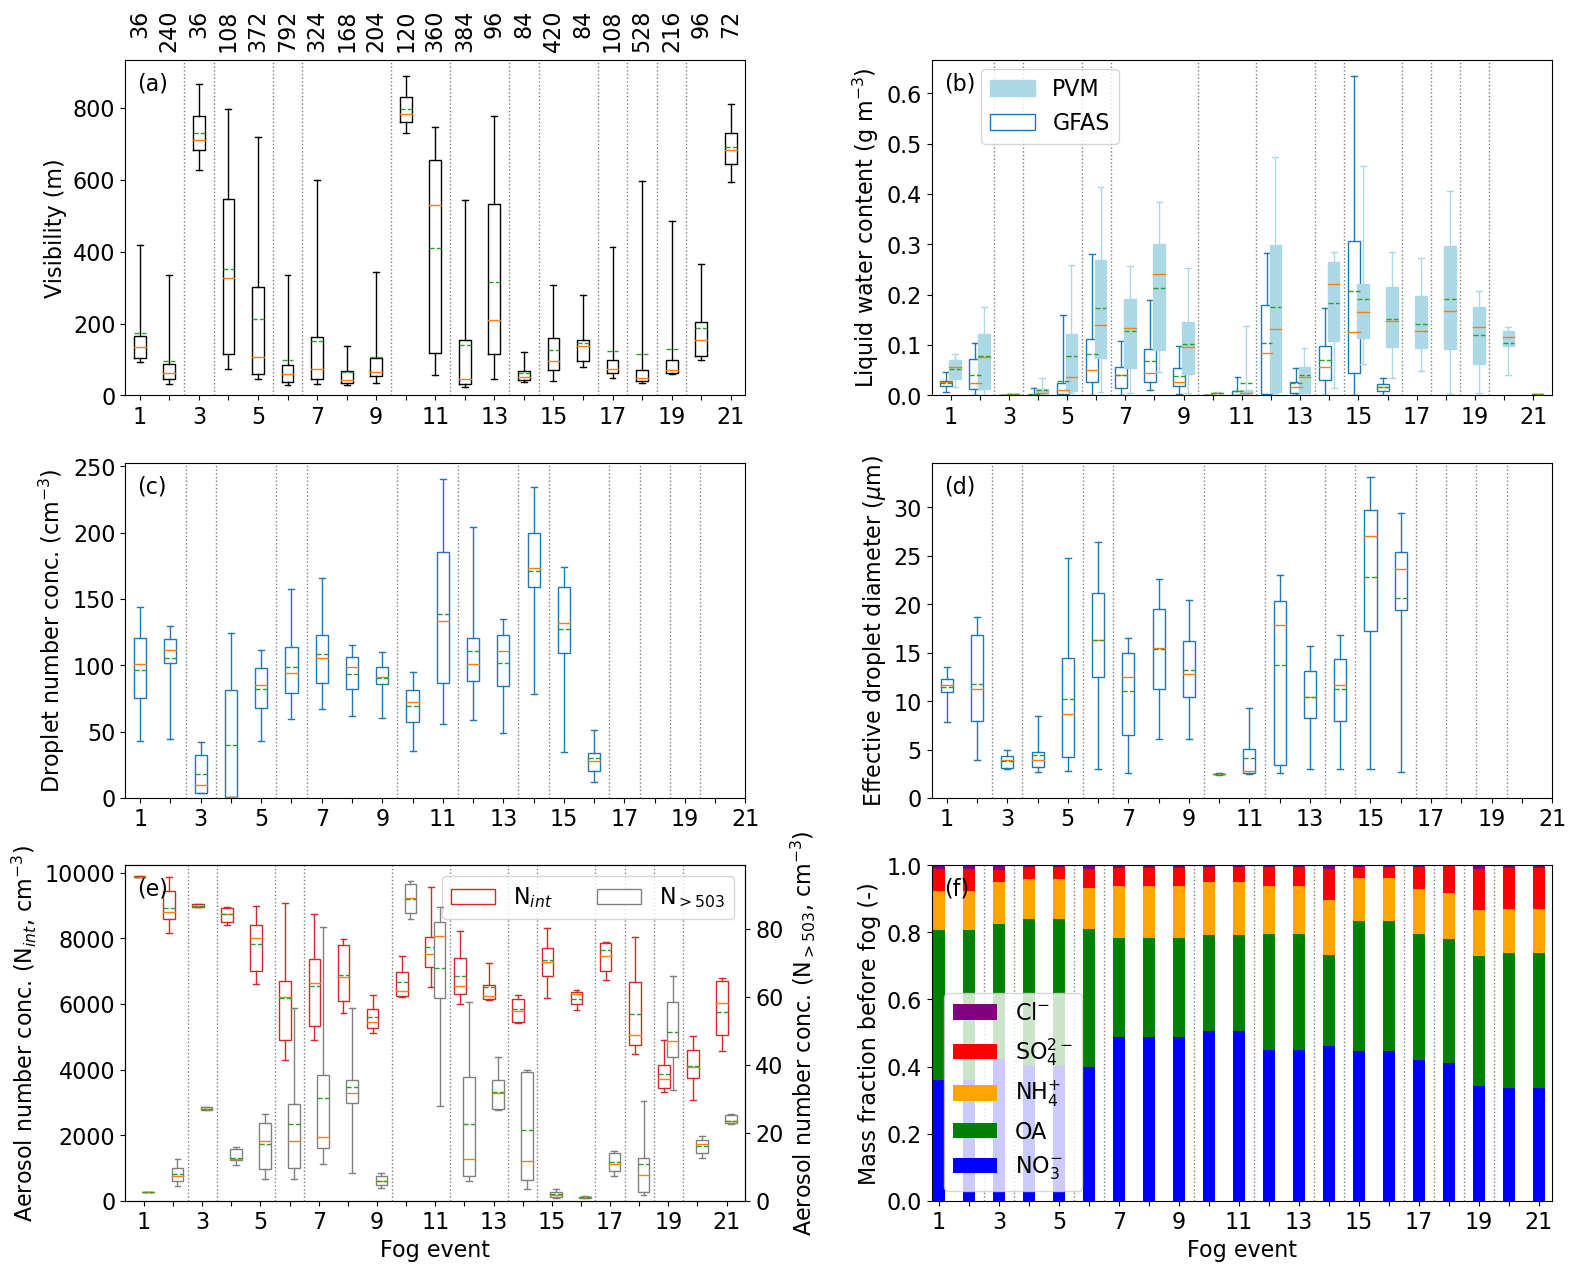

In [45]:
resample_S=60
fig,ax=plt.subplots(figsize=(15,12))
fig.tight_layout()
fig.subplots_adjust(wspace=0.3)
### Visibility ###
ax2=plt.subplot(321)
for i in fog_times.index:
    ax2.boxplot(GCVI.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'visiblty'].resample('%iS'%resample_S).median().values, 
               positions = [i],showfliers=False,widths=0.4,whis=[5,95],meanline=True,showmeans=True)
    ax2.text(i, 1.15, str(int(round((fog_times['endtime_fog'][i] - fog_times['starttime_fog'][i]).seconds / 60, 0))),
             transform=ax2.get_xaxis_transform(),
             rotation=90,
             ha='center', va='top',
             fontsize=16)
for l in [2.5,3.5,5.5,6.5,9.5,11.5,13.5,14.5,16.5,17.5,18.5,19.5]:
    ax2.axvline(x=l-1,c='grey',lw=1,ls=':')
ax2.set_ylabel('Visibility (m)',fontsize=16)
ax2.tick_params(axis='both',which='major', labelsize=16)
ax2.set_ylim(0,)
ax2.set_xticks(np.linspace(0,20,21).astype(int))
ax2.set_xticklabels(np.linspace(1,21,21).astype(int));
for label in ax2.xaxis.get_ticklabels()[1::2]:
    label.set_visible(False)
ax2.annotate('(a)',xy=(0.02,0.91), xycoords='axes fraction', size=16)

### LWC ###
ax1=plt.subplot(322)
for i in fog_times.index:
    if (i<16) and (LWC_processed_corrected.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'Volume Conc (um^3/cc)'].count()>5):
        bp_GFAS=ax1.boxplot(LWC_processed_corrected.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'Volume Conc (um^3/cc)'].values, 
                            positions = [i-0.15],showfliers=False,widths=0.4,whis=[5,95],meanline=True,showmeans=True,
                            patch_artist=True,
                            boxprops=dict(color='C0',facecolor='white'),
                            whiskerprops=dict(color='C0'),capprops=dict(color='C0'))
    bp_PVM=ax1.boxplot(LWC_processed_corrected.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'LWC (g m^-3)'].values, 
                       positions = [i+0.15],showfliers=False,widths=0.4,whis=[5,95],meanline=True,showmeans=True,
                       patch_artist=True,
                       boxprops=dict(color='lightblue',facecolor='lightblue'),
                       whiskerprops=dict(color='lightblue'),capprops=dict(color='lightblue'))
for l in [2.5,3.5,5.5,6.5,9.5,11.5,13.5,14.5,16.5,17.5,18.5,19.5]:
    ax1.axvline(x=l-1,c='grey',lw=1,ls=':')
ax1.set_ylabel('Liquid water content (g m$^{-3}$)',fontsize=16)
ax1.tick_params(axis='both',which='major', labelsize=16)
ax1.set_ylim(0,)
ax1.set_xticks(np.linspace(0,20,21).astype(int))
ax1.set_xticklabels(np.linspace(1,21,21).astype(int))
for label in ax1.xaxis.get_ticklabels()[1::2]:
    label.set_visible(False)
ax1.legend([bp_PVM["boxes"][0],bp_GFAS["boxes"][0]], ['PVM','GFAS'], loc=[0.08,0.75],fontsize=16)
ax1.annotate('(b)',xy=(0.02,0.91), xycoords='axes fraction', size=16)

### CDNC ###
ax3=plt.subplot(323)
for i in fog_times.index[:16]:
    if (i!=16) and (GFAS_processed_corrected.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'Nconc_2'].resample('%iS'%resample_S).median().dropna(axis=0).count()>5):
        ax3.boxplot(GFAS_processed_corrected.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'Nconc_2'].resample('%iS'%resample_S).median().dropna(axis=0).values, 
                   positions = [i],showfliers=False,widths=0.4,whis=[5,95],meanline=True,showmeans=True,patch_artist=True,
                   boxprops=dict(color='C0',facecolor='white'),whiskerprops=dict(color='C0'),capprops=dict(color='C0'))
for l in [2.5,3.5,5.5,6.5,9.5,11.5,13.5,14.5,16.5,17.5,18.5,19.5]:
    ax3.axvline(x=l-1,c='grey',lw=1,ls=':')
ax3.set_ylabel('Droplet number conc. (cm$^{-3}$)',fontsize=16)
ax3.tick_params(axis='both',which='major', labelsize=16)
ax3.set_ylim(0,)
ax3.set_xticks(np.linspace(0,20,21).astype(int))
ax3.set_xticklabels(np.linspace(1,21,21).astype(int));
for label in ax3.xaxis.get_ticklabels()[1::2]:
    label.set_visible(False)
ax3.annotate('(c)',xy=(0.02,0.91), xycoords='axes fraction', size=16)

### ED ###
ax4=plt.subplot(324)
for i in fog_times.index[:16]:
    if (i!=16) and (GFAS_processed_corrected.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'ED_2'].resample('%iS'%resample_S).median().dropna(axis=0).count()>5):
        ax4.boxplot(GFAS_processed_corrected.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'ED_2'].resample('%iS'%resample_S).median().dropna(axis=0).values, 
                   positions = [i],showfliers=False,widths=0.4,whis=[5,95],meanline=True,showmeans=True,patch_artist=True,
                   boxprops=dict(color='C0',facecolor='white'),whiskerprops=dict(color='C0'),capprops=dict(color='C0'))
for l in [2.5,3.5,5.5,6.5,9.5,11.5,13.5,14.5,16.5,17.5,18.5,19.5]:
    ax4.axvline(x=l-1,c='grey',lw=1,ls=':')
ax4.set_ylabel('Effective droplet diameter ($\mu$m)',fontsize=16)
ax4.tick_params(axis='both',which='major', labelsize=16)
ax4.set_ylim(0,)
ax4.set_xticks(np.linspace(0,20,21).astype(int))
ax4.set_xticklabels(np.linspace(1,21,21).astype(int));
for label in ax4.xaxis.get_ticklabels()[1::2]:
    label.set_visible(False)
ax4.annotate('(d)',xy=(0.02,0.91), xycoords='axes fraction', size=16)


### Nconc ###
ax9=plt.subplot(325)
for i in fog_times.index:
    bp_Ntot=ax9.boxplot((dlogDp_R*DMPS_R.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],:].iloc[:,2:]).sum(axis=1,min_count=36).values, 
                positions = [i-0.15],showfliers=False,widths=0.4,whis=[5,95],meanline=True,showmeans=True,patch_artist=True,
                boxprops=dict(color='C3',facecolor='white'),whiskerprops=dict(color='C3'),capprops=dict(color='C3'))
ax9b = ax9.twinx()
for i in fog_times.index:
    bp_N500=ax9b.boxplot((dlogDp_R[-4:]*DMPS_R.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],:].iloc[:,-4:]).sum(axis=1,min_count=4).values, 
                positions = [i+0.15],showfliers=False,widths=0.4,whis=[5,95],meanline=True,showmeans=True,patch_artist=True,
                boxprops=dict(color='gray',facecolor='white'),whiskerprops=dict(color='gray'),capprops=dict(color='gray'))
for l in [2.5,3.5,5.5,6.5,9.5,11.5,13.5,14.5,16.5,17.5,18.5,19.5]:
    ax9.axvline(x=l-1,c='grey',lw=1,ls=':')
ax9.set_xlabel('Fog event',fontsize=16)
ax9.set_ylabel('Aerosol number conc. (N$_{int}$, cm$^{-3}$)',fontsize=16)
ax9b.set_ylabel('Aerosol number conc. (N$_{>503}$, cm$^{-3}$)',fontsize=16)
ax9.tick_params(axis='both',which='major', labelsize=16)
ax9.set_ylim(0,)
ax9b.tick_params(axis='both',which='major', labelsize=16)
ax9b.set_ylim(0,)
ax9.set_xticks(np.linspace(0,20,21).astype(int))
ax9.set_xticklabels(np.linspace(1,21,21).astype(int));
for label in ax9.xaxis.get_ticklabels()[1::2]:
    label.set_visible(False)
ax9.legend([bp_Ntot["boxes"][0],bp_N500["boxes"][0]], ['N$_{int}$','N$_{>503}$'], loc='upper right',ncols=2,fontsize=16)
ax9.annotate('(e)',xy=(0.02,0.91), xycoords='axes fraction', size=16)


### AMS contributions ###
ax7=plt.subplot(326)
ax7=pd.DataFrame([AMS_ratios_before.loc[:,'NO3'],AMS_ratios_before.loc[:,'OA'],AMS_ratios_before.loc[:,'NH4'],AMS_ratios_before.loc[:,'SO4'],
                  AMS_ratios_before.loc[:,'Cl']]).transpose().plot(kind='bar',stacked=True,rot=0,align='edge',width=-0.2,
                                                            color=['blue','green','orange','red','purple'],legend=True,ax=ax7)
ax7=pd.DataFrame([AMS_ratios_before.loc[:,'NO3'],AMS_ratios_before.loc[:,'OA'],AMS_ratios_before.loc[:,'NH4'],AMS_ratios_before.loc[:,'SO4'],
                  AMS_ratios_before.loc[:,'Cl']]).transpose().plot(kind='bar',stacked=True,rot=0,align='edge',width=0.2,
                                                            color=['blue','green','orange','red','purple'],legend=False,ax=ax7)
handles, labels = ax7.get_legend_handles_labels()
for l in [2.5,3.5,5.5,6.5,9.5,11.5,13.5,14.5,16.5,17.5,18.5,19.5]:
    ax7.axvline(x=l-1,c='grey',lw=1,ls=':')
ax7.legend(handles[::-1], ['NO$_3^{-}$','OA','NH$_4^{+}$','SO$_4^{2-}$','Cl$^{-}$'][::-1], 
           loc=[0.02,0.03],fontsize=16)
ax7.set_xlabel('Fog event',fontsize=16)
ax7.set_ylabel('Mass fraction before fog (-)',fontsize=16)
ax7.tick_params(axis='both',which='major', labelsize=16)
ax7.set_ylim(0,1)
ax7.set_xticks(np.linspace(0,20,21).astype(int))
ax7.set_xticklabels(np.linspace(1,21,21).astype(int));
for label in ax7.xaxis.get_ticklabels()[1::2]:
    label.set_visible(False)
ax7.annotate('(f)',xy=(0.02,0.91), xycoords='axes fraction', size=16)
#plt.savefig('Fig_3.png',bbox_inches='tight',dpi=300)


In [46]:
### Visibility
for i in fog_times.index:
    print(GCVI.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'visiblty'].resample('%iS'%resample_S).mean().median())

135.3448275862069
61.94736842105263
717.2241379310345
325.4642857142857
106.01724137931035
59.741379310344826
75.5344827586207
41.775862068965516
65.42372881355932
783.9636363636364
532.0506493506493
45.892857142857146
210.63793103448276
50.1551724137931
95.57407407407408
135.6206896551724
73.60344827586206
47.872727272727275
69.75
153.3448275862069
690.5172413793103


In [47]:
for i in fog_times.index:
    print(LWC_processed_corrected.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'LWC (g m^-3)'].median())

0.05675007419714917
0.07659189133882482
0.002148773424984328
0.005574239589994498
0.03627636083050747
0.1400809959710099
0.1338569177852455
0.24112328702397942
0.09590409632550148
0.00503078452499158
0.004997121230416962
0.13269641077075123
0.03718687305717018
0.22130138245175313
0.16609624633317138
0.1470245439335049
0.12721055450217844
0.16674873295401133
0.13640084450379553
0.11603233706577197
0.002624820570087184


In [48]:
for i in fog_times.index[:16]:
    print(GFAS_processed_corrected.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'Nconc_2'].resample('%iS'%resample_S).median().median())

101.18090841499918
111.33773254901384
9.866498011572046
0.9005732389678794
85.53513839117922
94.33667325623615
105.69041830237921
98.50433714661634
91.521571993972
72.34294532028106
133.5491673884519
100.65667774141714
110.97496636073986
173.18570125034836
131.9916865430248
27.93525784744012


In [49]:
for i in fog_times.index[:16]:
    print(GFAS_processed_corrected.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'ED_2'].resample('%iS'%resample_S).median().median())

11.65054269438652
11.246091462884623
3.9036598379653467
3.958247451426092
8.683534917801735
16.31972551840777
12.460854969350489
15.441639161651686
12.77360530878416
2.479170258436651
2.789346531415073
17.88182682023934
10.404114147849604
11.710307550542371
27.024897211284028
23.57538369241748


In [50]:
for i in fog_times.index:
    print((dlogDp_R*DMPS_R.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],:].iloc[:,2:]).sum(axis=1,min_count=36).median())

9888.134083486852
8794.281776966083
9002.226349323042
8741.319497418175
8025.047981686376
6223.773662434003
6630.229689964703
6837.749316708294
5439.621909202572
6386.882691570361
7517.750632341781
6536.066783966051
6252.208811901587
5796.009340788748
7279.710159201193
6319.9769095702
7458.0053258809985
5045.7027252704265
3706.1710588835535
4072.3470393943117
6045.371028841637


In [51]:
print(AMS_ratios_before.loc[:,'NO3']+AMS_ratios_before.loc[:,'OA'])

0     0.808115
1     0.808115
2     0.825566
3     0.839327
4     0.839327
5      0.80855
6     0.784078
7     0.784078
8     0.784078
9     0.792689
10    0.792689
11    0.794459
12    0.794459
13    0.733625
14    0.833225
15    0.833225
16     0.79591
17    0.778919
18    0.728155
19    0.736927
20    0.736927
dtype: object


Overall D_act median range across all fog events: 372.105 – 707.266 μm
Overall D_lact (DMPS–GFAS closure) median range across fog events: 401.2 – 707.1 nm


Text(0.02, 0.92, '(f)')

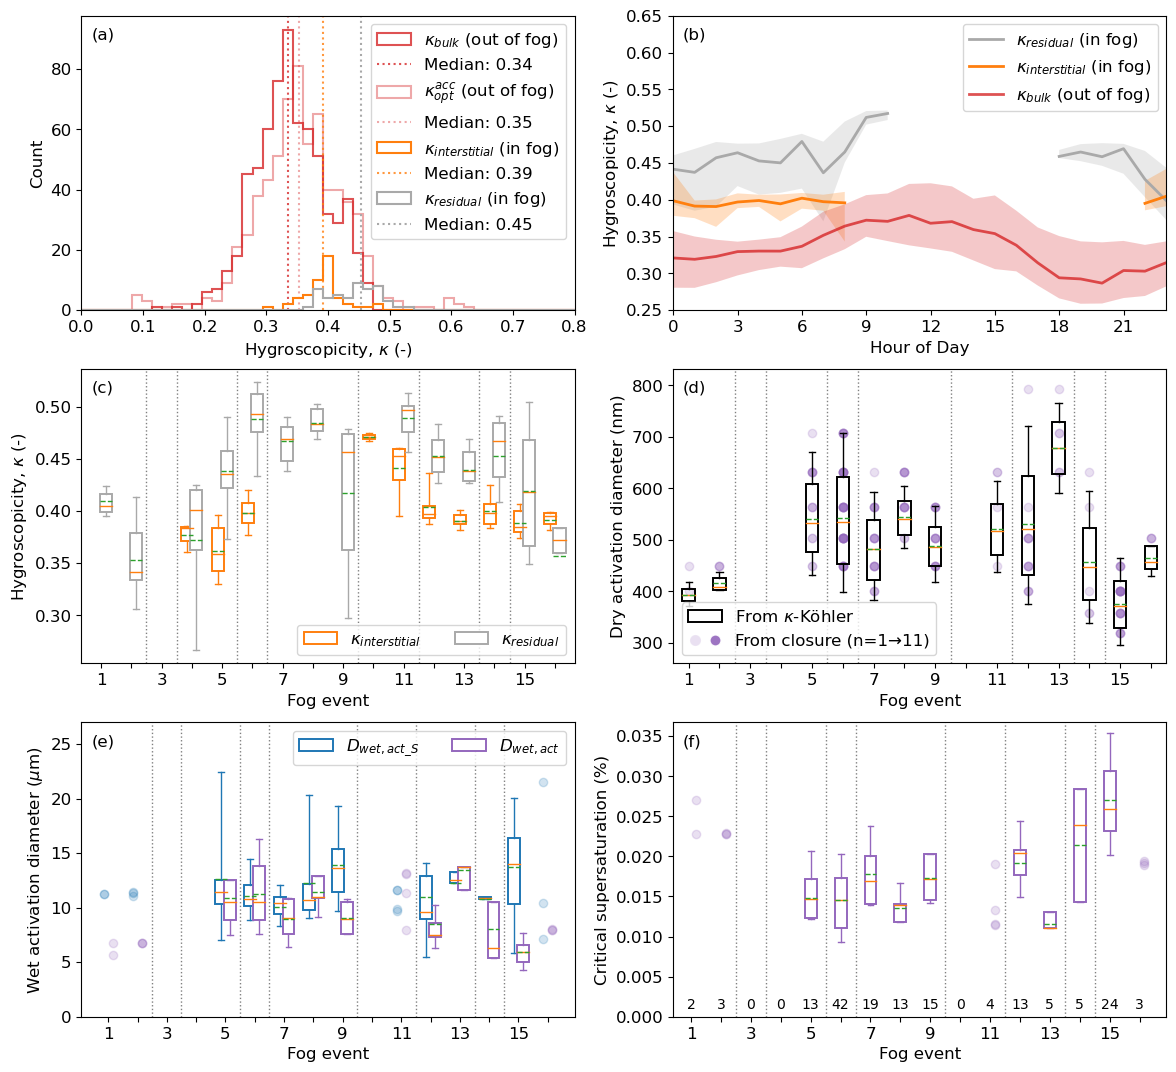

In [59]:
from matplotlib.patches import Patch
import matplotlib.patches as mpatches
import matplotlib as mpl

fig, axs = plt.subplots(3, 2, figsize=(14, 13))
ax1, ax2, ax3, ax4, ax5, ax6 = axs.flat

bulk = Functions_Neuberger26.keepData(kappa,nofog_times['starttime_nofog'],nofog_times['endtime_nofog']).loc[:,'kappa'].resample('80min').mean()
accum = Functions_Neuberger26.keepData(kappa_opt,nofog_times['starttime_nofog'],nofog_times['endtime_nofog']).loc[:,'k2'].resample('80min').mean()
nanmask =~np.isnan(bulk)&~np.isnan(accum)
# bulk
ax1.hist(bulk[nanmask], bins=np.linspace(0,0.8,50),
         histtype='step',linestyle='-',linewidth=1.5,color='C3', alpha=0.8,label="$\kappa_{bulk}$ (out of fog)")
ax1.axvline(x=bulk[nanmask].median(),
            ls=':',label=r'Median: %.2f' % bulk[nanmask].median(), c='C3', alpha=0.8)
# optimized / accumulation mode
ax1.hist(accum[nanmask], bins=np.linspace(0,0.8,50),
         histtype='step',linestyle='-',linewidth=1.5,color='C3', alpha=0.4, label="$\kappa_{opt}^{acc}$ (out of fog)")
ax1.axvline(x=accum[nanmask].median(),
            ls=':',label=r'Median: %.2f' % accum[nanmask].median(), c='C3', alpha=0.4)
# interstitial
ax1.hist(kappa_interstitial_harmonized_fog['kappa'].resample('80min').mean(), bins=np.linspace(0,0.8,50),
         histtype='step',linestyle='-',linewidth=1.5,color='C1', label="$\kappa_{interstitial}$ (in fog)")
ax1.axvline(x=kappa_interstitial_harmonized_fog['kappa'].median(),
            ls=':',label=r'Median: %.2f' % kappa_interstitial_harmonized_fog['kappa'].median(), c='C1', alpha=0.8)
# residual
ax1.hist(kappa_residual_harmonized_fog['kappa'].resample('80min').mean(), bins=np.linspace(0,0.8,50),
         histtype='step',linestyle='-',linewidth=1.5,color='darkgrey', label="$\kappa_{residual}$ (in fog)")
ax1.axvline(x=kappa_residual_harmonized_fog['kappa'].median(),
            ls=':',label=r'Median: %.2f' % kappa_residual_fog['kappa'].median(),c='darkgrey')
ax1.tick_params(axis='both',which='major', labelsize=12)
ax1.set_xlabel("$\kappa$", fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.legend(fontsize=12)
ax1.set_xlim(0,0.8)
ax1.set_xlabel('Hygroscopicity, $\kappa$ (-)', fontsize =12)
ax1.annotate('(a)',xy = (0.02,0.92), xycoords = 'axes fraction', fontsize=12)

# diurnal cycle of kappa, out of fog, interstitial, and residual

bulk_kappa_no_fog = Functions_Neuberger26.keepData(kappa, nofog_times['starttime_nofog'], nofog_times['endtime_nofog']).loc[:, ['kappa']]

kappa_interstitial_fog['hour'] = kappa_interstitial_fog.index.hour
kappa_residual_fog['hour'] = kappa_residual_fog.index.hour
bulk_kappa_no_fog['hour'] = bulk_kappa_no_fog.index.hour
kappa_interstitial_fog['type'] = 'Interstitial Fog'
kappa_residual_fog['type'] = 'Residual Fog'
bulk_kappa_no_fog['type'] = 'No Fog Bulk'

df_combined = pd.concat([
    kappa_interstitial_fog[['kappa','hour','type']],
    kappa_residual_fog[['kappa','hour','type']],
    bulk_kappa_no_fog[['kappa','hour','type']]
])


# --- Compute Diurnal Statistics with Filtering ---
# Count number of samples per (hour, type)
# --- Compute sample counts per (hour, type) ---
group_counts = df_combined.groupby(['hour', 'type'])['kappa'].transform('count')

# --- Apply filtering threshold ---
threshold = 20  # minimum samples per hour-type
df_filtered = df_combined[group_counts >= threshold]

# Compute median and percentiles
grouped_filtered = df_filtered.groupby(['hour', 'type'])
diurnal_median = grouped_filtered['kappa'].median().unstack()
diurnal_q25  = grouped_filtered['kappa'].quantile(0.25).unstack()
diurnal_q75  = grouped_filtered['kappa'].quantile(0.75).unstack()

hours = np.arange(24)

# --- Plot ---
ax2.plot(hours, diurnal_median['Residual Fog'], color='darkgrey', lw=2, label=r'$\kappa_{residual}$ (in fog)')
ax2.fill_between(hours, diurnal_q25['Residual Fog'], diurnal_q75['Residual Fog'], color='darkgrey', alpha=0.25, edgecolor='none')

ax2.plot(hours, diurnal_median['Interstitial Fog'], color='C1', lw=2, label=r'$\kappa_{interstitial}$ (in fog)')
ax2.fill_between(hours, diurnal_q25['Interstitial Fog'], diurnal_q75['Interstitial Fog'], color='C1', alpha=0.25, edgecolor='none')

ax2.plot(hours, diurnal_median['No Fog Bulk'], color='C3',alpha=0.8, lw=2, label=r'$\kappa_{bulk}$ (out of fog)')
ax2.fill_between(hours, diurnal_q25['No Fog Bulk'], diurnal_q75['No Fog Bulk'], color='C3', alpha=0.25, edgecolor='none')

# --- Formatting ---
ax2.set_xlim(0, 23)
ax2.set_xticks(np.arange(0, 24, 3))
ax2.set_xlabel('Hour of Day',fontsize =12)
ax2.set_ylabel('Hygroscopicity, $\kappa$ (-)',fontsize =12)
ax2.set_ylim(0.25, 0.65)
ax2.tick_params(axis='both',which='major', labelsize=12)
ax2.legend(fontsize=12, loc='upper right', ncol=1)
ax2.annotate('(b)', xy = (0.02,0.92), xycoords = 'axes fraction', fontsize =12)


# ax3
ax3.clear() 
for i in range(len(kappa_interstitial_events[:16])):
    # --- BOX: Interstitial Fog (orange)
    bp_int=ax3.boxplot(kappa_interstitial_events[i], 
                positions = [i-0.15],showfliers=False,widths=0.4,whis=[5,95],meanline=True,showmeans=True,
                patch_artist=True, boxprops=dict(color='C1',facecolor='white', linewidth=1.4),whiskerprops=dict(color='C1'),capprops=dict(color='C1'))
    # --- BOX: Residual Fog (darkgrey)
    bp_res=ax3.boxplot(kappa_residual_events[i], 
                positions = [i+0.15],showfliers=False,widths=0.4,whis=[5,95],meanline=True,showmeans=True,
                patch_artist=True, boxprops=dict(color='darkgrey',facecolor='white', linewidth=1.4),whiskerprops=dict(color='darkgrey'),capprops=dict(color='darkgrey'))

# --- Axes formatting ---
ax3.set_xlabel("Fog event", fontsize=12)
ax3.set_ylabel('Hygroscopicity, $\kappa$ (-)',fontsize =12)
ax3.set_xticks(np.linspace(0,15,16).astype(int))
ax3.set_xticklabels(np.linspace(1,16,16).astype(int));
for label in ax3.xaxis.get_ticklabels()[1::2]:
    label.set_visible(False)
for l in [2.5,3.5,5.5,6.5,9.5,11.5,13.5,14.5]:
    ax3.axvline(x = l-1,c = 'grey',lw = 1,ls = ':')
ax3.tick_params(axis='both',which='major', labelsize=12)
ax3.legend([bp_int["boxes"][0],bp_res["boxes"][0]],['$\kappa_{interstitial}$','$\kappa_{residual}$'],ncols=2,loc='lower right',
           labelspacing=0.4,fontsize=12)
ax3.annotate('(c)',xy = (0.02,0.92), xycoords = 'axes fraction', fontsize =12)

Dlact_medians = []
#ax4
for i in fog_times.index[:16]:
    vals_dlact = event.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i], 'D_lact'].dropna().values * 1e9
    ax4.scatter([i]*len(event.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'D_lact'].dropna().values),
                event.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'D_lact'].dropna().values*10**9,
                alpha=0.2,c='C4')
    if len(vals_dlact) > 0:
        Dlact_medians.append(np.median(vals_dlact))
    ax4.boxplot(dact_flat_arrays[i], 
                positions = [i],showfliers=False,widths=0.4,whis=[5,95],meanline=True,showmeans=True,
                patch_artist=True, boxprops=dict(color='black',facecolor='none', linewidth=1.4),whiskerprops=dict(color='black'),capprops=dict(color='black'))
ax4.scatter(0,0,color='C4',alpha=0.2,label='n=  1')
ax4.scatter(0,0,color='C4',alpha=1-(1-0.2)**11,label='n=11')
ax4.set_xlabel('Fog event', fontsize =12)
ax4.set_ylabel('Dry activation diameter (nm)', fontsize =12)
ax4.set_ylim(260,)
ax4.set_xticks(np.linspace(0,15,16).astype(int))
ax4.set_xticklabels(np.linspace(1,16,16).astype(int));
ax4.tick_params(axis='both',which='major', labelsize=12)
for label in ax4.xaxis.get_ticklabels()[1::2]:
    label.set_visible(False)
for l in [2.5,3.5,5.5,6.5,9.5,11.5,13.5,14.5]:
    ax4.axvline(x=l-1,c='grey',lw=1,ls=':')
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.legend_handler import HandlerTuple
scatter1 = Line2D([0], [0], marker='o', color='w',markerfacecolor='C4', alpha=0.2, markersize=8)
scatter2 = Line2D([0], [0], marker='o', color='w',markerfacecolor='C4', alpha=1-(1-0.2)**11, markersize=8)
box_proxy = Patch(facecolor='none', edgecolor='black', linewidth=1.4)
ax4.legend(handles=[box_proxy,(scatter1, scatter2)],labels=['From $\kappa$-Köhler','From closure (n=1→11)'],
           handler_map={tuple: HandlerTuple(ndivide=None)},fontsize=12,loc='lower left')
ax4.annotate('(d)',xy = (0.02,0.92), xycoords = 'axes fraction', fontsize =12)
# Compute median Dact for each fog event
dact_medians = [np.nanmedian(arr) for arr in dact_flat_arrays]
# Compute overall min–max of those medians
dact_min = np.nanmin(dact_medians)
dact_max = np.nanmax(dact_medians)
print(f"Overall D_act median range across all fog events: {dact_min:.3f} – {dact_max:.3f} μm")
# Overall range of the medians of dact from DMPS and GFAS closure
Dlact_min = np.nanmin(Dlact_medians)
Dlact_max = np.nanmax(Dlact_medians)
print(f"Overall D_lact (DMPS–GFAS closure) median range across fog events: {Dlact_min:.1f} – {Dlact_max:.1f} nm")

#ax5
for i in fog_times.index[:16]:
    if len(GFAS_processed_corrected_fog_fitted.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'D_Sact'].dropna().values)<5:
        ax5.scatter([i-0.15]*len(GFAS_processed_corrected_fog_fitted.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'D_Sact'].dropna().values),
                    GFAS_processed_corrected_fog_fitted.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'D_Sact'].dropna().values*10**6,
                    alpha=0.2,c='C0')
    else:
        bp_Sact=ax5.boxplot(GFAS_processed_corrected_fog_fitted.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'D_Sact'].dropna().values*10**6, 
                    positions = [i-0.15],showfliers=False,widths=0.4,whis=[5,95],meanline=True,showmeans=True,
                    patch_artist=True, boxprops=dict(color='C0',facecolor='white',linewidth=1.4),whiskerprops=dict(color='C0'),capprops=dict(color='C0'))
    if len(event.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'D_crit'].dropna().values)<5:
        ax5.scatter([i+0.15]*len(event.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'D_crit'].dropna().values),
                    event.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'D_crit'].dropna().values,
                    alpha=0.2,c='C4')
    else:
        bp_calc=ax5.boxplot(event.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'D_crit'].dropna().values, 
                    positions = [i+0.15],showfliers=False,widths=0.4,whis=[5,95],meanline=True,showmeans=True,
                    patch_artist=True, boxprops=dict(color='C4',facecolor='white', linewidth=1.4),whiskerprops=dict(color='C4'),capprops=dict(color='C4'))

for l in [2.5,3.5,5.5,6.5,9.5,11.5,13.5,14.5]:
    ax5.axvline(x=l-1,c='grey',lw=1,ls=':')
ax5.set_ylim(0,27)
ax5.set_xticks(np.linspace(0,15,16).astype(int))
ax5.set_xticklabels(np.linspace(1,16,16).astype(int));
for label in ax5.xaxis.get_ticklabels()[1::2]:
    label.set_visible(False)
ax5.legend([bp_Sact["boxes"][0],bp_calc["boxes"][0]],['$D_{wet,act\_S}$','$D_{wet,act}$'],ncols=2,loc='upper right',
           labelspacing=0.4,fontsize=12)
ax5.set_xlabel('Fog event',fontsize =12)
ax5.set_ylabel('Wet activation diameter ($\mu$m)', fontsize =12)
ax5.tick_params(axis='both',which='major', labelsize=12)
ax5.annotate('(e)',xy = (0.02,0.92), xycoords = 'axes fraction', fontsize =12)

#ax6
for i in fog_times.index[:16]:
    if len(event.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'SS_crit'].dropna().values)<5:
        ax6.scatter([i+0.15]*len(event.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'SS_crit'].dropna().values),
                    event.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'SS_crit'].dropna().values,
                    alpha=0.2,c='C4')
    else:
        ax6.boxplot(event.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'SS_crit'].dropna().values, 
                    positions = [i],showfliers=False,widths=0.4,whis=[5,95],meanline=True,showmeans=True,
                    patch_artist=True, boxprops=dict(color='C4',facecolor='white', linewidth=1.4),whiskerprops=dict(color='C4'),capprops=dict(color='C4'))
    ax6.annotate('%i'%len(event.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'SS_crit'].dropna().values),
                 xy=(i,0.001),ha='center')
for l in [2.5,3.5,5.5,6.5,9.5,11.5,13.5,14.5]:
    ax6.axvline(x = l-1,c = 'grey',lw = 1,ls = ':')
ax6.set_ylim(0,)
ax6.set_xticks(np.linspace(0,15,16).astype(int))
ax6.set_xticklabels(np.linspace(1,16,16).astype(int));
for label in ax6.xaxis.get_ticklabels()[1::2]:
    label.set_visible(False)
ax6.set_xlabel('Fog event', fontsize =12)
ax6.set_ylabel('Critical supersaturation (%)', fontsize =12)
ax6.tick_params(axis='both',which='major', labelsize=12)
ax6.annotate('(f)',xy = (0.02,0.92), xycoords = 'axes fraction', fontsize =12)
#plt.savefig('Fig_4.png',bbox_inches='tight',dpi=300)


Text(0.65, 0.95, 'At RH=100%')

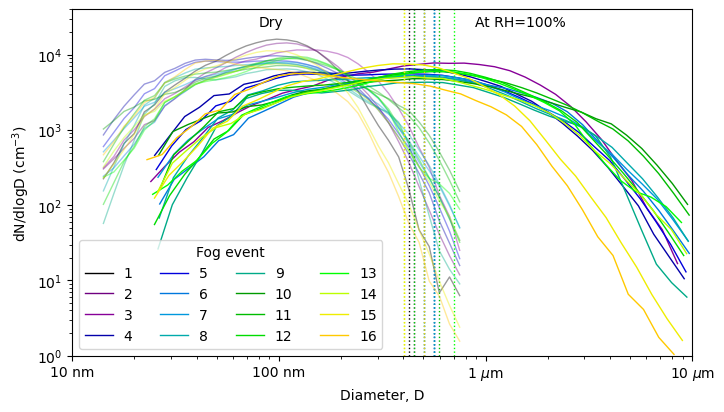

In [60]:
N = 21
test_cmaps = ['nipy_spectral']
segmented_cmaps = [mpl.colors.ListedColormap(plt.get_cmap(t)(np.linspace(0,1,N))) for t in test_cmaps]

Dpmin_R100_opt=0.02*10**(-6)

fig,ax1=plt.subplots(figsize=(8,4.5))
for i in fog_times.index[:16]:
    Dp_R100_opt=(D100_opt.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i]].mean(axis=0)+shift(D100_opt.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i]].mean(axis=0),1,cval=Dpmin_R100_opt))/2
    dlogDp_R100_opt=np.log10(D100_opt.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i]].mean(axis=0))-shift(np.log10(D100_opt.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i]].mean(axis=0)),1,cval=np.nan)
    dlogDp_R100_opt[0]=np.log10(D100_opt.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i]].mean(axis=0).values[0])-np.log10(Dpmin_R100_opt)

    ax1.plot(Dp_R,
             DMPS_R.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],:].iloc[:,2:].mean(axis=0),
             c=segmented_cmaps[0](i),lw=1,alpha=0.4)
    ax1.plot(D100_opt.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],:].mean(axis=0),
             (dlogDp_R*DMPS_R.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],:].iloc[:,2:].mean(axis=0)).values/dlogDp_R100_opt,
             c=segmented_cmaps[0](i),label='%i'%(i+1),lw=1)
    ax1.axvline(x=event.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'D_lact'].median(),
                c=segmented_cmaps[0](i),lw=1,ls=':')
ax1.set_xlabel('Diameter, D')
ax1.set_ylabel('dN/dlogD (cm$^{-3}$)')
ax1.set_xlim(10**(-8),10**(-5))
ax1.set_ylim(10**0,4*10**4)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xticks(ticks=[10**(-8),10**(-7),10**(-6),10**(-5)],labels=['10 nm','100 nm','1 $\mu$m','10 $\mu$m']);
ax1.legend(title='Fog event', ncol=4)
ax1.annotate('Dry',xy=(0.3,0.95), xycoords='axes fraction')
ax1.annotate('At RH=100%',xy=(0.65,0.95), xycoords='axes fraction')
#plt.savefig('Fig_S7.jpg',bbox_inches='tight',dpi=300)


In [61]:
## growth for smallest D
Dpmin_R100_opt=0.02*10**(-6)
a=[]
for i in fog_times.index:
    a.append((((D100_opt.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i]].mean(axis=0)+shift(D100_opt.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i]].mean(axis=0),1,cval=Dpmin_R100_opt))/2)/((D100_opt.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i]].mean(axis=0)+shift(D100_opt.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i]].mean(axis=0),1,cval=Dpmin_R100_opt))/2).index)[0])
print(pd.DataFrame(a).dropna().describe()) 

## growth for largest D
Dpmin_R100_opt=0.02*10**(-6)
a=[]
for i in fog_times.index:
    a.append((((D100_opt.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i]].mean(axis=0)+shift(D100_opt.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i]].mean(axis=0),1,cval=Dpmin_R100_opt))/2)/((D100_opt.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i]].mean(axis=0)+shift(D100_opt.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i]].mean(axis=0),1,cval=Dpmin_R100_opt))/2).index)[-1])
print(pd.DataFrame(a).dropna().describe()) 
    

               0
count  18.000000
mean    1.602868
std     0.032737
min     1.519347
25%     1.590005
50%     1.600671
75%     1.625334
max     1.642999
               0
count  18.000000
mean   11.307795
std     0.499848
min    10.038178
25%    11.093669
50%    11.356990
75%    11.708911
max    11.896064


In [62]:
### range of Ddry,act
for i in fog_times.index[:16]:
    print(event.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'D_lact'].median()*10**9)

425.29999999999995
449.4
nan
nan
563.7
563.7
503.3
563.7
503.3
nan
597.55
449.4
707.1
401.20000000000005
401.20000000000005
503.3


In [63]:
### range of Dwet,act
for i in fog_times.index[:16]:
    print(event.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'D_crit'].median())

6.215176715176715
6.747648747648747
nan
nan
10.49321849321849
10.55801405801406
9.02900702900703
10.95049995049995
8.992673992673993
nan
12.207306207306205
7.482625482625482
13.71002871002871
6.345807345807345
5.928719928719929
7.995940995940995


In [64]:
### range of SS_crit
for i in fog_times.index[:16]:
    print(event.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'SS_crit'].median())

0.02490866828176452
0.02281013797242881
nan
nan
0.01462543283479167
0.01455830192506058
0.01688710054630338
0.01394414137625422
0.01712338787045464
nan
0.012418680561510076
0.0204115673013705
0.01107303812926119
0.02390782608376885
0.0259036548487579
0.01919454672010268


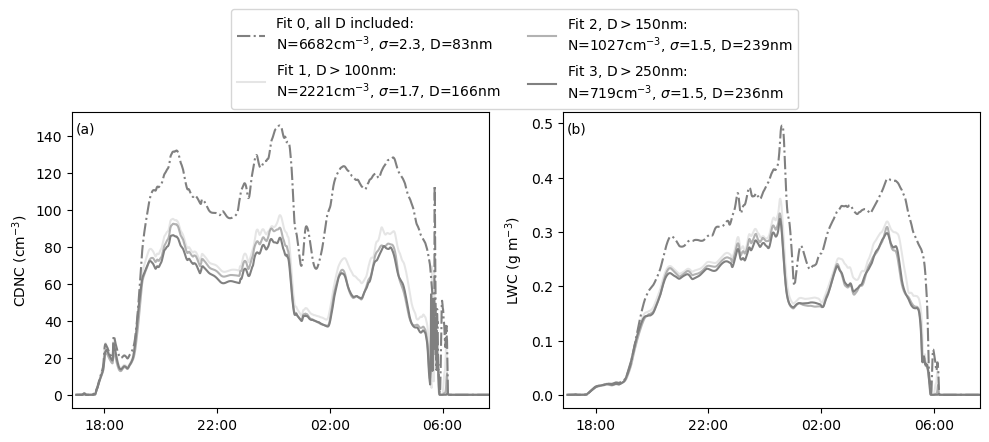

In [65]:
fig,ax=plt.subplots(figsize=(10,3.5))
ax3=plt.subplot(121)
ax3.plot(tail6_rmin['Nc']*10**(-6),ls='-.',c='gray')
ax3.plot(tail6_r100['Nc']*10**(-6),alpha=0.2,c='gray')
ax3.plot(tail6_r150['Nc']*10**(-6),alpha=0.6,c='gray')
ax3.plot(tail6_r250['Nc']*10**(-6),alpha=1.0,c='gray')
ax3.set_ylabel('CDNC (cm$^{-3}$)')
ax3.xaxis.set_major_locator(mdates.HourLocator(interval=4))
myFmt = mdates.DateFormatter('%H:%M')
ax3.xaxis.set_major_formatter(myFmt)
ax3.set_xlim(fog_times['starttime_fog'][6]-pd.Timedelta('1H'),fog_times['endtime_fog'][8]+pd.Timedelta('1H'))
ax3.annotate('(a)',xy=(0.01,0.93), xycoords='axes fraction')

ax4=plt.subplot(122)
ax4.plot(tail6_rmin['Qc']*10**3,ls='-.',c='gray',label='Fit 0, all D included:\nN=%.0fcm$^{-3}$, $\sigma$=%.1f, D=%.0fnm'%(popt1[0],popt1[1],popt1[2]))
ax4.plot(tail6_r100['Qc']*10**3,alpha=0.2,c='gray',label='Fit 1, D$>$100nm:\nN=%.0fcm$^{-3}$, $\sigma$=%.1f, D=%.0fnm'%(f1[2,0],f1[2,1],f1[2,2]*2))
ax4.plot(tail6_r150['Qc']*10**3,alpha=0.6,c='gray',label='Fit 2, D$>$150nm:\nN=%.0fcm$^{-3}$, $\sigma$=%.1f, D=%.0fnm'%(f1[3,0],f1[3,1],f1[3,2]*2))
ax4.plot(tail6_r250['Qc']*10**3,alpha=1.0,c='gray',label='Fit 3, D$>$250nm:\nN=%.0fcm$^{-3}$, $\sigma$=%.1f, D=%.0fnm'%(f1[4,0],f1[4,1],f1[4,2]*2))
ax4.set_ylabel('LWC (g m$^{-3}$)')
ax4.xaxis.set_major_locator(mdates.HourLocator(interval=4))
myFmt = mdates.DateFormatter('%H:%M')
ax4.xaxis.set_major_formatter(myFmt)
ax4.set_xlim(fog_times['starttime_fog'][6]-pd.Timedelta('1H'),fog_times['endtime_fog'][8]+pd.Timedelta('1H'))
ax4.annotate('(b)',xy=(0.01,0.93), xycoords='axes fraction')
fig.tight_layout()
fig.legend(bbox_to_anchor=(0.81,1.27),ncols=2)
#plt.savefig('Fig_5.png',bbox_inches='tight',dpi=300)

In [66]:
print(tail6_rmin.loc[fog_times_Vis['starttime_fog'][6]:fog_times_Vis['endtime_fog'][8],'Nc'].median()*10**(-6))
print(tail6_r100.loc[fog_times_Vis['starttime_fog'][6]:fog_times_Vis['endtime_fog'][8],'Nc'].median()*10**(-6))
print(tail6_r150.loc[fog_times_Vis['starttime_fog'][6]:fog_times_Vis['endtime_fog'][8],'Nc'].median()*10**(-6))
print(tail6_r250.loc[fog_times_Vis['starttime_fog'][6]:fog_times_Vis['endtime_fog'][8],'Nc'].median()*10**(-6))

print('\n')
print(tail6_rmin.loc[fog_times_Vis['starttime_fog'][6]:fog_times_Vis['endtime_fog'][8],'Nc'].median()/tail6_r100.loc[fog_times_Vis['starttime_fog'][6]:fog_times_Vis['endtime_fog'][8],'Nc'].median())

print('\n')
print(10**3*tail6_rmin.loc[fog_times_Vis['starttime_fog'][6]:fog_times_Vis['endtime_fog'][8],'Qc'].median())
print(10**3*tail6_r100.loc[fog_times_Vis['starttime_fog'][6]:fog_times_Vis['endtime_fog'][8],'Qc'].median())
print(10**3*tail6_r150.loc[fog_times_Vis['starttime_fog'][6]:fog_times_Vis['endtime_fog'][8],'Qc'].median())
print(10**3*tail6_r250.loc[fog_times_Vis['starttime_fog'][6]:fog_times_Vis['endtime_fog'][8],'Qc'].median())

print('\n')
print(tail6_rmin.loc[fog_times_Vis['starttime_fog'][6]:fog_times_Vis['endtime_fog'][8],'Qc'].median()/tail6_r100.loc[fog_times_Vis['starttime_fog'][6]:fog_times_Vis['endtime_fog'][8],'Qc'].median())

104.99790399999999
67.648504
62.846639999999994
60.723851999999994


1.5521097702323174


0.28545764507725835
0.22259424440562725
0.1991059398278594
0.20118513202760369


1.2824125162781697


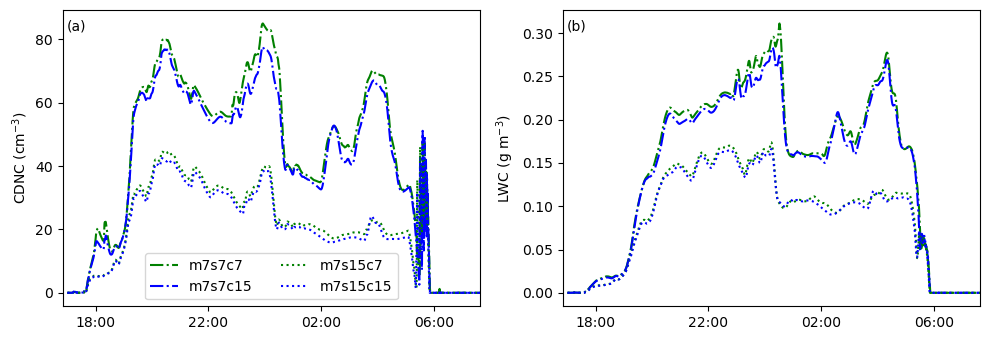

In [67]:
fig,ax=plt.subplots(figsize=(10,3.5))
ax1=plt.subplot(121)
ax1.plot(m6a6c6['Nc']*10**(-6),ls='-.',c='green',label='m7s7c7')
ax1.plot(m6a6c14['Nc']*10**(-6),ls='-.',c='blue',label='m7s7c15')
ax1.plot(m6a14c6['Nc']*10**(-6),ls=':',c='green',label='m7s15c7')
ax1.plot(m6a14c14['Nc']*10**(-6),ls=':',c='blue',label='m7s15c15')
ax1.set_ylabel('CDNC (cm$^{-3}$)')
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=4))
myFmt = mdates.DateFormatter('%H:%M')
ax1.xaxis.set_major_formatter(myFmt)
ax1.set_xlim(fog_times['starttime_fog'][6]-pd.Timedelta('1H'),fog_times['endtime_fog'][8]+pd.Timedelta('1H'))
ax1.legend(loc='lower center',ncols=2)
ax1.annotate('(a)',xy=(0.01,0.93), xycoords='axes fraction')

ax2=plt.subplot(122)
ax2.plot(m6a6c6['Qc']*10**3,ls='-.',c='green',label='m7s7c7')
ax2.plot(m6a6c14['Qc']*10**3,ls='-.',c='blue',label='m7s7c15')
ax2.plot(m6a14c6['Qc']*10**3,ls=':',c='green',label='m7s15c7')
ax2.plot(m6a14c14['Qc']*10**3,ls=':',c='blue',label='m7s15c15')
ax2.set_ylabel('LWC (g m$^{-3}$)')
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=4))
myFmt = mdates.DateFormatter('%H:%M')
ax2.xaxis.set_major_formatter(myFmt)
ax2.set_xlim(fog_times['starttime_fog'][6]-pd.Timedelta('1H'),fog_times['endtime_fog'][8]+pd.Timedelta('1H'))
ax2.annotate('(b)',xy=(0.01,0.93), xycoords='axes fraction')
fig.tight_layout()
#plt.savefig('Fig_S11.png',bbox_inches='tight',dpi=300)

In [68]:
print(m6a6c6.loc[fog_times_Vis['starttime_fog'][6]:fog_times_Vis['endtime_fog'][8],'Nc'].median()*10**(-6))
print(m6a6c6.loc[fog_times_Vis['starttime_fog'][6]:fog_times_Vis['endtime_fog'][8],'Nc'].quantile(0.25)*10**(-6))
print(m6a6c6.loc[fog_times_Vis['starttime_fog'][6]:fog_times_Vis['endtime_fog'][8],'Nc'].quantile(0.75)*10**(-6))
print('\n')
print(m6a6c14.loc[fog_times_Vis['starttime_fog'][6]:fog_times_Vis['endtime_fog'][8],'Nc'].median()*10**(-6))
print(m6a6c14.loc[fog_times_Vis['starttime_fog'][6]:fog_times_Vis['endtime_fog'][8],'Nc'].quantile(0.25)*10**(-6))
print(m6a6c14.loc[fog_times_Vis['starttime_fog'][6]:fog_times_Vis['endtime_fog'][8],'Nc'].quantile(0.75)*10**(-6))
print('\n')
print(m6a14c6.loc[fog_times_Vis['starttime_fog'][6]:fog_times_Vis['endtime_fog'][8],'Nc'].median()*10**(-6))
print(m6a14c6.loc[fog_times_Vis['starttime_fog'][6]:fog_times_Vis['endtime_fog'][8],'Nc'].quantile(0.25)*10**(-6))
print(m6a14c6.loc[fog_times_Vis['starttime_fog'][6]:fog_times_Vis['endtime_fog'][8],'Nc'].quantile(0.75)*10**(-6))
print('\n')
print(m6a14c14.loc[fog_times_Vis['starttime_fog'][6]:fog_times_Vis['endtime_fog'][8],'Nc'].median()*10**(-6))
print(m6a14c14.loc[fog_times_Vis['starttime_fog'][6]:fog_times_Vis['endtime_fog'][8],'Nc'].quantile(0.25)*10**(-6))
print(m6a14c14.loc[fog_times_Vis['starttime_fog'][6]:fog_times_Vis['endtime_fog'][8],'Nc'].quantile(0.75)*10**(-6))

print('\n')
print(m6a6c6.loc[fog_times_Vis['starttime_fog'][6]:fog_times_Vis['endtime_fog'][8],'Nc'].median()/m6a14c6.loc[fog_times_Vis['starttime_fog'][6]:fog_times_Vis['endtime_fog'][8],'Nc'].median())
print(m6a6c14.loc[fog_times_Vis['starttime_fog'][6]:fog_times_Vis['endtime_fog'][8],'Nc'].median()/m6a14c14.loc[fog_times_Vis['starttime_fog'][6]:fog_times_Vis['endtime_fog'][8],'Nc'].median())

print('\n')
print(m6a6c6.loc[fog_times_Vis['starttime_fog'][6]:fog_times_Vis['endtime_fog'][8],'Nc'].median()/m6a6c14.loc[fog_times_Vis['starttime_fog'][6]:fog_times_Vis['endtime_fog'][8],'Nc'].median())
print(m6a14c6.loc[fog_times_Vis['starttime_fog'][6]:fog_times_Vis['endtime_fog'][8],'Nc'].median()/m6a14c14.loc[fog_times_Vis['starttime_fog'][6]:fog_times_Vis['endtime_fog'][8],'Nc'].median())


52.146028
33.077905
65.804346


50.675563999999994
32.530165
62.769755999999994


21.616794
18.153510999999998
33.198657


20.542742
16.4892645
31.593289


2.4122924056175954
2.4668354399816734


1.029017220212882
1.0522837701023553


In [69]:
print(Functions_Neuberger26.keepData(kappa,fog_times['starttime_fog'][6:8],fog_times['endtime_fog'][6:8])['kappa'].median())
print(Functions_Neuberger26.keepData(kappa,fog_times['starttime_fog'][14:15],fog_times['endtime_fog'][14:15])['kappa'].median())


0.4752079447592713
0.41839057842632343


In [70]:
## D_{wet,act_S}
(Functions_Neuberger26.keepData(GFAS_processed_corrected_fog_fitted_1m,fog_times['starttime_fog'],fog_times['endtime_fog']).loc[:,'D_Sact']*10**6).describe()


count    1785.000000
mean       11.452426
std         4.726928
min         5.013810
25%         9.094881
50%        10.129161
75%        12.105091
max        39.103761
Name: D_Sact, dtype: float64

In [71]:
ED_2=Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean(),fog_times_Vis['starttime_fog'][:16],fog_times_Vis['endtime_fog'][:16]).loc[:,'ED_2'].median()
ED_DSact=Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean(),fog_times_Vis['starttime_fog'][:16],fog_times_Vis['endtime_fog'][:16]).loc[:,'ED_D_Sact'].median()

print(ED_2,ED_DSact,(ED_DSact-ED_2)/ED_2)


11.57937356904071 21.041094696302487 0.8171185661164942


In [72]:
CDNC_2=Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean(),fog_times_Vis['starttime_fog'][:16],fog_times_Vis['endtime_fog'][:16]).loc[:,'Nconc_2'].median()
CDNC_DSact=Functions_Neuberger26.keepData(GFAS_processed_corrected_fog_fitted_1m.resample('60S').mean(),fog_times_Vis['starttime_fog'][:16],fog_times_Vis['endtime_fog'][:16]).loc[:,'Nconc_DSact'].replace(0,np.nan).median()

print(CDNC_2,CDNC_DSact,(CDNC_DSact-CDNC_2)/CDNC_2)


97.36430074972512 12.437738430271246 -0.8722556590608866


Text(0.02, 0.94, '(d)')

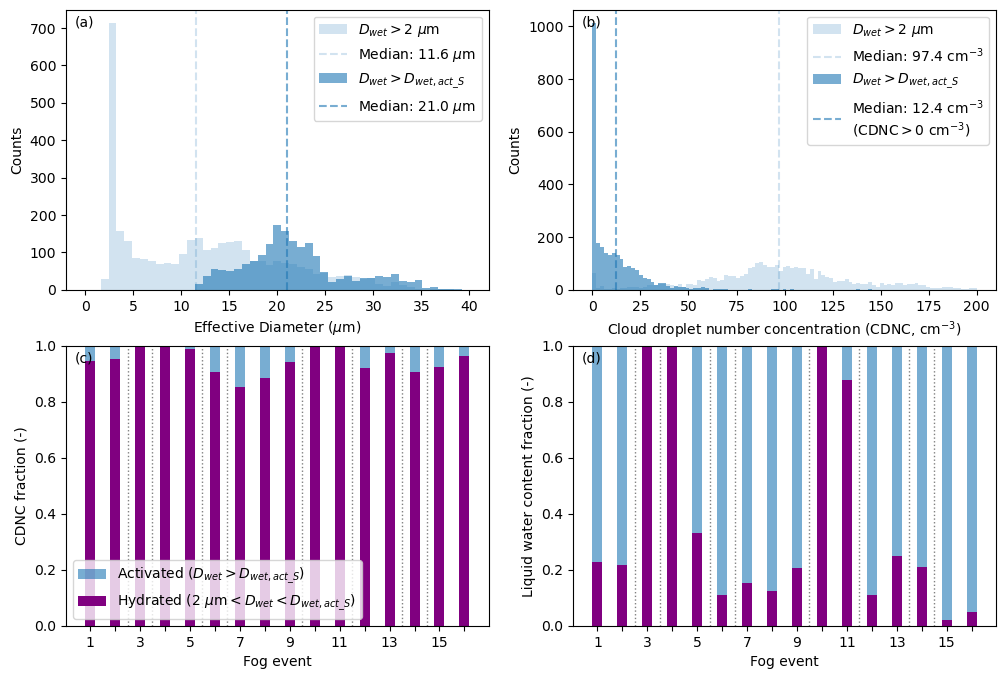

In [73]:
fig,ax=plt.subplots(figsize=(12,8))
ax1=plt.subplot(221)
ax1.hist(Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean(),fog_times_Vis['starttime_fog'][:16],fog_times_Vis['endtime_fog'][:16]).loc[:,'ED_2'],
         bins=np.linspace(0,40,50),alpha=0.2,color='C0',label='$D_{wet}>2$ $\mu$m');
ax1.axvline(x=Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean(),fog_times_Vis['starttime_fog'][:16],fog_times_Vis['endtime_fog'][:16]).loc[:,'ED_2'].median(),
            label='Median: %.1f $\mu$m'%Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean(),fog_times_Vis['starttime_fog'][:16],fog_times_Vis['endtime_fog'][:16]).loc[:,'ED_2'].median(),
            c='C0',alpha=0.2,ls='--')
ax1.hist(Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean(),fog_times_Vis['starttime_fog'][:16],fog_times_Vis['endtime_fog'][:16]).loc[:,'ED_D_Sact'],
         bins=np.linspace(0,40,50),alpha=0.6,color='C0',label='$D_{wet}>D_{wet,act\_S}$');
ax1.axvline(x=Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean(),fog_times_Vis['starttime_fog'][:16],fog_times_Vis['endtime_fog'][:16]).loc[:,'ED_D_Sact'].median(),
            label='Median: %.1f $\mu$m'%Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean(),fog_times_Vis['starttime_fog'][:16],fog_times_Vis['endtime_fog'][:16]).loc[:,'ED_D_Sact'].median(),
            c='C0',alpha=0.6,ls='--')
ax1.legend()
ax1.set_xlabel('Effective Diameter ($\mu$m)')
ax1.set_ylabel('Counts')
ax1.annotate('(a)',xy=(0.02,0.94), xycoords='axes fraction')

ax2=plt.subplot(222)
ax2.hist(Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean(),fog_times_Vis['starttime_fog'][:16],fog_times_Vis['endtime_fog'][:16]).loc[:,'Nconc_2'],
         bins=np.linspace(0,200,100),alpha=0.2,color='C0',label='$D_{wet}>2$ $\mu$m');
ax2.axvline(x=Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean(),fog_times_Vis['starttime_fog'][:16],fog_times_Vis['endtime_fog'][:16]).loc[:,'Nconc_2'].median(),
            label='Median: %.1f cm$^{-3}$'%Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean(),fog_times_Vis['starttime_fog'][:16],fog_times_Vis['endtime_fog'][:16]).loc[:,'Nconc_2'].median(),
            c='C0',alpha=0.2,ls='--')
ax2.hist(Functions_Neuberger26.keepData(GFAS_processed_corrected_fog_fitted_1m.resample('60S').mean(),fog_times_Vis['starttime_fog'][:16],fog_times_Vis['endtime_fog'][:16]).loc[:,'Nconc_DSact'],
         bins=np.linspace(0,200,100),alpha=0.6,color='C0',label='$D_{wet}>D_{wet,act\_S}$');
ax2.axvline(x=Functions_Neuberger26.keepData(GFAS_processed_corrected_fog_fitted_1m.resample('60S').mean(),fog_times_Vis['starttime_fog'][:16],fog_times_Vis['endtime_fog'][:16]).loc[:,'Nconc_DSact'].replace(0,np.nan).median(),
            label='Median: %.1f cm$^{-3}$\n(CDNC$>0$ cm$^{-3}$)'%Functions_Neuberger26.keepData(GFAS_processed_corrected_fog_fitted_1m.resample('60S').mean(),fog_times_Vis['starttime_fog'][:16],fog_times_Vis['endtime_fog'][:16]).loc[:,'Nconc_DSact'].replace(0,np.nan).median(),
            c='C0',alpha=0.6,ls='--')
ax2.legend()
ax2.set_xlabel('Cloud droplet number concentration (CDNC, cm$^{-3}$)')
ax2.set_ylabel('Counts')
ax2.annotate('(b)',xy=(0.02,0.94), xycoords='axes fraction')

ax3=plt.subplot(223)
for i in fog_times.index[:16]:
    ax3.bar(i,1,color='C0',alpha=0.6,width=0.4,label='Activated ($D_{wet}>D_{wet,act\_S}$)')
    ax3.bar(i,((GFAS_processed_corrected.loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'Nconc_2']-GFAS_processed_corrected_fog_fitted_1m.loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'Nconc_DSact'])/GFAS_processed_corrected.loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'Nconc_2']).median(),
           color='purple',width=0.4,label='Hydrated (2 $\mu$m$<D_{wet}<D_{wet,act\_S}$)')
for l in [2.5,3.5,5.5,6.5,9.5,11.5,13.5,14.5]:
    ax3.axvline(x=l-1,c='grey',lw=1,ls=':')
ax3.set_xticks(np.linspace(0,15,16).astype(int))
ax3.set_xticklabels(np.linspace(1,16,16).astype(int));
for label in ax3.xaxis.get_ticklabels()[1::2]:
    label.set_visible(False)
ax3.set_ylim(0,1)
ax3.set_xlabel('Fog event')
ax3.set_ylabel('CDNC fraction (-)')
handles, labels = ax3.get_legend_handles_labels()
ax3.legend(handles[:2],labels[:2],loc='lower left')
ax3.annotate('(c)',xy=(0.02,0.94), xycoords='axes fraction')

ax4=plt.subplot(224)
for i in fog_times.index[:16]:
    ax4.bar(i,1,color='C0',alpha=0.6,width=0.4)
    ax4.bar(i,((GFAS_processed_corrected.loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'LWC_2']-GFAS_processed_corrected_fog_fitted_1m.loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'LWC_DSact'])/GFAS_processed_corrected.loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'LWC_2']).median(),
           color='purple',width=0.4)
for l in [2.5,3.5,5.5,6.5,9.5,11.5,13.5,14.5]:
    ax4.axvline(x=l-1,c='grey',lw=1,ls=':')
ax4.set_xticks(np.linspace(0,15,16).astype(int))
ax4.set_xticklabels(np.linspace(1,16,16).astype(int));
for label in ax4.xaxis.get_ticklabels()[1::2]:
    label.set_visible(False)
ax4.set_ylim(0,1)
ax4.set_xlabel('Fog event')
ax4.set_ylabel('Liquid water content fraction (-)')
ax4.annotate('(d)',xy=(0.02,0.94), xycoords='axes fraction')

#plt.savefig('Fig_6.png',bbox_inches='tight',dpi=300)


In [74]:
## contribution of hydrated to CDNC_2
a=[]
for i in fog_times.index[:16]:
    a.append(100*((GFAS_processed_corrected.loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'Nconc_2']-GFAS_processed_corrected_fog_fitted_1m.loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'Nconc_DSact'])/GFAS_processed_corrected.loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'Nconc_2']).median())
print(pd.DataFrame(a).dropna().describe()) 

                0
count   16.000000
mean    94.759403
std      4.590688
min     85.203475
25%     91.787511
50%     94.950671
75%     99.183009
max    100.000000


In [75]:
## contribution of hydrated to LWC_2
a=[]
for i in fog_times.index[:16]:
    a.append(100*((GFAS_processed_corrected.loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'LWC_2']-GFAS_processed_corrected_fog_fitted_1m.loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'LWC_DSact'])/GFAS_processed_corrected.loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'LWC_2']).median())
print(pd.DataFrame(a).dropna().describe()) 

                0
count   16.000000
mean    36.748283
std     36.775493
min      2.082625
25%     12.094451
50%     21.340421
75%     46.705339
max    100.000000


In [ ]:
# Fig. 7 made by Rahul Ranjan

In [76]:
# event-based LWC_hydr (GFAS)
for i in fog_times.index[:16]:
    print(i+1,(GFAS_processed_corrected.loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'LWC_2']-GFAS_processed_corrected_fog_fitted_1m.loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'LWC_DSact']).quantile(0.25))
    
for i in fog_times.index[:16]:
    print(i+1,(GFAS_processed_corrected.loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'LWC_2']-GFAS_processed_corrected_fog_fitted_1m.loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'LWC_DSact']).quantile(0.75))


1 0.004501255385095143
2 0.0030286482040324386
3 0.00010432058327195942
4 1.540859992310362e-05
5 0.002419789028391515
6 0.0033567715686408685
7 0.00407301766952513
8 0.0042499523544121814
9 0.003626683951500738
10 0.0003525482322189215
11 0.001124276731476456
12 0.0026871612980369636
13 0.0027629216645686443
14 0.004602296451414224
15 0.0018582529065879552
16 0.00035631336989814166
1 0.006059910469710497
2 0.006218464570358517
3 0.00020918260277447582
4 0.002435026784271518
5 0.006239499829823924
6 0.006156544659972748
7 0.007345435466795284
8 0.0063372749706918675
9 0.006173853092780478
10 0.0005826566745993394
11 0.010928730118009199
12 0.0214331893582205
13 0.005489572769738818
14 0.014447585029874838
15 0.004304146170805198
16 0.0016553286705372748


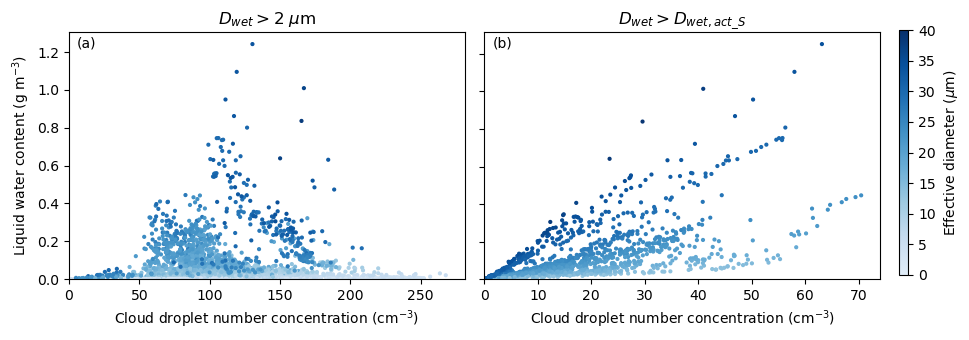

In [77]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# Create a colormap and normalization object
cmap = plt.get_cmap('Blues')
norm = mcolors.Normalize(vmin=-5, vmax=40)  # Set the range of values for the colormap

# Create a ScalarMappable to convert values into color
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required for colorbar

fig,ax=plt.subplots(figsize=(9,3.5))
ax1=plt.subplot(121)
ax2=plt.subplot(122)
for i in fog_times.index[:16]:
    varx=GFAS_processed_corrected.resample('60S').mean().loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'Nconc_2']
    vary=GFAS_processed_corrected.resample('60S').mean().loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'LWC_2']
    varc=GFAS_processed_corrected.resample('60S').mean().loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'ED_2']
    varx_act=GFAS_processed_corrected.resample('60S').mean().loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'Nconc_D_Sact']
    vary_act=GFAS_processed_corrected.resample('60S').mean().loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'LWC_activated']
    varc_act=GFAS_processed_corrected.resample('60S').mean().loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'ED_D_Sact']
    nanmask=~np.isnan(varx)&~np.isnan(vary)&~np.isnan(varc)
    nanmask_act=~np.isnan(varx_act)&~np.isnan(vary_act)&~np.isnan(varc_act)
    ax1.scatter(varx[nanmask],
                vary[nanmask],
                c=sm.to_rgba(varc[nanmask]),
                s=4)
    ax2.scatter(varx_act[nanmask_act],
                vary_act[nanmask_act],
                c=sm.to_rgba(varc_act[nanmask_act]),
                s=4)   
ax1.set_xlim(0,)
ax1.set_ylim(0,)
ax2.set_xlim(0,)
ax2.set_ylim(0,)
ax1.set_title('$D_{wet}>2$ $\mu$m')
ax2.set_title('$D_{wet}>D_{wet,act\_S}$')
ax1.set_xlabel('Cloud droplet number concentration (cm$^{-3}$)')    
ax1.set_ylabel('Liquid water content (g m$^{-3}$)')
ax1.annotate('(a)',xy=(0.02,0.94), xycoords='axes fraction')
ax2.set_xlabel('Cloud droplet number concentration (cm$^{-3}$)')    
ax2.set_yticklabels([])
ax2.annotate('(b)',xy=(0.02,0.94), xycoords='axes fraction')
cax = fig.add_axes([1.005, 0.2, 0.01, 0.7])
cbar=fig.colorbar(sm,cax=cax,orientation='vertical',label='Effective diameter ($\mu$m)')
cbar.ax.set_ylim(0,40)
fig.tight_layout()
#plt.savefig('Fig_8.jpg',bbox_inches='tight',dpi=300)


Text(0.01, 0.92, '(c)')

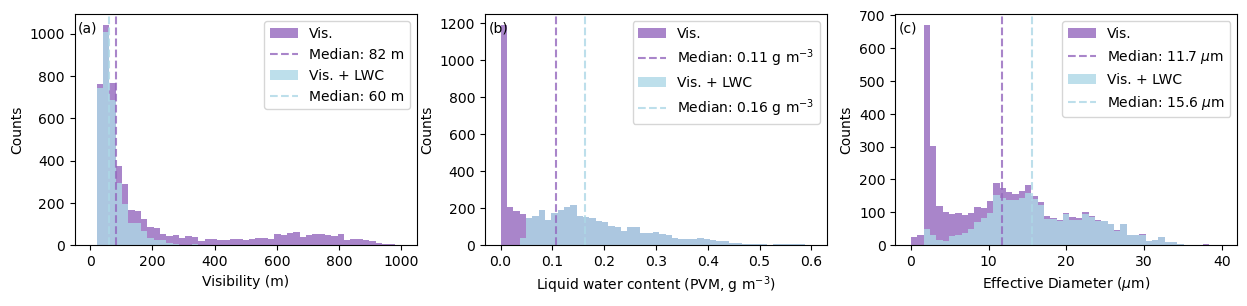

In [78]:
LWC_thresh=0.01
LWC_thresh_dense=0.08/1.72

fig,ax=plt.subplots(figsize=(15,3))
ax1 = plt.subplot(131)
ax1.hist(Functions_Neuberger26.keepData(GCVI.resample('60S').mean(),fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'],
         bins=np.linspace(0,1000,50),color='C4',label='Vis.',alpha=0.8);
ax1.axvline(x=Functions_Neuberger26.keepData(GCVI.resample('60S').mean(),fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].median(),
            label='Median: %.0f m'%Functions_Neuberger26.keepData(GCVI.resample('60S').mean(),fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].median(),
            c='C4',ls='--',alpha=0.8)
ax1.hist(Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc['2022-02-08':'2022-04-03','LWC (g m^-3)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'],
         bins=np.linspace(0,1000,50),color='lightblue',label='Vis. + LWC',alpha=0.8);
ax1.axvline(x=Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc['2022-02-08':'2022-04-03','LWC (g m^-3)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].median(),
            label='Median: %.0f m'%Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[PVM.loc['2022-02-08':'2022-04-03',:][PVM.loc['2022-02-08':'2022-04-03','LWC (g m^-3)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].median(),
            c='lightblue',ls='--',alpha=0.8)
ax1.legend()
ax1.set_xlabel('Visibility (m)')
ax1.set_ylabel('Counts')
ax1.annotate('(a)',xy=(0.01,0.92), xycoords='axes fraction')

ax3 = plt.subplot(132)
ax3.hist(Functions_Neuberger26.keepData(PVM,fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'],
         bins=np.linspace(0,0.6,50),color='C4',label='Vis.',alpha=0.8);
ax3.axvline(x=Functions_Neuberger26.keepData(PVM,fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].median(),
            label='Median: %.2f g m$^{-3}$'%Functions_Neuberger26.keepData(PVM,fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].median(),
            c='C4',ls='--',alpha=0.8)
ax3.hist(Functions_Neuberger26.keepData(PVM.loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'],
         bins=np.linspace(0,0.6,50),color='lightblue',label='Vis. + LWC',alpha=0.8);
ax3.axvline(x=Functions_Neuberger26.keepData(PVM.loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].median(),
            label='Median: %.2f g m$^{-3}$'%Functions_Neuberger26.keepData(PVM.loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].median(),
            c='lightblue',ls='--',alpha=0.8)
ax3.legend()
ax3.set_xlabel('Liquid water content (PVM, g m$^{-3}$)')
ax3.set_ylabel('Counts')
ax3.annotate('(b)',xy=(0.01,0.92), xycoords='axes fraction')

ax2 = plt.subplot(133)
ax2.hist(Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean(),fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'],
         bins=np.linspace(0,40,50),color='C4',label='Vis.',alpha=0.8);
ax2.axvline(x=Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean(),fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].median(),
            label='Median: %.1f $\mu$m'%Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean(),fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].median(),
            c='C4',ls='--',alpha=0.8)
ax2.hist(Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'],
         bins=np.linspace(0,40,50),color='lightblue',label='Vis. + LWC',alpha=0.8);
ax2.axvline(x=Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].median(),
            label='Median: %.1f $\mu$m'%Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].median(),
            c='lightblue',ls='--',alpha=0.8)
ax2.legend()
ax2.set_xlabel('Effective Diameter ($\mu$m)')
ax2.set_ylabel('Counts')
ax2.annotate('(c)',xy=(0.01,0.92), xycoords='axes fraction')

#plt.savefig('Fig_9.png',bbox_inches='tight',dpi=300)


In [79]:
# Visibility reduction
Vis=Functions_Neuberger26.keepData(GCVI.resample('60S').mean(),fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].median()
Vis_LWC=Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc['2022-02-08':'2022-04-03','LWC (g m^-3)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].median()

print((Vis_LWC-Vis)/Vis) # exact value
print((60-82)/82) # with rounded numbers

-0.2752536391707102
-0.2682926829268293


In [80]:
# LWC increase
LWC_Vis=Functions_Neuberger26.keepData(PVM,fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].median()
LWC_LWC=Functions_Neuberger26.keepData(PVM.loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].median()

print((LWC_LWC-LWC_Vis)/LWC_Vis) # exact value
print((0.16-0.11)/0.11) # with rounded numbers

0.5213348825477186
0.4545454545454546


In [81]:
# ED increase
ED_Vis=Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean(),fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].median()
ED_LWC=Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].median()

print((ED_LWC-ED_Vis)/ED_Vis) # exact value
print((15.6-11.7)/11.7) # with rounded numbers

0.33001975106198533
0.33333333333333337


In [82]:
# decrease of in fog time
import warnings
warnings.filterwarnings("ignore")

Vis_times=len(Functions_Neuberger26.keepData(GCVI.resample('60S').mean(),fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'])
Vis_LWC_times=len(Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc['2022-02-08':'2022-04-03','LWC (g m^-3)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'])

print(100/Vis_times*Vis_LWC_times-100)


-35.57710960232784


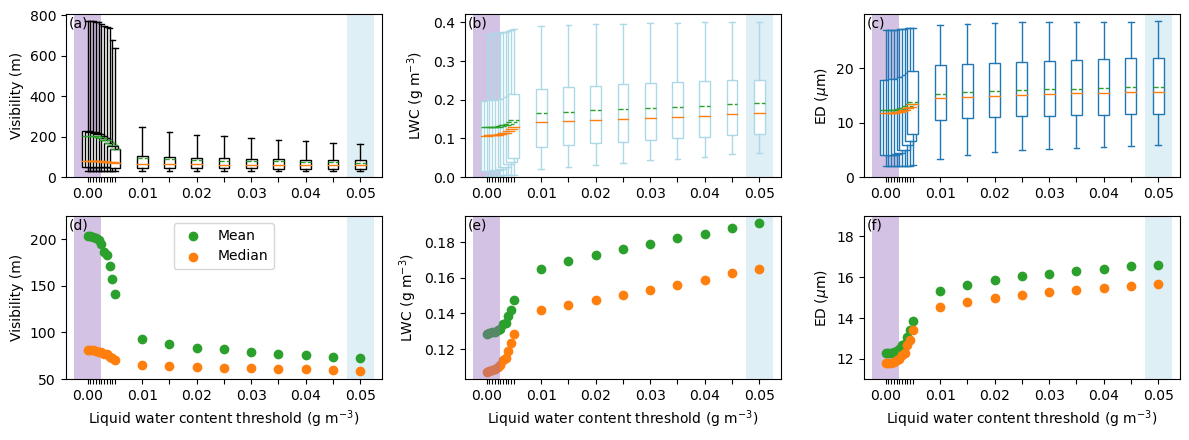

In [83]:
import matplotlib.ticker as ticker
LWC_thresholds_s=np.linspace(0,0.01,11)/2
LWC_thresholds=np.linspace(0.02,0.1,9)/2

fig,ax=plt.subplots(figsize=(12,4.5))
fig.tight_layout()
ax1 = plt.subplot(231)
for i in range(len(LWC_thresholds_s)):
    ax1.boxplot(Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc['2022-02-08':'2022-04-03','LWC (g m^-3)']>LWC_thresholds_s[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].values, 
                    positions = [LWC_thresholds_s[i]],showfliers=False,widths=0.002,whis=[5,95],meanline=True,showmeans=True,
                   patch_artist=True, boxprops=dict(color='black',facecolor='white'),whiskerprops=dict(color='black'),capprops=dict(color='black'))
for i in range(len(LWC_thresholds)):
    ax1.boxplot(Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc['2022-02-08':'2022-04-03','LWC (g m^-3)']>LWC_thresholds[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].values, 
                    positions = [LWC_thresholds[i]],showfliers=False,widths=0.002,whis=[5,95],meanline=True,showmeans=True,
                   patch_artist=True, boxprops=dict(color='black',facecolor='white'),whiskerprops=dict(color='black'),capprops=dict(color='black'))
ax1.axvspan(-0.0025,0.0025,alpha=0.4,color='C4',lw=0)
ax1.axvspan(0.0475,0.0525,alpha=0.4,color='lightblue',lw=0)
ax1.set_ylabel('Visibility (m)')    
ax1.set_xlim(-0.004,0.054)
ax1.set_ylim(0,)
for label in ax1.xaxis.get_ticklabels()[1:10]:
    label.set_visible(False)
for label in ax1.xaxis.get_ticklabels()[1::2]:
    label.set_visible(False)
ax1.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax1.annotate('(a)',xy=(0.01,0.92), xycoords='axes fraction')

ax2 = plt.subplot(232)
for i in range(len(LWC_thresholds_s)):
    ax2.boxplot(Functions_Neuberger26.keepData(PVM.loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresholds_s[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].values, 
                    positions = [LWC_thresholds_s[i]],showfliers=False,widths=0.002,whis=[5,95],meanline=True,showmeans=True,
                   patch_artist=True, boxprops=dict(color='lightblue',facecolor='white'),whiskerprops=dict(color='lightblue'),capprops=dict(color='lightblue'))
for i in range(len(LWC_thresholds)):
    ax2.boxplot(Functions_Neuberger26.keepData(PVM.loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresholds[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].values, 
                    positions = [LWC_thresholds[i]],showfliers=False,widths=0.002,whis=[5,95],meanline=True,showmeans=True,
                   patch_artist=True, boxprops=dict(color='lightblue',facecolor='white'),whiskerprops=dict(color='lightblue'),capprops=dict(color='lightblue'))
ax2.axvspan(-0.0025,0.0025,alpha=0.4,color='C4',lw=0)
ax2.axvspan(0.0475,0.0525,alpha=0.4,color='lightblue',lw=0)
ax2.set_ylabel('LWC (g m$^{-3}$)')
ax2.set_xlim(-0.004,0.054)
ax2.set_ylim(0,)
for label in ax2.xaxis.get_ticklabels()[1:10]:
    label.set_visible(False)
for label in ax2.xaxis.get_ticklabels()[1::2]:
    label.set_visible(False)
ax2.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax2.annotate('(b)',xy=(0.01,0.92), xycoords='axes fraction')

ax3 = plt.subplot(233)
for i in range(len(LWC_thresholds_s)):
    ax3.boxplot(Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresholds_s[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].dropna().values, 
                    positions = [LWC_thresholds_s[i]],showfliers=False,widths=0.002,whis=[5,95],meanline=True,showmeans=True,
                   patch_artist=True, boxprops=dict(color='C0',facecolor='white'),whiskerprops=dict(color='C0'),capprops=dict(color='C0'))
for i in range(len(LWC_thresholds)):
    ax3.boxplot(Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresholds[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].dropna().values, 
                    positions = [LWC_thresholds[i]],showfliers=False,widths=0.002,whis=[5,95],meanline=True,showmeans=True,
                   patch_artist=True, boxprops=dict(color='C0',facecolor='white'),whiskerprops=dict(color='C0'),capprops=dict(color='C0'))
ax3.axvspan(-0.0025,0.0025,alpha=0.4, color='C4',lw=0)
ax3.axvspan(0.0475,0.0525,alpha=0.4, color='lightblue',lw=0)
ax3.set_ylabel('ED ($\mu$m)')    
ax3.set_xlim(-0.004,0.054)
ax3.set_ylim(0,)
for label in ax3.xaxis.get_ticklabels()[1:10]:
    label.set_visible(False)
for label in ax3.xaxis.get_ticklabels()[1::2]:
    label.set_visible(False)
ax3.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax3.annotate('(c)',xy=(0.01,0.92), xycoords='axes fraction')

ax4 = plt.subplot(234)
ax4.axvspan(-0.0025,0.0025,alpha=0.4,color='C4',lw=0)
ax4.axvspan(0.0475,0.0525,alpha=0.4,color='lightblue',lw=0)
for i in range(len(LWC_thresholds_s)):
    ax4.scatter(LWC_thresholds_s[i],
                Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc['2022-02-08':'2022-04-03','LWC (g m^-3)']>LWC_thresholds_s[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].mean(),
                c='C2',label='Mean')
    ax4.scatter(LWC_thresholds_s[i],
                Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc['2022-02-08':'2022-04-03','LWC (g m^-3)']>LWC_thresholds_s[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].median(),
                c='C1',label='Median')
    if i==0:
        ax4.legend()
for i in range(len(LWC_thresholds)):
    ax4.scatter(LWC_thresholds[i],
                Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc['2022-02-08':'2022-04-03','LWC (g m^-3)']>LWC_thresholds[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].mean(),
                c='C2',label='Mean')
    ax4.scatter(LWC_thresholds[i],
                Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc['2022-02-08':'2022-04-03','LWC (g m^-3)']>LWC_thresholds[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].median(),
                c='C1',label='Median')
ax4.set_xlabel('Liquid water content threshold (g m$^{-3}$)')
ax4.set_ylabel('Visibility (m)')    
ax4.set_xlim(-0.004,0.054)
ax4.set_ylim(50,225)
ax4.set_xticks(np.concatenate((LWC_thresholds_s,LWC_thresholds)))
for label in ax4.xaxis.get_ticklabels()[1:10]:
    label.set_visible(False)
for label in ax4.xaxis.get_ticklabels()[1::2]:
    label.set_visible(False)
ax4.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax4.annotate('(d)',xy=(0.01,0.92), xycoords='axes fraction')

ax5 = plt.subplot(235)
for i in range(len(LWC_thresholds_s)):
    ax5.scatter(LWC_thresholds_s[i],
                Functions_Neuberger26.keepData(PVM.loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresholds_s[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].mean(),
                c='C2',label='Mean')
    ax5.scatter(LWC_thresholds_s[i],
                Functions_Neuberger26.keepData(PVM.loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresholds_s[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].median(),
                c='C1',label='Median')
ax5.axvspan(-0.0025,0.0025,alpha=0.4,color='C4',lw=0)
ax5.axvspan(0.0475,0.0525,alpha=0.4,color='lightblue',lw=0)
for i in range(len(LWC_thresholds)):
    ax5.scatter(LWC_thresholds[i],
                Functions_Neuberger26.keepData(PVM.loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresholds[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].mean(),
                c='C2',label='Mean')
    ax5.scatter(LWC_thresholds[i],
                Functions_Neuberger26.keepData(PVM.loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresholds[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].median(),
                c='C1',label='Median')
ax5.set_xlabel('Liquid water content threshold (g m$^{-3}$)')
ax5.set_ylabel('LWC (g m$^{-3}$)')
ax5.set_xlim(-0.004,0.054)
ax5.set_xticks(np.concatenate((LWC_thresholds_s,LWC_thresholds)))
for label in ax5.xaxis.get_ticklabels()[1:10]:
    label.set_visible(False)
for label in ax5.xaxis.get_ticklabels()[1::2]:
    label.set_visible(False)
ax5.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax5.annotate('(e)',xy=(0.01,0.92), xycoords='axes fraction')

ax6 = plt.subplot(236)
ax6.axvspan(-0.0025,0.0025,alpha=0.4,color='C4',lw=0)
ax6.axvspan(0.0475,0.0525,alpha=0.4,color='lightblue',lw=0)
for i in range(len(LWC_thresholds_s)):
    ax6.scatter(LWC_thresholds_s[i],
                Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresholds_s[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].mean(),
                c='C2',label='Mean')
    ax6.scatter(LWC_thresholds_s[i],
                Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresholds_s[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].median(),
                c='C1',label='Median')
for i in range(len(LWC_thresholds)):
    ax6.scatter(LWC_thresholds[i],
                Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresholds[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].mean(),
                c='C2',label='Mean')
    ax6.scatter(LWC_thresholds[i],
                Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresholds[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].median(),
                c='C1',label='Median')
ax6.set_xlabel('Liquid water content threshold (g m$^{-3}$)')
ax6.set_ylabel('ED ($\mu$m)')    
ax6.set_xlim(-0.004,0.054)
ax6.set_ylim(11,19)
ax6.set_xticks(np.concatenate((LWC_thresholds_s,LWC_thresholds)))
for label in ax6.xaxis.get_ticklabels()[1:10]:
    label.set_visible(False)
for label in ax6.xaxis.get_ticklabels()[1::2]:
    label.set_visible(False)
ax6.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax6.annotate('(f)',xy=(0.01,0.92), xycoords='axes fraction')

fig.tight_layout()
#plt.savefig('Fig_S15.png',bbox_inches='tight',dpi=300)


Text(0.01, 0.92, '(f)')

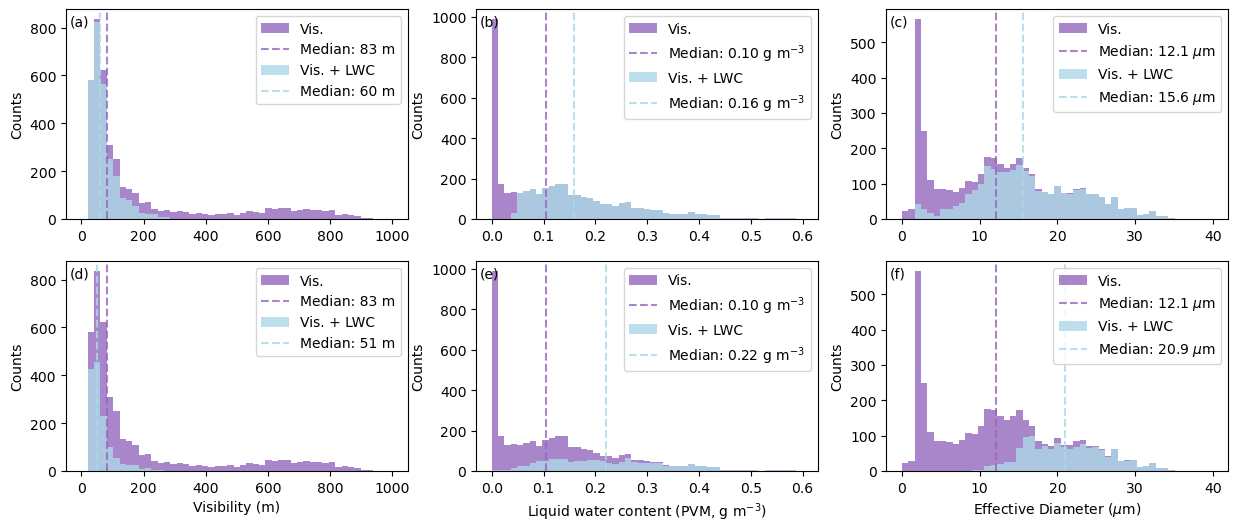

In [84]:
fig,ax=plt.subplots(figsize=(15,6))
ax1 = plt.subplot(231)
ax1.hist(Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>=0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'],
         bins=np.linspace(0,1000,50),color='C4',label='Vis.',alpha=0.8);
ax1.axvline(x=Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>=0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].median(),
            label='Median: %.0f m'%Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>=0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].median(),
            c='C4',ls='--',alpha=0.8)
ax1.hist(Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'],
         bins=np.linspace(0,1000,50),color='lightblue',label='Vis. + LWC',alpha=0.8);
ax1.axvline(x=Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].median(),
            label='Median: %.0f m'%Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].median(),
            c='lightblue',ls='--',alpha=0.8)
ax1.legend()
ax1.set_ylabel('Counts')
ax1.annotate('(a)',xy=(0.01,0.92), xycoords='axes fraction')

ax3 = plt.subplot(232)
ax3.hist(Functions_Neuberger26.keepData(PVM.loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>=0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'],
         bins=np.linspace(0,0.6,50),color='C4',label='Vis.',alpha=0.8);
ax3.axvline(x=Functions_Neuberger26.keepData(PVM.loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>=0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].median(),
            label='Median: %.2f g m$^{-3}$'%Functions_Neuberger26.keepData(PVM.loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>=0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].median(),
            c='C4',ls='--',alpha=0.8)
ax3.hist(Functions_Neuberger26.keepData(PVM.loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'],
         bins=np.linspace(0,0.6,50),color='lightblue',label='Vis. + LWC',alpha=0.8);
ax3.axvline(x=Functions_Neuberger26.keepData(PVM.loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].median(),
            label='Median: %.2f g m$^{-3}$'%Functions_Neuberger26.keepData(PVM.loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].median(),
            c='lightblue',ls='--',alpha=0.8)
ax3.legend()
ax3.set_ylabel('Counts')
ax3.annotate('(b)',xy=(0.01,0.92), xycoords='axes fraction')

ax2 = plt.subplot(233)
ax2.hist(Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>=0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'],
         bins=np.linspace(0,40,50),color='C4',label='Vis.',alpha=0.8);
ax2.axvline(x=Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>=0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].median(),
            label='Median: %.1f $\mu$m'%Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>=0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].median(),
            c='C4',ls='--',alpha=0.8)
ax2.hist(Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'],
         bins=np.linspace(0,40,50),color='lightblue',label='Vis. + LWC',alpha=0.8);
ax2.axvline(x=Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].median(),
            label='Median: %.1f $\mu$m'%Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].median(),
            c='lightblue',ls='--',alpha=0.8)
ax2.legend()
ax2.set_ylabel('Counts')
ax2.annotate('(c)',xy=(0.01,0.92), xycoords='axes fraction')


ax4 = plt.subplot(234)
ax4.hist(Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'],
         bins=np.linspace(0,1000,50),color='C4',label='Vis.',alpha=0.8);
ax4.axvline(x=Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].median(),
            label='Median: %.0f m'%Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].median(),
            c='C4',ls='--',alpha=0.8)
ax4.hist(Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'],
         bins=np.linspace(0,1000,50),color='lightblue',label='Vis. + LWC',alpha=0.8);
ax4.axvline(x=Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].median(),
            label='Median: %.0f m'%Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].median(),
            c='lightblue',ls='--',alpha=0.8)
ax4.legend()
ax4.set_xlabel('Visibility (m)')
ax4.set_ylabel('Counts')
ax4.annotate('(d)',xy=(0.01,0.92), xycoords='axes fraction')

ax6 = plt.subplot(235)
ax6.hist(Functions_Neuberger26.keepData(PVM.loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'],
         bins=np.linspace(0,0.6,50),color='C4',label='Vis.',alpha=0.8);
ax6.axvline(x=Functions_Neuberger26.keepData(PVM.loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].median(),
            label='Median: %.2f g m$^{-3}$'%Functions_Neuberger26.keepData(PVM.loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].median(),
            c='C4',ls='--',alpha=0.8)
ax6.hist(Functions_Neuberger26.keepData(PVM.loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'],
         bins=np.linspace(0,0.6,50),color='lightblue',label='Vis. + LWC',alpha=0.8);
ax6.axvline(x=Functions_Neuberger26.keepData(PVM.loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].median(),
            label='Median: %.2f g m$^{-3}$'%Functions_Neuberger26.keepData(PVM.loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].median(),
            c='lightblue',ls='--',alpha=0.8)
ax6.legend()
ax6.set_xlabel('Liquid water content (PVM, g m$^{-3}$)')
ax6.set_ylabel('Counts')
ax6.annotate('(e)',xy=(0.01,0.92), xycoords='axes fraction')

ax5 = plt.subplot(236)
ax5.hist(Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'],
         bins=np.linspace(0,40,50),color='C4',label='Vis.',alpha=0.8);
ax5.axvline(x=Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].median(),
            label='Median: %.1f $\mu$m'%Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].median(),
            c='C4',ls='--',alpha=0.8)
ax5.hist(Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'],
         bins=np.linspace(0,40,50),color='lightblue',label='Vis. + LWC',alpha=0.8);
ax5.axvline(x=Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].median(),
            label='Median: %.1f $\mu$m'%Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].median(),
            c='lightblue',ls='--',alpha=0.8)
ax5.legend()
ax5.set_xlabel('Effective Diameter ($\mu$m)')
ax5.set_ylabel('Counts')
ax5.annotate('(f)',xy=(0.01,0.92), xycoords='axes fraction')
#plt.savefig('Fig_S16.png',bbox_inches='tight',dpi=300)


In [85]:
# Visibility decrease GFAS (l528)
Vis=Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].median()
Vis_LWC=Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].median()

print((Vis_LWC-Vis)/Vis) # exact value
print((51-83)/83) # with rounded numbers


-0.3899917853231107
-0.3855421686746988


In [86]:
# LWC increases
LWC_Vis=Functions_Neuberger26.keepData(PVM.loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].median()
LWC_LWC=Functions_Neuberger26.keepData(PVM.loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].median()

print((LWC_LWC-LWC_Vis)/LWC_Vis) # exact value
print((0.22-0.10)/0.10) # with rounded numbers

1.105520200597419
1.2


In [87]:
# ED increases
ED_Vis=Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].median()
ED_LWC=Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].median()

print((ED_LWC-ED_Vis)/ED_Vis) # exact value
print((20.9-12.1)/12.1) # with rounded numbers

0.728864682816955
0.7272727272727272


(0.0, 0.35)

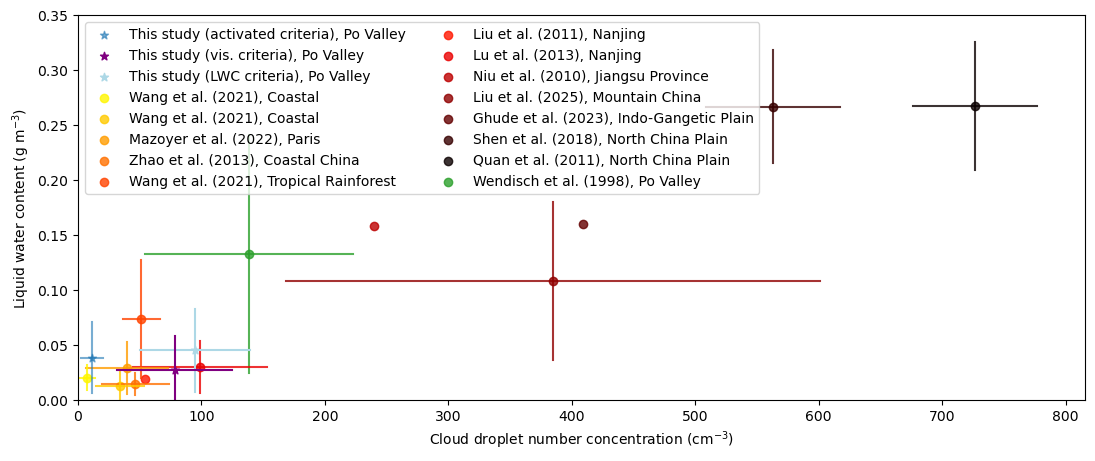

In [88]:
N = 16
test_cmaps = ['hot']
segmented_cmaps = [mpl.colors.ListedColormap(plt.get_cmap(t)(np.linspace(0,1,N))) for t in test_cmaps]

fig,ax=plt.subplots(figsize=(13,5))
plt.plot([Wendisch98['CDNC'].mean(),Wendisch98['CDNC'].mean()],
         [Wendisch98['LWC'].mean()-Wendisch98['LWC'].std(),Wendisch98['LWC'].mean()+Wendisch98['LWC'].std()],c='C2',alpha=0.8)
plt.plot([Wendisch98['CDNC'].mean()-Wendisch98['CDNC'].std(),Wendisch98['CDNC'].mean()+Wendisch98['CDNC'].std()],
         [Wendisch98['LWC'].mean(),Wendisch98['LWC'].mean()],c='C2',alpha=0.8)
plt.scatter(Wendisch98['CDNC'].mean(),Wendisch98['LWC'].mean(),label='Wendisch et al. (1998), Po Valley',c='C2',alpha=0.8)

plt.plot([Quan11['CDNC'].mean(),Quan11['CDNC'].mean()],
         [Quan11['LWC'].mean()-Quan11['LWC'].std(),Quan11['LWC'].mean()+Quan11['LWC'].std()],c=segmented_cmaps[0](0),alpha=0.8)
plt.plot([Quan11['CDNC'].mean()-Quan11['CDNC'].std(),Quan11['CDNC'].mean()+Quan11['CDNC'].std()],
         [Quan11['LWC'].mean(),Quan11['LWC'].mean()],c=segmented_cmaps[0](0),alpha=0.8)
plt.scatter(Quan11['CDNC'].mean(),Quan11['LWC'].mean(),label='Quan et al. (2011), North China Plain',c=segmented_cmaps[0](0),alpha=0.8)

plt.plot([Shen18['CDNC'].mean(),Shen18['CDNC'].mean()],
         [Shen18['LWC'].mean()-Shen18['LWC'].std(),Shen18['LWC'].mean()+Shen18['LWC'].std()],c=segmented_cmaps[0](1),alpha=0.8)
plt.plot([Shen18['CDNC'].mean()-Shen18['CDNC'].std(),Shen18['CDNC'].mean()+Shen18['CDNC'].std()],
         [Shen18['LWC'].mean(),Shen18['LWC'].mean()],c=segmented_cmaps[0](1),alpha=0.8)
plt.scatter(Shen18['CDNC'].mean(),Shen18['LWC'].mean(),label='Shen et al. (2018), North China Plain',c=segmented_cmaps[0](1),alpha=0.8)

plt.scatter(409,0.16,label='Ghude et al. (2023), Indo-Gangetic Plain',c=segmented_cmaps[0](2),alpha=0.8)

plt.plot([Liu25['CDNC'].mean(),Liu25['CDNC'].mean()],
         [Liu25['LWC'].mean()-Liu25['LWC'].std(),Liu25['LWC'].mean()+Liu25['LWC'].std()],c=segmented_cmaps[0](3),alpha=0.8)
plt.plot([Liu25['CDNC'].mean()-Liu25['CDNC'].std(),Liu25['CDNC'].mean()+Liu25['CDNC'].std()],
         [Liu25['LWC'].mean(),Liu25['LWC'].mean()],c=segmented_cmaps[0](3),alpha=0.8)
plt.scatter(Liu25['CDNC'].mean(),Liu25['LWC'].mean(),label='Liu et al. (2025), Mountain China',c=segmented_cmaps[0](3),alpha=0.8)

plt.scatter(240.1,0.158,label='Niu et al. (2010), Jiangsu Province',c=segmented_cmaps[0](4),alpha=0.8)

plt.plot([Lu13['CDNC'].mean(),Lu13['CDNC'].mean()],
         [Lu13['LWC'].mean()-Lu13['LWC'].std(),Lu13['LWC'].mean()+Lu13['LWC'].std()],c=segmented_cmaps[0](5),alpha=0.8)
plt.plot([Lu13['CDNC'].mean()-Lu13['CDNC'].std(),Lu13['CDNC'].mean()+Lu13['CDNC'].std()],
         [Lu13['LWC'].mean(),Lu13['LWC'].mean()],c=segmented_cmaps[0](5),alpha=0.8)
plt.scatter(Lu13['CDNC'].mean(),Lu13['LWC'].mean(),label='Lu et al. (2013), Nanjing',c=segmented_cmaps[0](5),alpha=0.8)

plt.scatter(54.65714285714285,0.018944214285714286,label='Liu et al. (2011), Nanjing',c=segmented_cmaps[0](6),alpha=0.8)

plt.plot([Wang21c['CDNC'].mean(),Wang21c['CDNC'].mean()],
         [Wang21c['LWC'].mean()-Wang21c['LWC'].std(),Wang21c['LWC'].mean()+Wang21c['LWC'].std()],c=segmented_cmaps[0](7),alpha=0.8)
plt.plot([Wang21c['CDNC'].mean()-Wang21c['CDNC'].std(),Wang21c['CDNC'].mean()+Wang21c['CDNC'].std()],
         [Wang21c['LWC'].mean(),Wang21c['LWC'].mean()],c=segmented_cmaps[0](7),alpha=0.8)
plt.scatter(Wang21c['CDNC'].mean(),Wang21c['LWC'].mean(),label='Wang et al. (2021), Tropical Rainforest',c=segmented_cmaps[0](7),alpha=0.8)

plt.plot([Zhao13['CDNC'].mean(),Zhao13['CDNC'].mean()],
         [Zhao13['LWC'].mean()-Zhao13['LWC'].std(),Zhao13['LWC'].mean()+Zhao13['LWC'].std()],c=segmented_cmaps[0](8),alpha=0.8)
plt.plot([Zhao13['CDNC'].mean()-Zhao13['CDNC'].std(),Zhao13['CDNC'].mean()+Zhao13['CDNC'].std()],
         [Zhao13['LWC'].mean(),Zhao13['LWC'].mean()],c=segmented_cmaps[0](8),alpha=0.8)
plt.scatter(Zhao13['CDNC'].mean(),Zhao13['LWC'].mean(),label='Zhao et al. (2013), Coastal China',c=segmented_cmaps[0](8),alpha=0.8)

plt.plot([Mazoyer22['CDNC'].mean(),Mazoyer22['CDNC'].mean()],
         [Mazoyer22['LWC'].mean()-Mazoyer22['LWC'].std(),Mazoyer22['LWC'].mean()+Mazoyer22['LWC'].std()],c=segmented_cmaps[0](9),alpha=0.8)
plt.plot([Mazoyer22['CDNC'].mean()-Mazoyer22['CDNC'].std(),Mazoyer22['CDNC'].mean()+Mazoyer22['CDNC'].std()],
         [Mazoyer22['LWC'].mean(),Mazoyer22['LWC'].mean()],c=segmented_cmaps[0](9),alpha=0.8)
plt.scatter(Mazoyer22['CDNC'].mean(),Mazoyer22['LWC'].mean(),label='Mazoyer et al. (2022), Paris',c=segmented_cmaps[0](9),alpha=0.8)

plt.plot([Wang21b2['CDNC'].mean(),Wang21b2['CDNC'].mean()],
         [Wang21b2['LWC'].mean()-Wang21b2['LWC'].std(),Wang21b2['LWC'].mean()+Wang21b2['LWC'].std()],c=segmented_cmaps[0](10),alpha=0.8)
plt.plot([Wang21b2['CDNC'].mean()-Wang21b2['CDNC'].std(),Wang21b2['CDNC'].mean()+Wang21b2['CDNC'].std()],
         [Wang21b2['LWC'].mean(),Wang21b2['LWC'].mean()],c=segmented_cmaps[0](10),alpha=0.8)
plt.scatter(Wang21b2['CDNC'].mean(),Wang21b2['LWC'].mean(),label='Wang et al. (2021), Coastal',c=segmented_cmaps[0](10),alpha=0.8)

plt.plot([Wang21b['CDNC'].mean(),Wang21b['CDNC'].mean()],
         [Wang21b['LWC'].mean()-Wang21b['LWC'].std(),Wang21b['LWC'].mean()+Wang21b['LWC'].std()],c=segmented_cmaps[0](11),alpha=0.8)
plt.plot([Wang21b['CDNC'].mean()-Wang21b['CDNC'].std(),Wang21b['CDNC'].mean()+Wang21b['CDNC'].std()],
         [Wang21b['LWC'].mean(),Wang21b['LWC'].mean()],c=segmented_cmaps[0](11),alpha=0.8)
plt.scatter(Wang21b['CDNC'].mean(),Wang21b['LWC'].mean(),label='Wang et al. (2021), Coastal',c=segmented_cmaps[0](11),alpha=0.8)

plt.plot([Neuberger25h_LWC['CDNC'].mean(),Neuberger25h_LWC['CDNC'].mean()],
         [Neuberger25h_LWC['LWC'].mean()-Neuberger25h_LWC['LWC'].std(),Neuberger25h_LWC['LWC'].mean()+Neuberger25h_LWC['LWC'].std()],
         c='lightblue')
plt.plot([Neuberger25h_LWC['CDNC'].mean()-Neuberger25h_LWC['CDNC'].std(),Neuberger25h_LWC['CDNC'].mean()+Neuberger25h_LWC['CDNC'].std()],
         [Neuberger25h_LWC['LWC'].mean(),Neuberger25h_LWC['LWC'].mean()],c='lightblue')
plt.scatter(Neuberger25h_LWC['CDNC'].mean(),Neuberger25h_LWC['LWC'].mean(),label='This study (LWC criteria), Po Valley',
            c='lightblue',marker='*')

plt.plot([Neuberger25_Vis['CDNC'].mean(),Neuberger25_Vis['CDNC'].mean()],
         [Neuberger25_Vis['LWC'].mean()-Neuberger25_Vis['LWC'].std(),Neuberger25_Vis['LWC'].mean()+Neuberger25_Vis['LWC'].std()],
         c='purple')
plt.plot([Neuberger25_Vis['CDNC'].mean()-Neuberger25_Vis['CDNC'].std(),Neuberger25_Vis['CDNC'].mean()+Neuberger25_Vis['CDNC'].std()],
         [Neuberger25_Vis['LWC'].mean(),Neuberger25_Vis['LWC'].mean()],c='purple')
plt.scatter(Neuberger25_Vis['CDNC'].mean(),Neuberger25_Vis['LWC'].mean(),label='This study (vis. criteria), Po Valley',
            c='purple',marker='*')

plt.plot([Neuberger25h_Sact['CDNC'].mean(),Neuberger25h_Sact['CDNC'].mean()],
         [Neuberger25h_Sact['LWC'].mean()-Neuberger25h_Sact['LWC'].std(),Neuberger25h_Sact['LWC'].mean()+Neuberger25h_Sact['LWC'].std()],
         c='C0',alpha=0.6)
plt.plot([Neuberger25h_Sact['CDNC'].mean()-Neuberger25h_Sact['CDNC'].std(),Neuberger25h_Sact['CDNC'].mean()+Neuberger25h_Sact['CDNC'].std()],
         [Neuberger25h_Sact['LWC'].mean(),Neuberger25h_Sact['LWC'].mean()],c='C0',alpha=0.6)
plt.scatter(Neuberger25h_Sact['CDNC'].mean(),Neuberger25h_Sact['LWC'].mean(),label='This study (activated criteria), Po Valley',
            c='C0',alpha=0.6,marker='*')

handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[::-1],labels[::-1],loc='upper left',ncols=2)
plt.xlabel('Cloud droplet number concentration (cm$^{-3}$)')
plt.ylabel('Liquid water content (g m$^{-3}$)')
plt.xlim(0,)
plt.ylim(0,0.35)
#plt.savefig('Fig_10.png',bbox_inches='tight',dpi=300)


In [89]:
CDNC_2=Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean(),fog_times_Vis['starttime_fog'][:16],fog_times_Vis['endtime_fog'][:16]).loc[:,'Nconc_2'].median()
CDNC_DSact=Functions_Neuberger26.keepData(GFAS_processed_corrected_fog_fitted_1m.resample('60S').mean(),fog_times_Vis['starttime_fog'][:16],fog_times_Vis['endtime_fog'][:16]).loc[:,'Nconc_DSact'].replace(0,np.nan).median()

print(CDNC_2,CDNC_DSact,CDNC_2-CDNC_DSact)


97.36430074972512 12.437738430271246 84.92656231945386


In [ ]:
# Fig. 11 made by Hao

(0.0, 0.8)

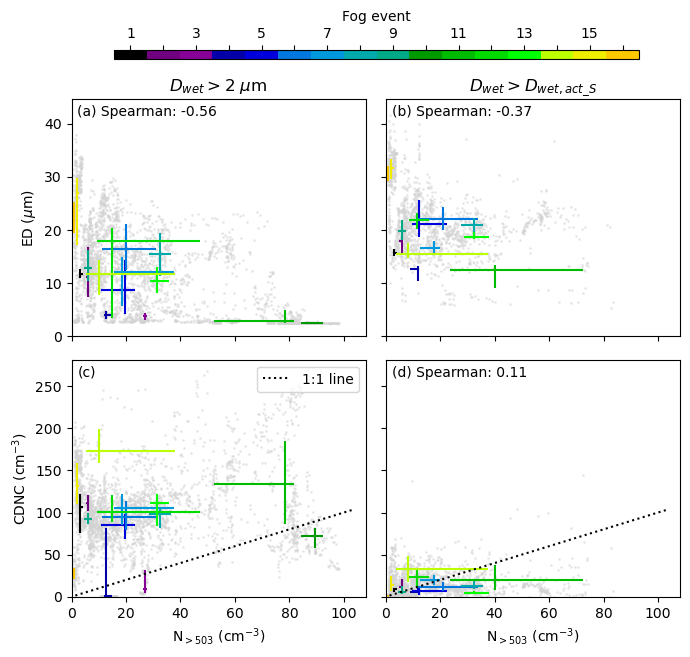

In [90]:
########### N_CDNC_all new data
import random
n_random=20

p=0.01

N = 21
test_cmaps = ['nipy_spectral']
segmented_cmaps = [mpl.colors.ListedColormap(plt.get_cmap(t)(np.linspace(0,1,N))) for t in test_cmaps]

D2=-4

fig,axs=plt.subplots(nrows=2,ncols=2,figsize=(7,6),layout='constrained')
plt.subplots_adjust(wspace=0.15, hspace=0.15)

for i in fog_times.index[:16]:
    Nconc_2=GFAS_processed_corrected.loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'Nconc_2']
    ED_2=GFAS_processed_corrected.loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'ED_2']
    Nconc_DSact=GFAS_processed_corrected_fog_fitted_1m.loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'Nconc_DSact']
    ED_DSact=GFAS_processed_corrected_fog_fitted_1m.loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'ED_DSact']
    N_D2=(dlogDp_R[D2:]*DMPS_R.loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],:].iloc[:,D2:]).sum(axis=1).resample('60S').mean().interpolate().dropna()
    nanmask_2=~np.isnan(Nconc_2)&~np.isnan(N_D2)
    nanmask_DSact=~np.isnan(Nconc_DSact)&~np.isnan(N_D2)&(Nconc_DSact>0)
    axs[1,0].scatter(N_D2[nanmask_2],Nconc_2[nanmask_2],c='lightgrey',alpha=0.4,s=1)
    axs[1,0].errorbar(N_D2[nanmask_2].median(),
                      Nconc_2[nanmask_2].median(),
                      xerr=np.vstack([N_D2[nanmask_2].median()-N_D2[nanmask_2].quantile(0.25),
                                      N_D2[nanmask_2].quantile(0.75)-N_D2[nanmask_2].median()]),
                      yerr=np.vstack([Nconc_2[nanmask_2].median()-Nconc_2[nanmask_2].quantile(0.25),
                                      Nconc_2[nanmask_2].quantile(0.75)-Nconc_2[nanmask_2].median()]),
                      c=segmented_cmaps[0](i)) 
    axs[0,0].scatter(N_D2[nanmask_2],ED_2[nanmask_2],c='lightgrey',alpha=0.4,s=1)
    axs[0,0].errorbar(N_D2[nanmask_2].median(),
                      ED_2[nanmask_2].median(),
                      xerr=np.vstack([N_D2[nanmask_2].median()-N_D2[nanmask_2].quantile(0.25),
                                      N_D2[nanmask_2].quantile(0.75)-N_D2[nanmask_2].median()]),
                      yerr=np.vstack([ED_2[nanmask_2].median()-ED_2[nanmask_2].quantile(0.25),
                                      ED_2[nanmask_2].quantile(0.75)-ED_2[nanmask_2].median()]),
                      c=segmented_cmaps[0](i)) 
    
    axs[1,1].scatter(N_D2[nanmask_DSact],Nconc_DSact[nanmask_DSact],c='lightgrey',alpha=0.4,s=1)
    axs[1,1].errorbar(N_D2[nanmask_DSact].median(),
                      Nconc_DSact[nanmask_DSact].median(),
                      xerr=np.vstack([N_D2[nanmask_DSact].median()-N_D2[nanmask_DSact].quantile(0.25),
                                      N_D2[nanmask_DSact].quantile(0.75)-N_D2[nanmask_DSact].median()]),
                      yerr=np.vstack([Nconc_DSact[nanmask_DSact].median()-Nconc_DSact[nanmask_DSact].quantile(0.25),
                                      Nconc_DSact[nanmask_DSact].quantile(0.75)-Nconc_DSact[nanmask_DSact].median()]),
                      c=segmented_cmaps[0](i))
    axs[0,1].scatter(N_D2[nanmask_DSact],ED_DSact[nanmask_DSact],c='lightgrey',alpha=0.4,s=1)
    axs[0,1].errorbar(N_D2[nanmask_DSact].median(),
                      ED_DSact[nanmask_DSact].median(),
                      xerr=np.vstack([N_D2[nanmask_DSact].median()-N_D2[nanmask_DSact].quantile(0.25),
                                      N_D2[nanmask_DSact].quantile(0.75)-N_D2[nanmask_DSact].median()]),
                      yerr=np.vstack([ED_DSact[nanmask_DSact].median()-ED_DSact[nanmask_DSact].quantile(0.25),
                                      ED_DSact[nanmask_DSact].quantile(0.75)-ED_DSact[nanmask_DSact].median()]),
                      c=segmented_cmaps[0](i))
    if i==0:
        Nconc_2_long=Nconc_2
        ED_2_long=ED_2
        Nconc_DSact_long=Nconc_DSact
        ED_DSact_long=ED_DSact
        N_D2_long=N_D2
        try:
            random_idx_2=random.sample(range(len(N_D2[nanmask_2])-1),n_random)
            random_idx_DSact=random.sample(range(len(N_D2[nanmask_DSact])-1),n_random)
            Nconc_2_random=Nconc_2[nanmask_2][random_idx_2].sort_index()
            ED_2_random=ED_2[nanmask_2][random_idx_2].sort_index()
            Nconc_DSact_random=Nconc_DSact[nanmask_DSact][random_idx_DSact].sort_index()
            ED_DSact_random=ED_DSact[nanmask_DSact][random_idx_DSact].sort_index()
            N_D2_random=N_D2[nanmask_2][random_idx_2].sort_index()
        except:
            continue
    else:
        Nconc_2_long=pd.concat([Nconc_2_long,Nconc_2],axis=0)
        ED_2_long=pd.concat([ED_2_long,ED_2],axis=0)
        Nconc_DSact_long=pd.concat([Nconc_DSact_long,Nconc_DSact],axis=0)
        ED_DSact_long=pd.concat([ED_DSact_long,ED_DSact],axis=0)
        N_D2_long=pd.concat([N_D2_long,N_D2],axis=0)
        try:
            random_idx_2=random.sample(range(len(N_D2[nanmask_2])-1),n_random)
            random_idx_DSact=random.sample(range(len(N_D2[nanmask_DSact])-1),n_random)
            Nconc_2_random=pd.concat([Nconc_2_random,Nconc_2[nanmask_2][random_idx_2].sort_index()],axis=0)
            ED_2_random=pd.concat([ED_2_random,ED_2[nanmask_2][random_idx_2].sort_index()],axis=0)
            Nconc_DSact_random=pd.concat([Nconc_DSact_random,Nconc_DSact[nanmask_DSact][random_idx_DSact].sort_index()],axis=0)
            ED_DSact_random=pd.concat([ED_DSact_random,ED_DSact[nanmask_DSact][random_idx_DSact].sort_index()],axis=0)
            N_D2_random=pd.concat([N_D2_random,N_D2[nanmask_2][random_idx_2].sort_index()],axis=0)
        except:
            continue
    nanmask_2=~np.isnan(Nconc_2)
    nanmask_DSact=~np.isnan(Nconc_DSact)&(Nconc_DSact>0)

axs[0,0].set_title('$D_{wet}>2$ $\mu$m')
axs[0,1].set_title('$D_{wet}>D_{wet,act\_S}$')

nanmask_2_long=~np.isnan(Nconc_2_long)&~np.isnan(N_D2_long)
nanmask_DSact_long=~np.isnan(Nconc_DSact_long)&~np.isnan(N_D2_long)&(Nconc_DSact_long>0)

axs[1,0].set_xlabel('N$_{>%.0f}$ (cm$^{-3}$)'%(float(DMPS_R.loc[fog_times_Vis['starttime_fog'][14]:fog_times_Vis['endtime_fog'][14],:].columns[D2-1])*10**9))
axs[1,1].set_xlabel('N$_{>%.0f}$ (cm$^{-3}$)'%(float(DMPS_R.loc[fog_times_Vis['starttime_fog'][14]:fog_times_Vis['endtime_fog'][14],:].columns[D2-1])*10**9))

axs[1,0].set_ylabel('CDNC (cm$^{-3}$)')
axs[0,0].set_ylabel('ED ($\mu$m)')

xmin,xmax=axs[0,0].get_xlim()
axs[1,0].plot([xmin,xmax],[xmin,xmax],c='black',ls=':',label='1:1 line')
axs[1,1].plot([xmin,xmax],[xmin,xmax],c='black',ls=':')

axs[1,0].legend(loc='upper right')

axs[0,0].set_xlim(0,xmax+5)
axs[0,1].set_xlim(0,xmax+5)
axs[1,0].set_xlim(0,xmax+5)
axs[1,1].set_xlim(0,xmax+5)
ymin,ymax=axs[0,1].get_ylim()
axs[0,0].set_ylim(0,ymax)
axs[0,1].set_ylim(0,ymax)
ymin,ymax=axs[1,0].get_ylim()
axs[1,0].set_ylim(0,ymax)
axs[1,1].set_ylim(0,ymax)

axs[0,0].set_xticklabels('')
axs[0,1].set_xticklabels('')
axs[0,1].set_yticklabels('')
axs[1,1].set_yticklabels('')

if stats.spearmanr(N_D2_long[nanmask_2_long],Nconc_2_long[nanmask_2_long],nan_policy='omit')[1]<p:    
    axs[1,0].annotate('(c) Spearman: %.2f'%stats.spearmanr(N_D2_long[nanmask_2_long],Nconc_2_long[nanmask_2_long],nan_policy='omit')[0],
                      xy=(0.02,0.93), xycoords='axes fraction')
else:
    axs[1,0].annotate('(c)',xy=(0.02,0.93), xycoords='axes fraction')
if stats.spearmanr(N_D2_long[nanmask_DSact_long],Nconc_DSact_long[nanmask_DSact_long],nan_policy='omit')[1]<p:    
    axs[1,1].annotate('(d) Spearman: %.2f'%stats.spearmanr(N_D2_long[nanmask_DSact_long],Nconc_DSact_long[nanmask_DSact_long],nan_policy='omit')[0],
                      xy=(0.02,0.93), xycoords='axes fraction')
else:
    axs[1,1].annotate('(d)',xy=(0.02,0.93), xycoords='axes fraction')
if stats.spearmanr(N_D2_long[nanmask_2_long],ED_2_long[nanmask_2_long],nan_policy='omit')[1]<p:    
    axs[0,0].annotate('(a) Spearman: %.2f'%stats.spearmanr(N_D2_long[nanmask_2_long],ED_2_long[nanmask_2_long],nan_policy='omit')[0],
                      xy=(0.02,0.93), xycoords='axes fraction')
else:
    axs[0,0].annotate('(a)',xy=(0.02,0.93), xycoords='axes fraction')
if stats.spearmanr(N_D2_long[nanmask_DSact_long],ED_DSact_long[nanmask_DSact_long],nan_policy='omit')[1]<p:    
    axs[0,1].annotate('(b) Spearman: %.2f'%stats.spearmanr(N_D2_long[nanmask_DSact_long],ED_DSact_long[nanmask_DSact_long],nan_policy='omit')[0],
                      xy=(0.02,0.93), xycoords='axes fraction')
else:
    axs[0,1].annotate('(b)',xy=(0.02,0.93), xycoords='axes fraction')

fig.tight_layout()      
cax = fig.add_axes([0.17, 1.005, 0.75, 0.015])
cbar=fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.BoundaryNorm(np.linspace(0,1,N), segmented_cmaps[0].N),
                                   cmap=segmented_cmaps[0]),
             cax=cax,location='top', orientation='horizontal', label='Fog event')
cbar.ax.set_xticks([0.025,0.075,0.125,0.175,0.225,0.275,0.325,0.375,0.425,0.475,0.525,0.575,0.625,0.675,0.725,0.775,0.825,0.875,0.925,0.975])
cbar.ax.set_xticklabels(np.linspace(1,20,20).astype('int'))
for label in cbar.ax.get_xticklabels()[1::2]:
    label.set_visible(False)
cbar.ax.minorticks_off()
cbar.ax.set_xlim(0,0.8)
#plt.savefig('Fig_12.png',bbox_inches='tight',dpi=300)


# The following figures are in the SI

0.057266179161883146


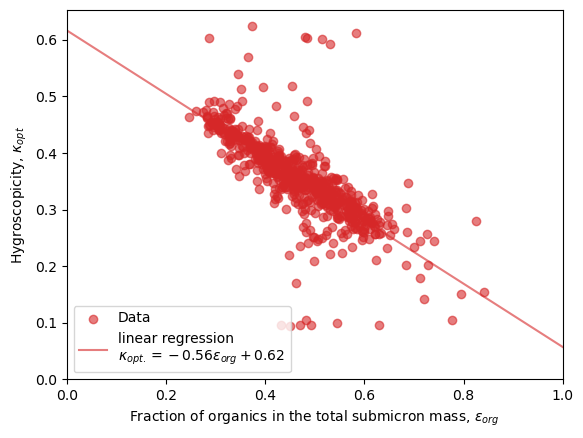

In [91]:
from scipy.stats import linregress

with pd.HDFStore('../Data/AMS.hdf5',mode='r') as store:
    AMS = store['dataset']
AMS=AMS.resample('300S').mean()

varx=(Functions_Neuberger26.keepData(AMS,nofog_times['starttime_nofog'],nofog_times['endtime_nofog']).loc[:,'OA (ug/m3)']/Functions_Neuberger26.keepData(AMS,nofog_times['starttime_nofog'],nofog_times['endtime_nofog']).loc[:,'OA (ug/m3)':'Cl (ug/m3)'].sum(axis=1)).resample('4800S').mean()
vary=Functions_Neuberger26.keepData(kappa_opt,nofog_times['starttime_nofog'],nofog_times['endtime_nofog']).loc[:,'k2'].resample('300S').mean().resample('4800S').mean()
nanmask=~np.isnan(varx)&~np.isnan(vary)
slope, intercept, r_value, p_value, std_err = linregress(varx[nanmask],vary[nanmask])

plt.figure()
plt.scatter(varx[nanmask],vary[nanmask],c='C3',alpha=0.6,label='Data')
plt.plot(np.linspace(0,1,10),slope*np.linspace(0,1,10)+intercept,c='C3',alpha=0.6, 
         label='linear regression \n$\kappa_{opt.}=%.2f\epsilon_{org}+%.2f$'%(slope,intercept))
plt.xlabel('Fraction of organics in the total submicron mass, $\epsilon_{org}$')
plt.ylabel('Hygroscopicity, $\kappa_{opt}$')
plt.legend(loc='lower left')
plt.xlim(0,1)
plt.ylim(0,)
#plt.savefig('Fig_S2.png',bbox_inches='tight',dpi=300)

print(slope*1+intercept)

In [ ]:
# Fig S3 made by Rahul Ranjan

Text(0, 0.5, 'Dry aerosol number concentration (integrated, cm$^{-3}$)')

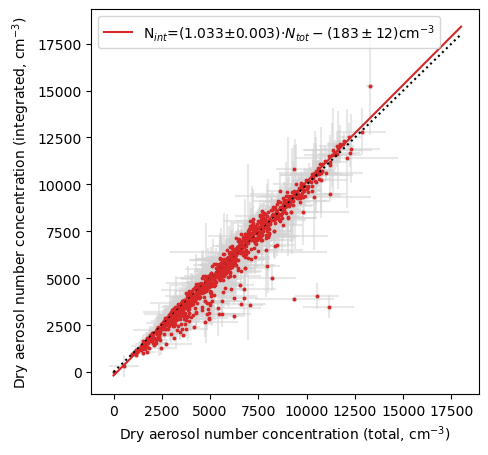

In [92]:
varx=Functions_Neuberger26.keepData(DMPS_R['Ntot_cpc'],nofog_times['starttime_nofog'],nofog_times['endtime_nofog']).resample('1H').mean()
stdvarx=Functions_Neuberger26.keepData(DMPS_R['Ntot_cpc'],nofog_times['starttime_nofog'],nofog_times['endtime_nofog']).resample('1H').std()
vary=Functions_Neuberger26.keepData(DMPS_R['Ntot_int'],nofog_times['starttime_nofog'],nofog_times['endtime_nofog']).resample('1H').mean()
stdvary=Functions_Neuberger26.keepData(DMPS_R['Ntot_int'],nofog_times['starttime_nofog'],nofog_times['endtime_nofog']).resample('1H').std()
nanmask= ~np.isnan(varx) & ~np.isnan(vary)

fig,ax=plt.subplots(figsize=(5,5))
ax.errorbar(varx[nanmask],vary[nanmask],
            xerr=stdvarx[nanmask],yerr=stdvary[nanmask],fmt='.',c='lightgray',alpha=0.5,zorder=1)
ax.scatter(varx[nanmask],vary[nanmask],s=3,c='C3',zorder=2)
a_bivar,b_bivar,S,cov = Functions_Neuberger26.bivariate_fit(varx[nanmask],vary[nanmask],
                                                stdvarx[nanmask],stdvary[nanmask])
ax_york = ax.plot(np.linspace(0,18000,10), b_bivar*np.linspace(0,18000,10)+a_bivar, c='C3',zorder=3,
                   label='N$_{{int}}$=({:1.3f}$\pm${:1.3f})$\cdot N_{{tot}}-({{{:1.0f}\pm{:1.0f}}})$cm$^{{-3}}$'.format(b_bivar,cov[0][0]**0.5,-1*a_bivar,cov[1][1]**0.5))
plt.plot([0,18000],[0,18000],c='black',ls=':')
plt.legend()
plt.xlabel('Dry aerosol number concentration (total, cm$^{-3}$)')
plt.ylabel('Dry aerosol number concentration (integrated, cm$^{-3}$)')
#plt.savefig('Fig_S4.png',bbox_inches='tight',dpi=300)


SignificanceResult(statistic=0.8186915135687336, pvalue=5.008853658829876e-109)


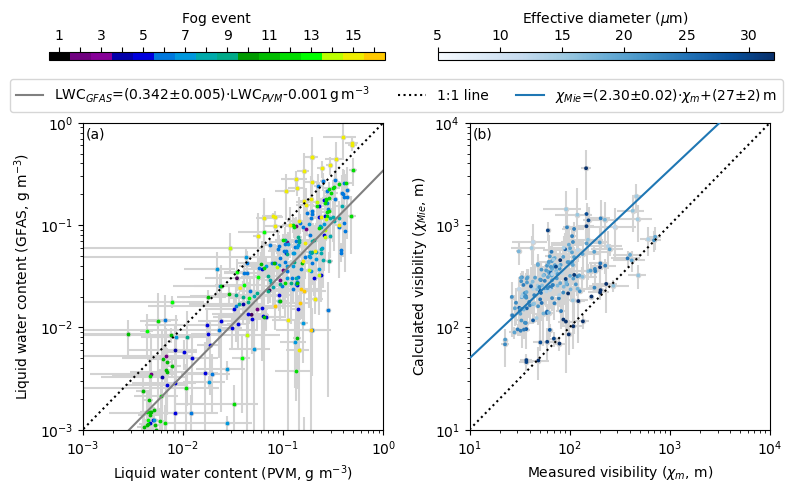

In [93]:
# LWC GFAS-PVM
import matplotlib.colors as mcolors
import matplotlib.cm as cm
resample_S=600

# Create a colormap and normalization object
cmap = plt.get_cmap('Blues')
norm = mcolors.Normalize(vmin=5, vmax=32)  # Set the range of values for the colormap, 10.19995904384029 - 31.59543437031563

# Create a ScalarMappable to convert values into color
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required for colorbar

N = 21
test_cmaps = ['nipy_spectral']
segmented_cmaps = [mpl.colors.ListedColormap(plt.get_cmap(t)(np.linspace(0,1,N))) for t in test_cmaps]

vara=Functions_Neuberger26.keepData(LWC_processed_corrected.resample('60S').mean(),fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].resample('%iS'%resample_S).mean()
varb=Functions_Neuberger26.keepData(LWC_processed_corrected.resample('60S').mean(),fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'Volume Conc (um^3/cc)'].resample('%iS'%resample_S).mean()
stdvara=Functions_Neuberger26.keepData(LWC_processed_corrected.resample('60S').mean(),fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].resample('%iS'%resample_S).std()
stdvarb=Functions_Neuberger26.keepData(LWC_processed_corrected.resample('60S').mean(),fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'Volume Conc (um^3/cc)'].resample('%iS'%resample_S).std()
nanmaska=~np.isnan(vara)&~np.isnan(varb)
print(stats.spearmanr(vara[nanmaska], varb[nanmaska], nan_policy='omit'))

# # Visibility LWC
vary=Functions_Neuberger26.keepData(GCVI.resample('60S').mean(),fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog'])['visiblty'].resample('%iS'%resample_S).mean()
stdvary=Functions_Neuberger26.keepData(GCVI.resample('60S').mean(),fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog'])['visiblty'].resample('%iS'%resample_S).std()

# Visibility Mie GFAS
varz=Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean(),fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty_Mie_GFAS'].resample('%iS'%resample_S).mean()
stdvarz=Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean(),fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty_Mie_GFAS'].resample('%iS'%resample_S).std()
nanmaskz=~np.isnan(vary)&~np.isnan(varz)

# ED
varc=Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean(),fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED_D_Sact'].resample('%iS'%resample_S).mean()
nanmaskc=~np.isnan(vara)&~np.isnan(varb)&~np.isnan(varc)
nanmaskcz=~np.isnan(vary)&~np.isnan(varz)&~np.isnan(varc)

fig,ax=plt.subplots(figsize=(8,4))
ax2=plt.subplot(121)
for i in fog_times.index[:16]:
    ax2.errorbar(vara[nanmaska].loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i]],varb[nanmaska].loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i]],
                 xerr=stdvara[nanmaska].loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i]],yerr=stdvarb[nanmaska].loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i]],
                 fmt='.',c='lightgray',zorder=1)
    ax2.scatter(vara[nanmaska].loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i]],
                varb[nanmaska].loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i]],
                s=3,c=segmented_cmaps[0](i),zorder=2)
a_bivar,b_bivar,S,cov = Functions_Neuberger26.bivariate_fit(vara[nanmaska],varb[nanmaska],stdvara[nanmaska],stdvarb[nanmaska],b0=0.0)
ax_york = ax2.plot(np.array([0,1]), b_bivar*np.array([0,1]) + a_bivar, c='gray',
                   label='LWC$_{{GFAS}}$=({:1.3f}$\pm${:1.3f})$\cdot$LWC$_{{PVM}}${:1.3f}$\,$g$\,$m$^{{-3}}$'.format(b_bivar,cov[0][0]**0.5,a_bivar))
ax2.plot([0,1],[0,1],c='black',label='1:1 line',ls=':',zorder=3)
ax2.set_xlabel('Liquid water content (PVM, g m$^{-3}$)')
ax2.set_ylabel('Liquid water content (GFAS, g m$^{-3}$)')
ax2.set_xlim(0.001,1)
ax2.set_ylim(0.001,1)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.annotate('(a)',xy=(0.01,0.95), xycoords='axes fraction')

ax3=plt.subplot(122)
for i in fog_times.index[:16]:
    ax3.errorbar(vary[nanmaskcz].loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i]],varz[nanmaskcz].loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i]],
                 xerr=stdvary[nanmaskcz].loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i]],yerr=stdvarz[nanmaskcz].loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i]],
                 fmt='.',c='lightgray',zorder=1)
    ax3.scatter(vary[nanmaskcz].loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i]],
                    varz[nanmaskcz].loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i]],
                    s=3,color=sm.to_rgba(varc[nanmaskcz].loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i]]),zorder=3)
a_bivar,b_bivar,S,cov = Functions_Neuberger26.bivariate_fit(vary[nanmaskz],varz[nanmaskz],stdvary[nanmaskz],stdvarz[nanmaskz],b0=0.0)
ax_york = ax3.plot(np.array([10,2*10**5]), b_bivar*np.array([10,2*10**5]) + a_bivar, c='C0', zorder=5,
                   label='$\chi_{{Mie}}$=({:1.2f}$\pm${:1.2f})$\cdot\chi_m$+({:1.0f}$\pm${:1.0f})$\,$m'.format(b_bivar,cov[0][0]**0.5,a_bivar,cov[1][1]**0.5))
ax3.plot([10,10**4],[10,10**4],c='black',ls=':',zorder=5)
cbar_axes = fig.add_axes([0.55, 1.1, 0.42, 0.02]) 
fig.colorbar(sm,cax=cbar_axes,location='top',orientation='horizontal',label='Effective diameter ($\mu$m)')
ax3.set_xlabel('Measured visibility ($\chi_m$, m)')
ax3.set_ylabel('Calculated visibility ($\chi_{Mie}$, m)')
ax3.set_xscale('log')
ax3.set_yscale('log')
ax3.set_xlim(10,10**4)
ax3.set_ylim(10,10**4)
ax3.annotate('(b)',xy=(0.01,0.95), xycoords='axes fraction')
handles1, labels1 = ax2.get_legend_handles_labels()
handles2, labels2 = ax3.get_legend_handles_labels()
all_handles = handles1 + handles2
all_labels = labels1 + labels2
fig.legend(all_handles, all_labels, bbox_to_anchor=(0.99,1.07), ncol=3)
cax = fig.add_axes([0.064, 1.1, 0.42, 0.02])
cbar=fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.BoundaryNorm(np.linspace(0,1,N), segmented_cmaps[0].N),
                                   cmap=segmented_cmaps[0]),
             cax=cax,location='top', orientation='horizontal')
cbar.ax.set_xticks([0.025,0.075,0.125,0.175,0.225,0.275,0.325,0.375,0.425,0.475,0.525,0.575,0.625,0.675,0.725,0.775,0.825,0.875,0.925,0.975])
cbar.ax.set_xticklabels(np.linspace(1,20,20).astype('int'))
for label in cbar.ax.get_xticklabels()[1::2]:
    label.set_visible(False)
cbar.ax.minorticks_off()
cbar.ax.set_xlim(0,0.8)
cbar.ax.set_xlabel('Fog event')
fig.tight_layout()
#plt.savefig('Fig_S5.png',bbox_inches='tight',dpi=300)


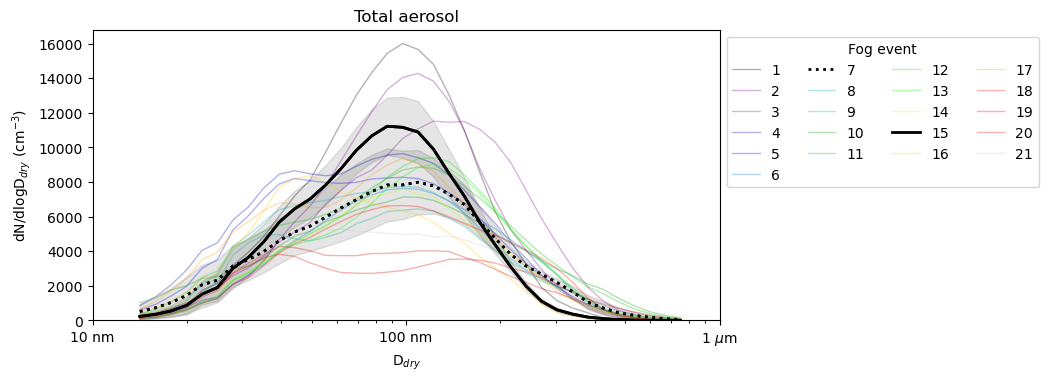

In [94]:
N = 21
test_cmaps = ['nipy_spectral']
segmented_cmaps = [mpl.colors.ListedColormap(plt.get_cmap(t)(np.linspace(0,1,N))) for t in test_cmaps]

fig,ax=plt.subplots(figsize=(7,3.5))
fig.tight_layout()
ax1=plt.subplot(111)
ax1.set_title('Total aerosol')
for i in range(len(fog_times.index)):
    if (i!=6) and (i!=14):
        ax1.plot(Dp_R,DMPS_R.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],:].iloc[:,2:].mean(),
                 c=segmented_cmaps[0](i),label='%i'%(i+1),alpha=0.3,lw=1)
    elif i==6:
        ax1.plot(Dp_R,DMPS_R.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],:].iloc[:,2:].mean(),
                 c='black',label='%i'%(i+1),alpha=1,lw=2,ls=':')
        ax1.fill_between(Dp_R,
                         DMPS_R.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],:].iloc[:,2:].mean()-DMPS_R.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],:].iloc[:,2:].std(),
                         DMPS_R.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],:].iloc[:,2:].mean()+DMPS_R.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],:].iloc[:,2:].std(),
                         color='black',alpha=0.1)
    elif i==14:
        ax1.plot(Dp_R,DMPS_R.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],:].iloc[:,2:].mean(),
                 c='black',label='%i'%(i+1),alpha=1,lw=2,ls='-')
        ax1.fill_between(Dp_R,
                         DMPS_R.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],:].iloc[:,2:].mean()-DMPS_R.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],:].iloc[:,2:].std(),
                         DMPS_R.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],:].iloc[:,2:].mean()+DMPS_R.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],:].iloc[:,2:].std(),
                         color='black',alpha=0.1)
ax1.plot(Dp_R,DMPS_R.loc[fog_times['starttime_fog'][6]:fog_times['endtime_fog'][6],:].iloc[:,2:].mean(),
         c='black',alpha=1,lw=2,ls=':')
ax1.plot(Dp_R,DMPS_R.loc[fog_times['starttime_fog'][14]:fog_times['endtime_fog'][14],:].iloc[:,2:].mean(),
         c='black',alpha=1,lw=2,ls='-')
ax1.set_xlabel('D$_{dry}$')
ax1.set_ylabel('dN/dlogD$_{dry}$ (cm$^{-3}$)')
ax1.set_xlim(10**(-8),10**(-6))
ax1.set_ylim(0,)
ax1.set_xscale('log')
ax1.set_xticks(ticks=[10**(-8),10**(-7),10**(-6)],
               labels=['10 nm','100 nm','1 $\mu$m'])
ax1.legend(title='Fog event',bbox_to_anchor=(1, 1),ncol=4)

#plt.savefig('Fig_S6.png',bbox_inches='tight',dpi=300)


Text(0.65, 0.95, 'At RH=100%')

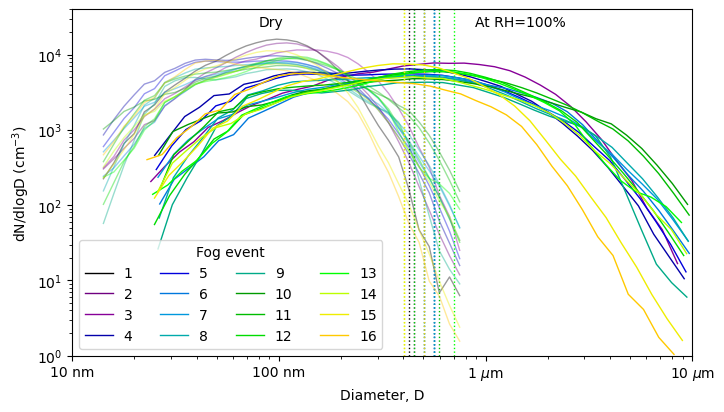

In [95]:
N = 21
test_cmaps = ['nipy_spectral']
segmented_cmaps = [mpl.colors.ListedColormap(plt.get_cmap(t)(np.linspace(0,1,N))) for t in test_cmaps]

Dpmin_R100_opt=0.02*10**(-6)

fig,ax1=plt.subplots(figsize=(8,4.5))
for i in fog_times.index[:16]:
    Dp_R100_opt=(D100_opt.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i]].mean(axis=0)+shift(D100_opt.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i]].mean(axis=0),1,cval=Dpmin_R100_opt))/2
    dlogDp_R100_opt=np.log10(D100_opt.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i]].mean(axis=0))-shift(np.log10(D100_opt.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i]].mean(axis=0)),1,cval=np.nan)
    dlogDp_R100_opt[0]=np.log10(D100_opt.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i]].mean(axis=0).values[0])-np.log10(Dpmin_R100_opt)

    ax1.plot(Dp_R,
             DMPS_R.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],:].iloc[:,2:].mean(axis=0),
             c=segmented_cmaps[0](i),lw=1,alpha=0.4)
    ax1.plot(D100_opt.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],:].mean(axis=0),
             (dlogDp_R*DMPS_R.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],:].iloc[:,2:].mean(axis=0)).values/dlogDp_R100_opt,
             c=segmented_cmaps[0](i),label='%i'%(i+1),lw=1)
    ax1.axvline(x=event.loc[fog_times['starttime_fog'][i]:fog_times['endtime_fog'][i],'D_lact'].median(),
                c=segmented_cmaps[0](i),lw=1,ls=':')
ax1.set_xlabel('Diameter, D')
ax1.set_ylabel('dN/dlogD (cm$^{-3}$)')
ax1.set_xlim(10**(-8),10**(-5))
ax1.set_ylim(10**0,4*10**4)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xticks(ticks=[10**(-8),10**(-7),10**(-6),10**(-5)],labels=['10 nm','100 nm','1 $\mu$m','10 $\mu$m']);
ax1.legend(title='Fog event', ncol=4)
ax1.annotate('Dry',xy=(0.3,0.95), xycoords='axes fraction')
ax1.annotate('At RH=100%',xy=(0.65,0.95), xycoords='axes fraction')
#plt.savefig('Fig_S7.jpg',bbox_inches='tight',dpi=300)


In [ ]:
# Fig S8 + S9 made by Hao Ding

(-0.5, 735.5, 1281.5, -0.5)

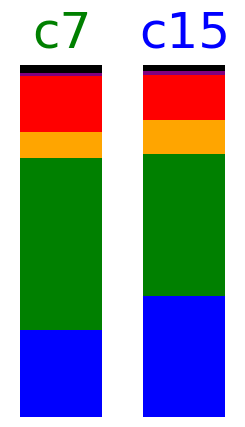

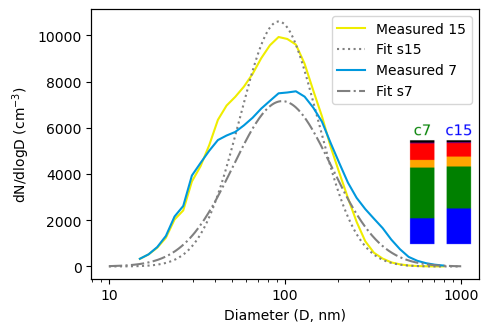

In [96]:
N = 21
test_cmaps = ['nipy_spectral']
segmented_cmaps = [mpl.colors.ListedColormap(plt.get_cmap(t)(np.linspace(0,1,N))) for t in test_cmaps]

ax1=plt.subplot(121)
Functions_Neuberger26.stacked_barchart(ax1, 0.3, AMS.loc[fog_times['starttime_fog'][6]:fog_times['endtime_fog'][6]][['OA (ug/m3)','NO3 (ug/m3)','SO4 (ug/m3)','NH4 (ug/m3)','Cl (ug/m3)','rBC (ug/m3)']].median()/AMS.loc[fog_times['starttime_fog'][6]:fog_times['endtime_fog'][6]][['OA (ug/m3)','NO3 (ug/m3)','SO4 (ug/m3)','NH4 (ug/m3)','Cl (ug/m3)','rBC (ug/m3)']].median().sum(), ['blue','green','orange','red','purple','black'])
Functions_Neuberger26.stacked_barchart(ax1, 0.45, AMS.loc[fog_times['starttime_fog'][14]:fog_times['endtime_fog'][14]][['OA (ug/m3)','NO3 (ug/m3)','SO4 (ug/m3)','NH4 (ug/m3)','Cl (ug/m3)','rBC (ug/m3)']].median()/AMS.loc[fog_times['starttime_fog'][14]:fog_times['endtime_fog'][14]][['OA (ug/m3)','NO3 (ug/m3)','SO4 (ug/m3)','NH4 (ug/m3)','Cl (ug/m3)','rBC (ug/m3)']].median().sum(), ['blue','green','orange','red','purple','black'])
plt.axis('off')
ax1.annotate('c7',xy=(0.265,1.05), xycoords='data',fontsize=36,c='green')
ax1.annotate('c15',xy=(0.395,1.05), xycoords='data',fontsize=36,c='blue')
plt.savefig('/Fig_S10_inlet.png',bbox_inches='tight',dpi=300)


fig,ax=plt.subplots(figsize=(5,3.5))
ax1=plt.subplot(111)
ax1.plot(DMPS_R.loc[fog_times['starttime_fog'][14]:fog_times['endtime_fog'][15],:].iloc[:,2:].columns.astype('float')*10**9,
         DMPS_R.loc[fog_times['starttime_fog'][14]:fog_times['endtime_fog'][15],:].iloc[:,2:].mean(),c=segmented_cmaps[0](14),label='Measured 15')
ax1.plot(np.linspace(10,1000,1000),
         Functions_Neuberger26.lognorm(np.linspace(10,1000,1000), 5850, 1.66, 46*2),c='gray',ls=':',label='Fit s15')
ax1.plot(DMPS_R.loc[fog_times['starttime_fog'][6]:fog_times['endtime_fog'][8],:].iloc[:,2:].columns.astype('float')*10**9,
         DMPS_R.loc[fog_times['starttime_fog'][6]:fog_times['endtime_fog'][8],:].iloc[:,2:].mean(),c=segmented_cmaps[0](6),label='Measured 7')
ax1.plot(np.linspace(10,1000,1000),
         Functions_Neuberger26.lognorm(np.linspace(10,1000,1000), 5000, 1.9, 48.2*2),c='gray',ls='-.',label='Fit s7')
ax0=ax1.twinx()
ax0.get_yaxis().set_visible(False)
ax1.set_xlabel('Diameter (D, nm)')
ax1.set_ylabel('dN/dlogD (cm$^{-3}$)')
ax1.set_xscale('log')
ax1.set_xticks([10,100,1000])
ax1.set_xticklabels([10,100,1000])
ymin,ymax=ax1.get_ylim()
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax0.get_legend_handles_labels()
all_handles = handles1 + handles2
all_labels = labels1 + labels2
ax1.legend(all_handles, all_labels)
newax = fig.add_axes([0.75, 0.2, 0.4, 0.36], anchor='SW')
im = plt.imread('/Fig_S10_inlet.png')
newax.imshow(im)
newax.axis('off')
#plt.savefig('Fig_S10.png',bbox_inches='tight',dpi=300)

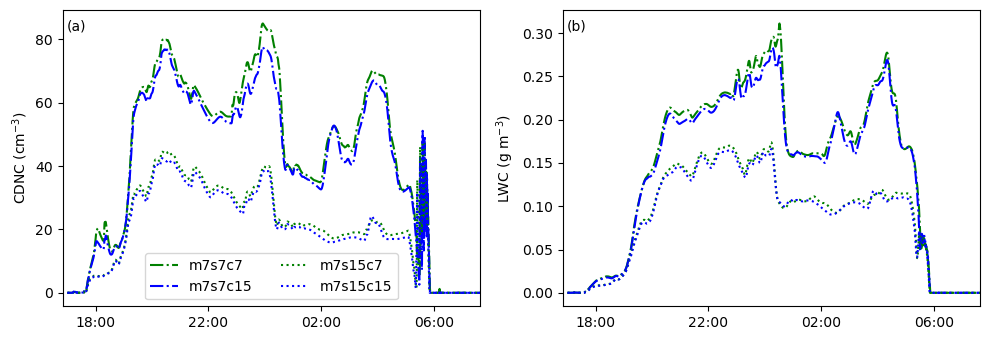

In [97]:
fig,ax=plt.subplots(figsize=(10,3.5))
ax1=plt.subplot(121)
ax1.plot(m6a6c6['Nc']*10**(-6),ls='-.',c='green',label='m7s7c7')
ax1.plot(m6a6c14['Nc']*10**(-6),ls='-.',c='blue',label='m7s7c15')
ax1.plot(m6a14c6['Nc']*10**(-6),ls=':',c='green',label='m7s15c7')
ax1.plot(m6a14c14['Nc']*10**(-6),ls=':',c='blue',label='m7s15c15')
ax1.set_ylabel('CDNC (cm$^{-3}$)')
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=4))
myFmt = mdates.DateFormatter('%H:%M')
ax1.xaxis.set_major_formatter(myFmt)
ax1.set_xlim(fog_times['starttime_fog'][6]-pd.Timedelta('1H'),fog_times['endtime_fog'][8]+pd.Timedelta('1H'))
ax1.legend(loc='lower center',ncols=2)
ax1.annotate('(a)',xy=(0.01,0.93), xycoords='axes fraction')

ax2=plt.subplot(122)
ax2.plot(m6a6c6['Qc']*10**3,ls='-.',c='green',label='m7s7c7')
ax2.plot(m6a6c14['Qc']*10**3,ls='-.',c='blue',label='m7s7c15')
ax2.plot(m6a14c6['Qc']*10**3,ls=':',c='green',label='m7s15c7')
ax2.plot(m6a14c14['Qc']*10**3,ls=':',c='blue',label='m7s15c15')
ax2.set_ylabel('LWC (g m$^{-3}$)')
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=4))
myFmt = mdates.DateFormatter('%H:%M')
ax2.xaxis.set_major_formatter(myFmt)
ax2.set_xlim(fog_times['starttime_fog'][6]-pd.Timedelta('1H'),fog_times['endtime_fog'][8]+pd.Timedelta('1H'))
ax2.annotate('(b)',xy=(0.01,0.93), xycoords='axes fraction')
fig.tight_layout()
#plt.savefig('Fig_S11.png',bbox_inches='tight',dpi=300)

(19046.911177083333, 19047.24252662037)

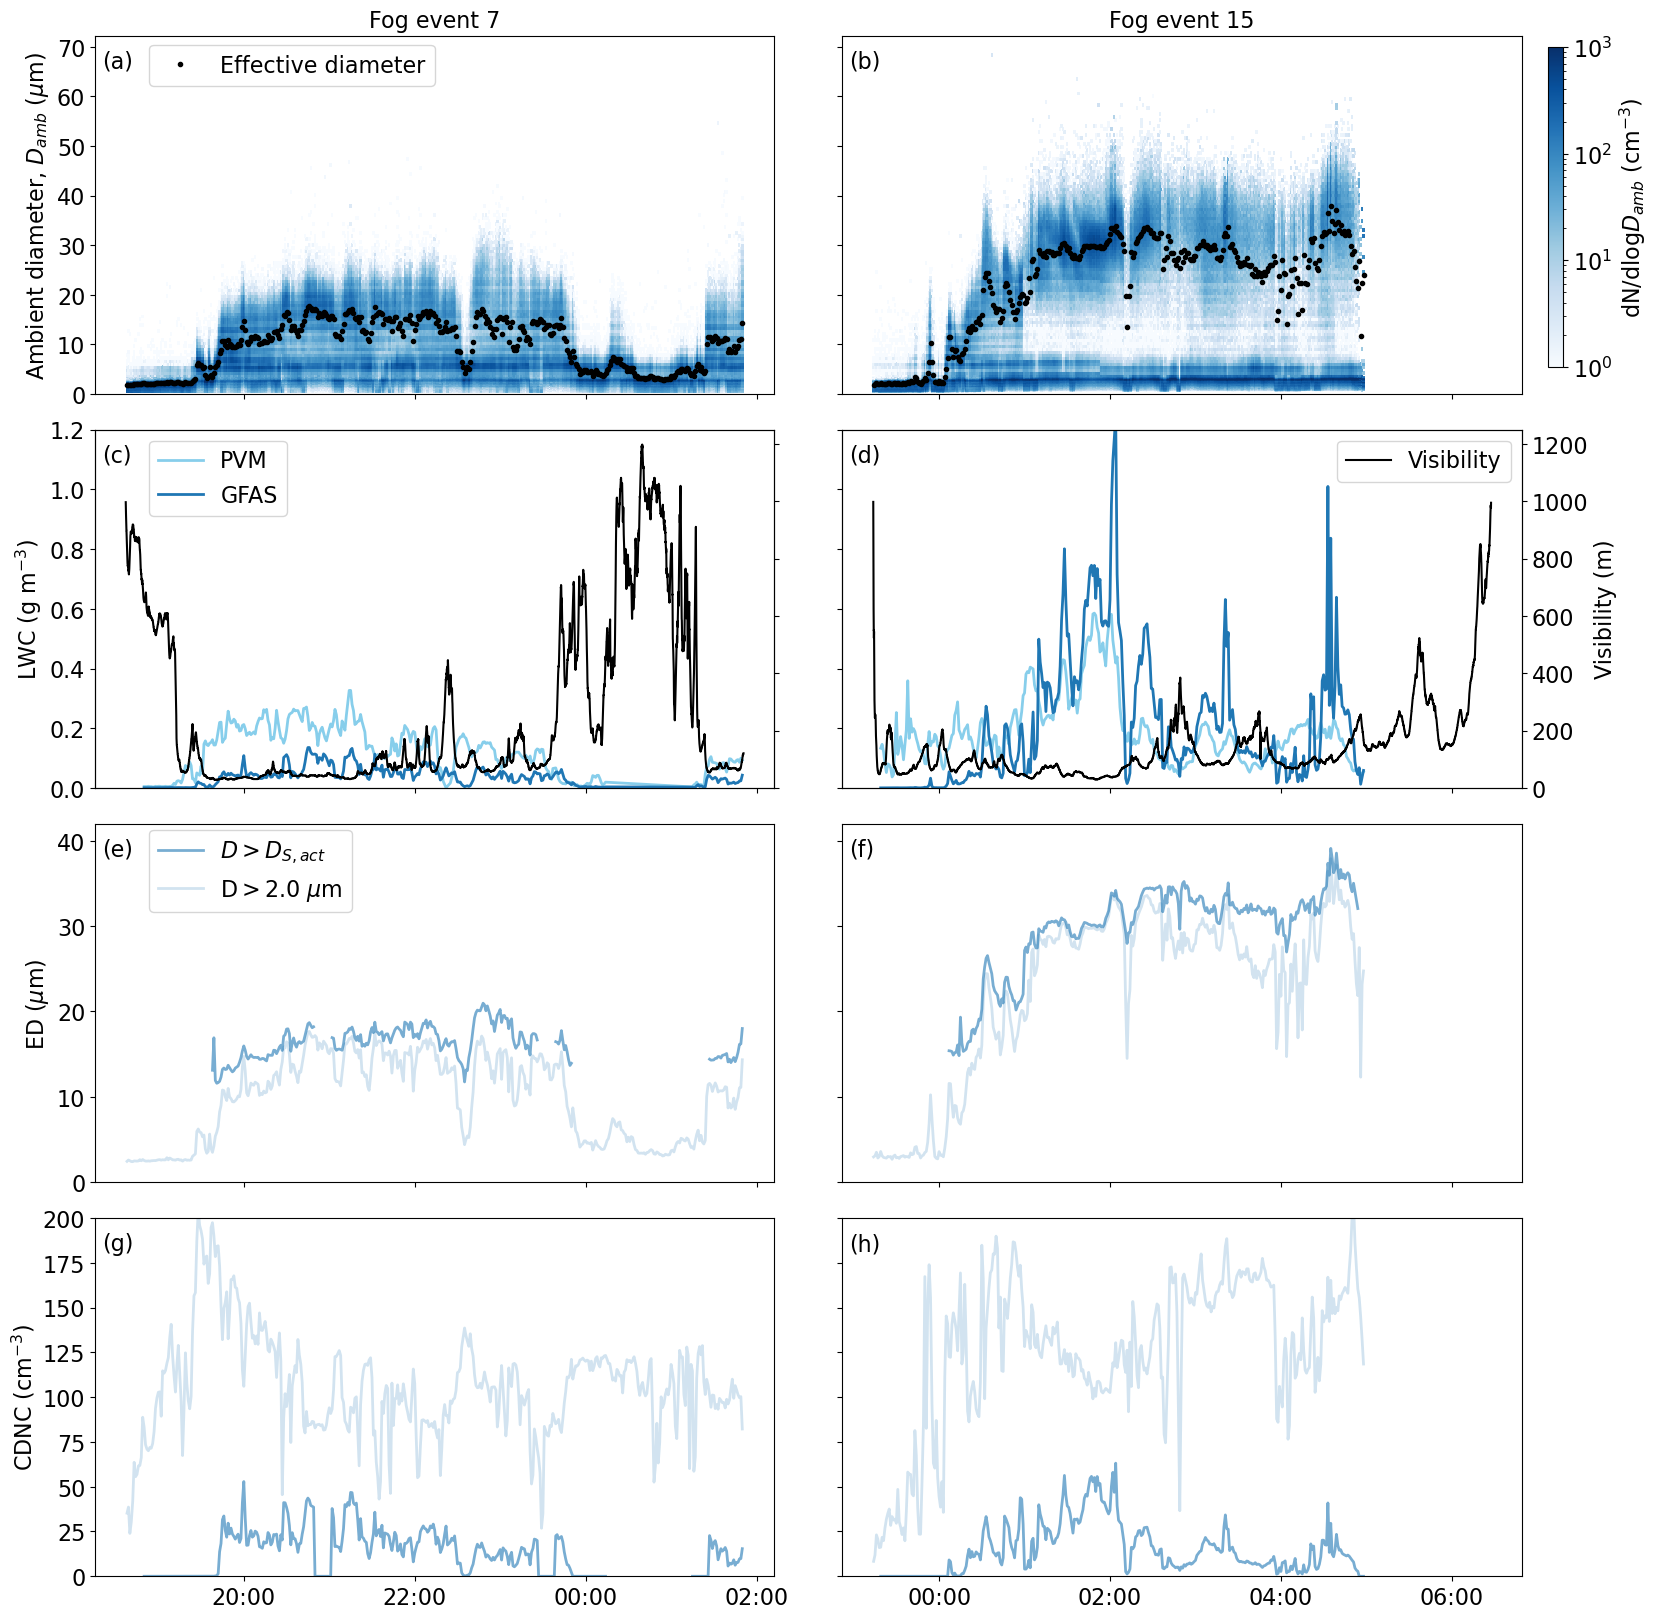

In [98]:
d=0
fig,ax=plt.subplots(figsize=(15,16))
fig.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.1)

i=6
ax9=plt.subplot(421)
x = GFAS_processed_corrected.loc[fog_times['starttime_fog'][i]-pd.Timedelta('768S'):fog_times['starttime_fog'][i]+pd.Timedelta('7H')+pd.Timedelta('58S'),'0.00000005':'0.00007200'].index
y = GFAS_processed_corrected.loc[fog_times['starttime_fog'][i]-pd.Timedelta('768S'):fog_times['starttime_fog'][i]+pd.Timedelta('7H')+pd.Timedelta('58S'),'0.00000005':'0.00007200'].iloc[:,d:].columns.astype(float).values*10**6
z = GFAS_processed_corrected.loc[fog_times['starttime_fog'][i]-pd.Timedelta('768S'):fog_times['starttime_fog'][i]+pd.Timedelta('7H')+pd.Timedelta('58S'),'0.00000005':'0.00007200'].iloc[:,d:].values
X,Y = np.meshgrid(x,y)
Z = z.T
ax9.pcolor(X,Y,Z,norm=colors.LogNorm(vmin=10**0,vmax=10**3),cmap='Blues')
ax9.plot(GFAS_processed_corrected.loc[fog_times['starttime_fog'][i]-pd.Timedelta('768S'):fog_times['starttime_fog'][i]+pd.Timedelta('7H')+pd.Timedelta('58S'),'ED (um)'],c='black',marker='o',markersize=3,linestyle='',label='Effective diameter')
ax9.set_title('Fog event %i'%(i+1),fontsize=16)
ax9.set_ylabel('Ambient diameter, $D_{amb}$ ($\mu$m)',fontsize=16)
ax9.legend(loc=[0.08,0.86],fontsize=16)
ax9.tick_params(axis='both',which='major',labelsize=16)
ax9.set_ylim(0,)
ax9.xaxis.set_major_locator(mdates.HourLocator(interval=2))
myFmt = mdates.DateFormatter('%H:%M')
ax9.xaxis.set_major_formatter(myFmt)
ax9.set_xticklabels('')
ax9.annotate('(a)',xy=(0.01,0.91), xycoords='axes fraction', size=16)

i=14
ax0=plt.subplot(422)
ax0.set_title('Fog event %i'%(i+1),fontsize=16)
x = GFAS_processed_corrected.loc[fog_times['starttime_fog'][i]-pd.Timedelta('297S'):fog_times['starttime_fog'][i]+pd.Timedelta('7H')+pd.Timedelta('529S'),'0.00000005':'0.00007200'].index
y = GFAS_processed_corrected.loc[fog_times['starttime_fog'][i]-pd.Timedelta('297S'):fog_times['starttime_fog'][i]+pd.Timedelta('7H')+pd.Timedelta('529S'),'0.00000005':'0.00007200'].iloc[:,d:].columns.astype(float).values*10**6
z = GFAS_processed_corrected.loc[fog_times['starttime_fog'][i]-pd.Timedelta('297S'):fog_times['starttime_fog'][i]+pd.Timedelta('7H')+pd.Timedelta('529S'),'0.00000005':'0.00007200'].iloc[:,d:].values
X,Y = np.meshgrid(x,y)
Z = z.T
ax0.pcolor(X,Y,Z,norm=colors.LogNorm(vmin=10**0,vmax=10**3),cmap='Blues')
ax0.plot(GFAS_processed_corrected.loc[fog_times['starttime_fog'][i]-pd.Timedelta('297S'):fog_times['starttime_fog'][i]+pd.Timedelta('7H')+pd.Timedelta('529S'),'ED (um)'],c='black',marker='o',markersize=3,linestyle='',label='Effective diameter')
ax0.tick_params(axis='both',which='major',labelsize=16)
ax0.set_ylim(0,)
ax0.xaxis.set_major_locator(mdates.HourLocator(interval=2))
myFmt = mdates.DateFormatter('%H:%M')
ax0.xaxis.set_major_formatter(myFmt)
im = plt.gca().get_children()[0]
cax = fig.add_axes([1,0.78,0.01,0.2])
cbar=fig.colorbar(im,orientation='vertical', cax=cax)
cbar.set_label(label='dN/dlog$D_{amb}$ (cm$^{-3}$)',fontsize=16)
ticks = np.logspace(0,3,4)
cbar.set_ticks(ticks)
cbar.ax.tick_params(axis='both',which='major',labelsize=16)
ax0.set_xticklabels('')
ax0.set_yticklabels('')
ax0.annotate('(b)',xy=(0.01,0.91), xycoords='axes fraction',fontsize=16)

i=6
ax5=plt.subplot(423)
ax5.plot(LWC_processed_corrected.loc[fog_times['starttime_fog'][i]-pd.Timedelta('768S'):fog_times['starttime_fog'][i]+pd.Timedelta('7H')+pd.Timedelta('58S'),'LWC (g m^-3)'],c='skyblue',lw=2,label='PVM')
ax5.plot(LWC_processed_corrected.loc[fog_times['starttime_fog'][i]-pd.Timedelta('768S'):fog_times['starttime_fog'][i]+pd.Timedelta('7H')+pd.Timedelta('58S'),'Volume Conc (um^3/cc)'],c='C0',lw=2,label='GFAS')
ax5.set_ylim(0,1.2)
ax5.legend(loc=[0.08,0.76],fontsize=16)
ax5.set_ylabel('LWC (g m$^{-3}$)',fontsize=16)
ax5.tick_params(axis='both',which='major',labelsize=16)
ax5.xaxis.set_major_locator(mdates.HourLocator(interval=2))
myFmt = mdates.DateFormatter('%H:%M')
ax5.xaxis.set_major_formatter(myFmt)
ax5.set_xticklabels('')
ax6=ax5.twinx()
ax6.plot(GCVI.loc[fog_times['starttime_fog'][i]-pd.Timedelta('768S'):fog_times['starttime_fog'][i]+pd.Timedelta('7H')+pd.Timedelta('58S'),'visiblty'],c='black',label='Visibility')
xmin6,xmax6=ax6.get_xlim()
ax6.set_ylim(0,1250)
ax6.set_yticklabels('')
ax6.tick_params(axis='both',which='major',labelsize=16)
ax5.annotate('(c)',xy=(0.01,0.91), xycoords='axes fraction',fontsize=16)

i=14
ax7=plt.subplot(424)
ax7.plot(LWC_processed_corrected.loc[fog_times['starttime_fog'][i]-pd.Timedelta('297S'):fog_times['starttime_fog'][i]+pd.Timedelta('7H')+pd.Timedelta('529S'),'LWC (g m^-3)'],c='skyblue',lw=2,label='PVM')
ax7.plot(LWC_processed_corrected.loc[fog_times['starttime_fog'][i]-pd.Timedelta('297S'):fog_times['starttime_fog'][i]+pd.Timedelta('7H')+pd.Timedelta('529S'),'Volume Conc (um^3/cc)'],c='C0',lw=2,label='GFAS')
ax7.set_ylim(0,1.2)
ax7.tick_params(axis='both',which='major',labelsize=16)
ax7.xaxis.set_major_locator(mdates.HourLocator(interval=2))
myFmt = mdates.DateFormatter('%H:%M')
ax7.xaxis.set_major_formatter(myFmt)
ax7.set_xticklabels('')
ax7.set_yticklabels('')
ax8=ax7.twinx()
ax8.plot(GCVI.loc[fog_times['starttime_fog'][i]-pd.Timedelta('297S'):fog_times['starttime_fog'][i]+pd.Timedelta('7H')+pd.Timedelta('529S'),'visiblty'],c='black',label='Visibility')
ax8.set_ylabel('Visibility (m)',fontsize=16)
xmin14,xmax14=ax8.get_xlim()
ax8.set_ylim(0,1250)
ax8.legend(loc='upper right',fontsize=16)
ax8.tick_params(axis='both',which='major',labelsize=16)
ax7.annotate('(d)',xy=(0.01,0.91), xycoords='axes fraction', size=16)

i=6
ax1=plt.subplot(425)
ax1.plot(GFAS_processed_corrected.loc[fog_times['starttime_fog'][i]-pd.Timedelta('768S'):fog_times['starttime_fog'][i]+pd.Timedelta('7H')+pd.Timedelta('58S'),'ED_D_Sact'],lw=2,c='C0',alpha=0.6,label='$D>D_{S,act}$')
ax1.plot(GFAS_processed_corrected.loc[fog_times['starttime_fog'][i]-pd.Timedelta('768S'):fog_times['starttime_fog'][i]+pd.Timedelta('7H')+pd.Timedelta('58S'),'ED_2'],lw=2,c='C0',alpha=0.2,label='D$>$2.0 $\mu$m')
ax1.legend(fontsize=16,loc=[0.08,0.755])
ax1.set_ylabel('ED ($\mu$m)',fontsize=16)
ax1.set_xlim(xmin6,xmax6)
ax1.set_ylim(0,42)
ax1.set_xticklabels('')
ax1.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax1.tick_params(axis='both',which='major',labelsize=16)
ax1.annotate('(e)',xy=(0.01,0.91), xycoords='axes fraction',fontsize=16)

i=14
ax2=plt.subplot(426)
ax2.plot(GFAS_processed_corrected.loc[fog_times['starttime_fog'][i]-pd.Timedelta('297S'):fog_times['starttime_fog'][i]+pd.Timedelta('7H')+pd.Timedelta('529S'),'ED_D_Sact'],lw=2,c='C0',alpha=0.6,label='$D>D_{S,act}$')
ax2.plot(GFAS_processed_corrected.loc[fog_times['starttime_fog'][i]-pd.Timedelta('297S'):fog_times['starttime_fog'][i]+pd.Timedelta('7H')+pd.Timedelta('529S'),'ED_2'],lw=2,c='C0',alpha=0.2,label='D$>$2.0 $\mu$m')
ax2.set_xlim(xmin14,xmax14)
ax2.set_ylim(0,42)
ax2.set_xticklabels('')
ax2.set_yticklabels('')
ax2.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax2.tick_params(axis='both',which='major',labelsize=16)
ax2.annotate('(f)',xy=(0.01,0.91), xycoords='axes fraction',fontsize=16)

i=6
ax3=plt.subplot(427)
ax3.plot(GFAS_processed_corrected.loc[fog_times['starttime_fog'][i]-pd.Timedelta('768S'):fog_times['starttime_fog'][i]+pd.Timedelta('7H')+pd.Timedelta('58S'),'Nconc_2'],lw=2,c='C0',alpha=0.2,label='D$>$2.0 $\mu$m')
ax3.plot(GFAS_processed_corrected.loc[fog_times['starttime_fog'][i]-pd.Timedelta('768S'):fog_times['starttime_fog'][i]+pd.Timedelta('7H')+pd.Timedelta('58S'),'Nconc_D_Sact'],lw=2,c='C0',alpha=0.6,label='$D>D_{S,act}$')
ax3.set_ylabel('CDNC (cm$^{-3}$)',fontsize=16)
ax3.set_xlim(xmin6,xmax6)
ax3.set_ylim(0,200)
ax3.xaxis.set_major_locator(mdates.HourLocator(interval=2))
myFmt = mdates.DateFormatter('%H:%M')
ax3.xaxis.set_major_formatter(myFmt)
ax3.set_xticklabels(['20:00','22:00','00:00','02:00'])
ax3.tick_params(axis='both',which='major',labelsize=16)
ax3.annotate('(g)',xy=(0.01,0.91), xycoords='axes fraction',fontsize=16)

i=14
ax4=plt.subplot(428)
ax4.plot(GFAS_processed_corrected.loc[fog_times['starttime_fog'][i]-pd.Timedelta('297S'):fog_times['starttime_fog'][i]+pd.Timedelta('7H')+pd.Timedelta('529S'),'Nconc_2'],lw=2,c='C0',alpha=0.2)
ax4.plot(GFAS_processed_corrected.loc[fog_times['starttime_fog'][i]-pd.Timedelta('297S'):fog_times['starttime_fog'][i]+pd.Timedelta('7H')+pd.Timedelta('529S'),'Nconc_D_Sact'],lw=2,c='C0',alpha=0.6)
ax4.set_xlim(xmin14,xmax14)
ax4.set_ylim(0,200)
ax4.set_yticklabels('')
ax4.xaxis.set_major_locator(mdates.HourLocator(interval=2))
myFmt = mdates.DateFormatter('%H:%M')
ax4.xaxis.set_major_formatter(myFmt)
ax4.set_xticklabels(['00:00','02:00','04:00','06:00'])
ax4.tick_params(axis='both',which='major',labelsize=16)
ax4.annotate('(h)',xy=(0.01,0.91), xycoords='axes fraction',fontsize=16)

ax9.set_xlim(xmin6,xmax6)
ax0.set_xlim(xmin14,xmax14)
#plt.savefig('Fig_S12.png',bbox_inches='tight',dpi=300)


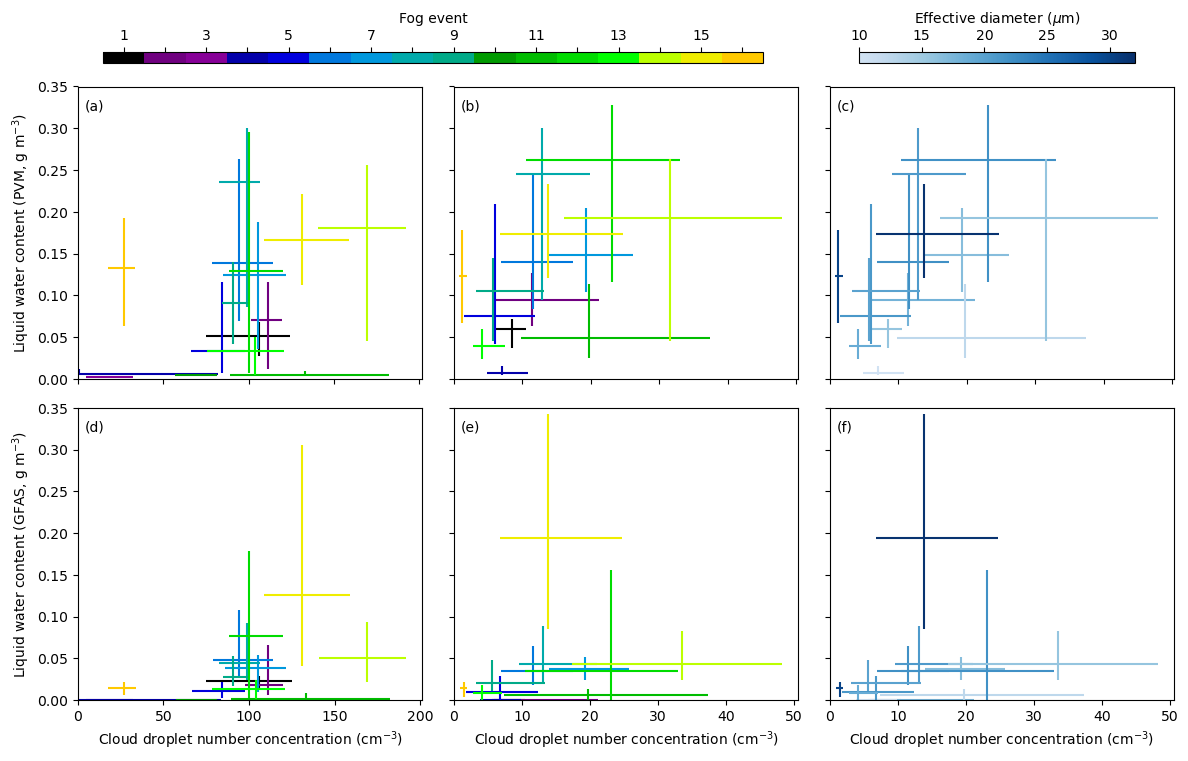

In [99]:
import matplotlib.colors as mcolors
import matplotlib.cm as cm

# Create a colormap and normalization object
cmap = plt.get_cmap('Blues')
norm = mcolors.Normalize(vmin=5, vmax=32)  # Set the range of values for the colormap, 10.19995904384029 - 31.59543437031563

# Create a ScalarMappable to convert values into color
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required for colorbar

N = 21
test_cmaps = ['nipy_spectral']
segmented_cmaps = [mpl.colors.ListedColormap(plt.get_cmap(t)(np.linspace(0,1,N))) for t in test_cmaps]
fig,ax=plt.subplots(figsize=(12,7))
plt.subplots_adjust(wspace=0.35)
ax4=plt.subplot(231)
ax5=plt.subplot(232)
ax6=plt.subplot(233)
ax1=plt.subplot(234)
ax2=plt.subplot(235)
ax3=plt.subplot(236)
for i in fog_times.index[:16]:
    varyG=GFAS_processed_corrected.resample('60S').mean().loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'LWC_2']
    vary=PVM.resample('60S').mean().loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'LWC (g m^-3)']
    varx=GFAS_processed_corrected.resample('60S').mean().loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'Nconc_2']
    nanmaskG=~np.isnan(varx)&~np.isnan(varyG)
    ax1.errorbar(varx[nanmaskG].median(),
                 varyG[nanmaskG].median(),
                 xerr=np.vstack([varx[nanmaskG].median()-varx[nanmaskG].quantile(0.25),
                                 varx[nanmaskG].quantile(0.75)-varx[nanmaskG].median()]),
                 yerr=np.vstack([varyG[nanmaskG].median()-varyG[nanmaskG].quantile(0.25),
                                 varyG[nanmaskG].quantile(0.75)-varyG[nanmaskG].median()]),
                 color=segmented_cmaps[0](i),label='%i'%(i+1))
    vary2G=GFAS_processed_corrected.resample('60S').mean().loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'LWC_activated']
    varx2=GFAS_processed_corrected_fog_fitted_1m.resample('60S').mean().loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'Nconc_DSact'].replace(0,np.nan).dropna()
    nanmaskG2=~np.isnan(varx2)&~np.isnan(vary2G)
    ax2.errorbar(varx2[nanmaskG2].median(),
                 vary2G[nanmaskG2].median(),
                 xerr=np.vstack([varx2[nanmaskG2].median()-varx2[nanmaskG2].quantile(0.25),
                                 varx2[nanmaskG2].quantile(0.75)-varx2[nanmaskG2].median()]),
                 yerr=np.vstack([vary2G[nanmaskG2].median()-vary2G[nanmaskG2].quantile(0.25),
                                 vary2G[nanmaskG2].quantile(0.75)-vary2G[nanmaskG2].median()]),
                 color=segmented_cmaps[0](i))
    varx3=GFAS_processed_corrected_fog_fitted_1m.resample('60S').mean().loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'Nconc_DSact'].replace(0,np.nan).dropna()
    varz3=GFAS_processed_corrected_fog_fitted_1m.resample('60S').mean().loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'ED_DSact'].median()
    nanmaskG3=~np.isnan(varx3)&~np.isnan(vary2G)
    ax3.errorbar(varx3[nanmaskG3].median(),
                 vary2G[nanmaskG3].median(),
                 xerr=np.vstack([varx3[nanmaskG3].median()-varx3[nanmaskG3].quantile(0.25),
                                 varx3[nanmaskG3].quantile(0.75)-varx3[nanmaskG3].median()]),
                 yerr=np.vstack([vary2G[nanmaskG3].median()-vary2G[nanmaskG3].quantile(0.25),
                                 vary2G[nanmaskG3].quantile(0.75)-vary2G[nanmaskG3].median()]),
                 color=sm.to_rgba(varz3))
    nanmask=~np.isnan(varx)&~np.isnan(vary)&~np.isnan(varyG)
    ax4.errorbar(varx[nanmask].median(),
                 vary[nanmask].median(),
                 xerr=np.vstack([varx[nanmask].median()-varx[nanmask].quantile(0.25),
                                 varx[nanmask].quantile(0.75)-varx[nanmask].median()]),
                 yerr=np.vstack([vary[nanmask].median()-vary[nanmask].quantile(0.25),
                                 vary[nanmask].quantile(0.75)-vary[nanmask].median()]),
                 color=segmented_cmaps[0](i),label='%i'%(i+1))
    varx2=GFAS_processed_corrected_fog_fitted_1m.resample('60S').mean().loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'Nconc_DSact'].replace(0,np.nan).dropna()
    nanmask2=~np.isnan(varx2)&~np.isnan(vary)&~np.isnan(varyG)
    ax5.errorbar(varx2[nanmask2].median(),
                 vary[nanmask2].median(),
                 xerr=np.vstack([varx2[nanmask2].median()-varx2[nanmask2].quantile(0.25),
                                 varx2[nanmask2].quantile(0.75)-varx2[nanmask2].median()]),
                 yerr=np.vstack([vary[nanmask2].median()-vary[nanmask2].quantile(0.25),
                                 vary[nanmask2].quantile(0.75)-vary[nanmask2].median()]),
                 color=segmented_cmaps[0](i))
    varx3=GFAS_processed_corrected_fog_fitted_1m.resample('60S').mean().loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'Nconc_DSact'].replace(0,np.nan).dropna()
    varz3=GFAS_processed_corrected_fog_fitted_1m.resample('60S').mean().loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'ED_DSact'].median()
    nanmask3=~np.isnan(varx3)&~np.isnan(vary)&~np.isnan(varyG)
    ax6.errorbar(varx3[nanmask3].median(),
                 vary[nanmask3].median(),
                 xerr=np.vstack([varx3[nanmask3].median()-varx3[nanmask3].quantile(0.25),
                                 varx3[nanmask3].quantile(0.75)-varx3[nanmask3].median()]),
                 yerr=np.vstack([vary[nanmask3].median()-vary[nanmask3].quantile(0.25),
                                 vary[nanmask3].quantile(0.75)-vary[nanmask3].median()]),
                 color=sm.to_rgba(varz3))
ax1.set_xlim(0,)
ax1.set_ylim(0,0.35)
ax1.set_xlabel('Cloud droplet number concentration (cm$^{-3}$)')
ax1.set_ylabel('Liquid water content (GFAS, g m$^{-3}$)')
ax1.annotate('(d)',xy=(0.02,0.92), xycoords='axes fraction')
ax2.set_xlabel('Cloud droplet number concentration (cm$^{-3}$)')
ax2.set_yticklabels([])
ax2.set_xlim(0,)
ax2.set_ylim(0,0.35)
ax2.annotate('(e)',xy=(0.02,0.92), xycoords='axes fraction')
cax = fig.add_axes([0.09, 1.005, 0.55, 0.015])
cbar=fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.BoundaryNorm(np.linspace(0,1,N), segmented_cmaps[0].N),
                                   cmap=segmented_cmaps[0]),
             cax=cax,location='top', orientation='horizontal')
cbar.ax.set_xticks([0.025,0.075,0.125,0.175,0.225,0.275,0.325,0.375,0.425,0.475,0.525,0.575,0.625,0.675,0.725,0.775,0.825,0.875,0.925,0.975])
cbar.ax.set_xticklabels(np.linspace(1,20,20).astype('int'))
for label in cbar.ax.get_xticklabels()[1::2]:
    label.set_visible(False)
cbar.ax.minorticks_off()
cbar.ax.set_xlim(0,0.8)
cbar.ax.set_xlabel('Fog event')
cax2 = fig.add_axes([0.72, 1.005, 0.23, 0.015])
cbar2=fig.colorbar(sm, cax=cax2, location='top',orientation='horizontal',label='Effective diameter ($\mu$m)')
cbar2.ax.set_xlim(10,)
ax3.set_xlabel('Cloud droplet number concentration (cm$^{-3}$)')
ax3.set_yticklabels([])
ax3.set_xlim(0,)
ax3.set_ylim(0,0.35)
ax3.annotate('(f)',xy=(0.02,0.92), xycoords='axes fraction')
ax4.set_ylabel('Liquid water content (PVM, g m$^{-3}$)')
ax4.annotate('(a)',xy=(0.02,0.92), xycoords='axes fraction')
ax5.set_yticklabels([])
ax5.annotate('(b)',xy=(0.02,0.92), xycoords='axes fraction')
ax6.set_yticklabels([])
ax6.annotate('(c)',xy=(0.02,0.92), xycoords='axes fraction')
ax4.set_xticklabels([])
ax5.set_xticklabels([])
ax6.set_xticklabels([])
ax4.set_xlim(0,)
ax4.set_ylim(0,0.35)
ax5.set_xlim(0,)
ax5.set_ylim(0,0.35)
ax6.set_xlim(0,)
ax6.set_ylim(0,0.35)
fig.tight_layout()

#plt.savefig('Fig_S13.jpg',bbox_inches='tight',dpi=300)


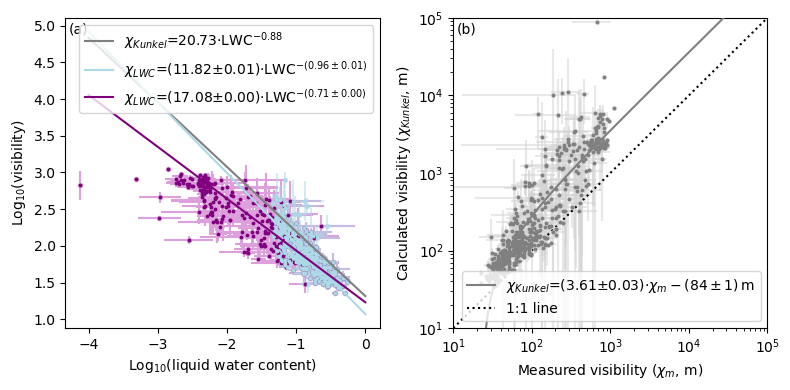

In [100]:
resample_S=600
LWC_thresh_dense=0.08/1.72

varx=Functions_Neuberger26.keepData(PVM.resample('60S').mean(),
                             fog_times_Vis['starttime_fog'],
                             fog_times_Vis['endtime_fog'])['LWC (g m^-3)'].resample('%iS'%resample_S).mean()
stdvarx=Functions_Neuberger26.keepData(PVM.resample('60S').mean(),
                             fog_times_Vis['starttime_fog'],
                             fog_times_Vis['endtime_fog'])['LWC (g m^-3)'].resample('%iS'%resample_S).std()
std10varx=np.log10(Functions_Neuberger26.keepData(PVM.resample('60S').mean(),
                             fog_times_Vis['starttime_fog'],
                             fog_times_Vis['endtime_fog'])['LWC (g m^-3)']).resample('%iS'%resample_S).std()
varx2=Functions_Neuberger26.keepData(PVM[PVM['LWC (g m^-3)']>LWC_thresh_dense].resample('60S').mean(),
                             fog_times_Vis['starttime_fog'],
                             fog_times_Vis['endtime_fog'])['LWC (g m^-3)'].resample('%iS'%resample_S).mean()
stdvarx2=Functions_Neuberger26.keepData(PVM[PVM['LWC (g m^-3)']>LWC_thresh_dense].resample('60S').mean(),
                             fog_times_Vis['starttime_fog'],
                             fog_times_Vis['endtime_fog'])['LWC (g m^-3)'].resample('%iS'%resample_S).std()
std10varx2=np.log10(Functions_Neuberger26.keepData(PVM[PVM['LWC (g m^-3)']>LWC_thresh_dense].resample('60S').mean(),
                             fog_times_Vis['starttime_fog'],
                             fog_times_Vis['endtime_fog'])['LWC (g m^-3)']).resample('%iS'%resample_S).std()
vary=Functions_Neuberger26.keepData(GCVI.resample('60S').mean(),
                            fog_times_Vis['starttime_fog'],
                            fog_times_Vis['endtime_fog'])['visiblty'].resample('%iS'%resample_S).mean()
stdvary=Functions_Neuberger26.keepData(GCVI.resample('60S').mean(),
                            fog_times_Vis['starttime_fog'],
                            fog_times_Vis['endtime_fog'])['visiblty'].resample('%iS'%resample_S).std()
std10vary=np.log10(Functions_Neuberger26.keepData(GCVI.resample('60S').mean(),
                            fog_times_Vis['starttime_fog'],
                            fog_times_Vis['endtime_fog'])['visiblty']).resample('%iS'%resample_S).std()
nanmask=~np.isnan(varx)&~np.isnan(vary)
nanmask2=~np.isnan(varx2)&~np.isnan(vary)
Kunkel=(20.73*Functions_Neuberger26.keepData(PVM.resample('60S').mean(),
                             fog_times_Vis['starttime_fog'],
                             fog_times_Vis['endtime_fog'])['LWC (g m^-3)']**(-0.88)).resample('%iS'%resample_S).mean()
stdKunkel=(20.73*Functions_Neuberger26.keepData(PVM.resample('60S').mean(),
                             fog_times_Vis['starttime_fog'],
                             fog_times_Vis['endtime_fog'])['LWC (g m^-3)']**(-0.88)).resample('%iS'%resample_S).std()

fig,ax=plt.subplots(figsize=(8,4))
ax2=plt.subplot(121)
ax2.plot(np.log10(np.linspace(0.0001,1,100)),np.log10(3/(144.7*np.linspace(0.0001,1,100)**0.88)*1000),label='$\chi_{Kunkel}$=20.73$\cdot$LWC$^{-0.88}$',c='gray',zorder=5)
ax2.errorbar(np.log10(varx2[nanmask2]),np.log10(vary[nanmask2]),xerr=std10varx2[nanmask2],yerr=std10vary[nanmask2],fmt='.',c='lightblue',alpha=0.5,zorder=2)
ax2.scatter(np.log10(varx2[nanmask2]),np.log10(vary[nanmask2]),s=3,c='lightblue',zorder=4)
a_bivar_exp2,b_bivar2,S2,cov2 = Functions_Neuberger26.bivariate_fit(np.log10(varx2[nanmask2]),np.log10(vary[nanmask2]),
                                                std10varx2[nanmask2],std10vary[nanmask2],b0=0.0)
a_bivar2 = 10**(a_bivar_exp2)   # recover a from log10(a)
ax_york2 = ax2.plot(np.log10(np.linspace(0.0001,1,100)), b_bivar2*np.log10(np.linspace(0.0001,1,100)) + np.log10(a_bivar2), c='lightblue',zorder=5,
                   label='$\chi_{{LWC}}$=({:1.2f}$\pm${:1.2f})$\cdot$LWC$^{{-({:1.2f}\pm{:1.2f})}}$'.format(a_bivar2,cov2[1][1]**0.5,-1*b_bivar2,cov2[0][0]**0.5))
ax2.errorbar(np.log10(varx[nanmask]),np.log10(vary[nanmask]),xerr=std10varx[nanmask],yerr=std10vary[nanmask],fmt='.',c='plum',zorder=1)
ax2.scatter(np.log10(varx[nanmask]),np.log10(vary[nanmask]),s=3,c='purple',zorder=3)
a_bivar_exp,b_bivar,S,cov = Functions_Neuberger26.bivariate_fit(np.log10(varx[nanmask]),np.log10(vary[nanmask]),
                                                std10varx[nanmask],std10vary[nanmask],b0=0.0)
a_bivar = 10**(a_bivar_exp)   # recover a from log10(a)
ax_york = ax2.plot(np.log10(np.linspace(0.0001,1,100)), b_bivar*np.log10(np.linspace(0.0001,1,100)) + np.log10(a_bivar), c='purple',zorder=5,
                   label='$\chi_{{LWC}}$=({:1.2f}$\pm${:1.2f})$\cdot$LWC$^{{-({:1.2f}\pm{:1.2f})}}$'.format(a_bivar,cov[1][1]**0.5,-1*b_bivar,cov[0][0]**0.5))
ax2.set_xlabel('Log$_{10}$(liquid water content)')
ax2.set_ylabel('Log$_{10}$(visibility)')
ax2.legend()
ax2.annotate('(a)',xy=(0.01,0.95), xycoords='axes fraction')
ax=plt.subplot(122)
ax.errorbar(vary[nanmask],Kunkel[nanmask],
            xerr=stdvary[nanmask],yerr=stdKunkel[nanmask],fmt='.',c='lightgray',alpha=0.5,zorder=2)
ax.scatter(vary[nanmask],Kunkel[nanmask],s=3,c='gray',zorder=4)
a_bivar,b_bivar,S,cov = Functions_Neuberger26.bivariate_fit(vary[nanmask],Kunkel[nanmask],
                                                stdvary[nanmask],stdKunkel[nanmask])
ax_york = ax.plot(np.linspace(10,10**5,100000), b_bivar*np.linspace(10,10**5,100000)+a_bivar, c='gray',zorder=5,
                   label='$\chi_{{Kunkel}}$=({:1.2f}$\pm${:1.2f})$\cdot\chi_{{m}}-({{{:1.0f}\pm{:1.0f}}})\,$m'.format(b_bivar,cov[0][0]**0.5,-1*a_bivar,cov[1][1]**0.5))
ax.plot([10,2*10**5],[10,2*10**5],c='black',ls=':',label='1:1 line')
ax.set_xlabel('Measured visibility ($\chi_m$, m)')
ax.set_ylabel('Calculated visibility ($\chi_{{Kunkel}}$, m)')
ax.set_xlim(10,10**5)
ax.set_ylim(10,10**5)
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend(loc='lower right')
ax.annotate('(b)',xy=(0.01,0.95), xycoords='axes fraction')
fig.tight_layout()
#plt.savefig('Fig_S14.jpg',bbox_inches='tight',dpi=300)


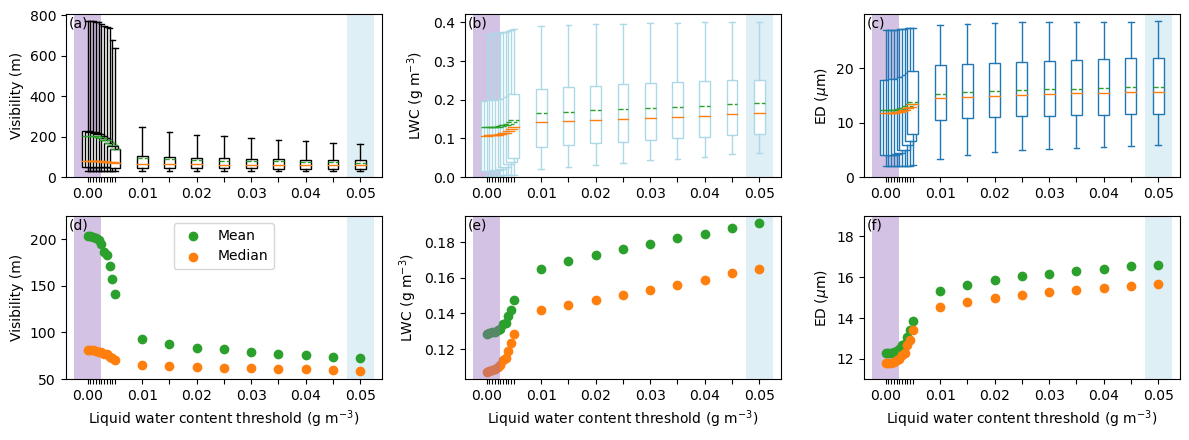

In [101]:
import matplotlib.ticker as ticker
LWC_thresholds_s=np.linspace(0,0.01,11)/2
LWC_thresholds=np.linspace(0.02,0.1,9)/2

fig,ax=plt.subplots(figsize=(12,4.5))
fig.tight_layout()
ax1 = plt.subplot(231)
for i in range(len(LWC_thresholds_s)):
    ax1.boxplot(Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc['2022-02-08':'2022-04-03','LWC (g m^-3)']>LWC_thresholds_s[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].values, 
                    positions = [LWC_thresholds_s[i]],showfliers=False,widths=0.002,whis=[5,95],meanline=True,showmeans=True,
                   patch_artist=True, boxprops=dict(color='black',facecolor='white'),whiskerprops=dict(color='black'),capprops=dict(color='black'))
for i in range(len(LWC_thresholds)):
    ax1.boxplot(Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc['2022-02-08':'2022-04-03','LWC (g m^-3)']>LWC_thresholds[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].values, 
                    positions = [LWC_thresholds[i]],showfliers=False,widths=0.002,whis=[5,95],meanline=True,showmeans=True,
                   patch_artist=True, boxprops=dict(color='black',facecolor='white'),whiskerprops=dict(color='black'),capprops=dict(color='black'))
ax1.axvspan(-0.0025,0.0025,alpha=0.4,color='C4',lw=0)
ax1.axvspan(0.0475,0.0525,alpha=0.4,color='lightblue',lw=0)
ax1.set_ylabel('Visibility (m)')    
ax1.set_xlim(-0.004,0.054)
ax1.set_ylim(0,)
for label in ax1.xaxis.get_ticklabels()[1:10]:
    label.set_visible(False)
for label in ax1.xaxis.get_ticklabels()[1::2]:
    label.set_visible(False)
ax1.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax1.annotate('(a)',xy=(0.01,0.92), xycoords='axes fraction')

ax2 = plt.subplot(232)
for i in range(len(LWC_thresholds_s)):
    ax2.boxplot(Functions_Neuberger26.keepData(PVM.loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresholds_s[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].values, 
                    positions = [LWC_thresholds_s[i]],showfliers=False,widths=0.002,whis=[5,95],meanline=True,showmeans=True,
                   patch_artist=True, boxprops=dict(color='lightblue',facecolor='white'),whiskerprops=dict(color='lightblue'),capprops=dict(color='lightblue'))
for i in range(len(LWC_thresholds)):
    ax2.boxplot(Functions_Neuberger26.keepData(PVM.loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresholds[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].values, 
                    positions = [LWC_thresholds[i]],showfliers=False,widths=0.002,whis=[5,95],meanline=True,showmeans=True,
                   patch_artist=True, boxprops=dict(color='lightblue',facecolor='white'),whiskerprops=dict(color='lightblue'),capprops=dict(color='lightblue'))
ax2.axvspan(-0.0025,0.0025,alpha=0.4,color='C4',lw=0)
ax2.axvspan(0.0475,0.0525,alpha=0.4,color='lightblue',lw=0)
ax2.set_ylabel('LWC (g m$^{-3}$)')
ax2.set_xlim(-0.004,0.054)
ax2.set_ylim(0,)
for label in ax2.xaxis.get_ticklabels()[1:10]:
    label.set_visible(False)
for label in ax2.xaxis.get_ticklabels()[1::2]:
    label.set_visible(False)
ax2.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax2.annotate('(b)',xy=(0.01,0.92), xycoords='axes fraction')

ax3 = plt.subplot(233)
for i in range(len(LWC_thresholds_s)):
    ax3.boxplot(Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresholds_s[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].dropna().values, 
                    positions = [LWC_thresholds_s[i]],showfliers=False,widths=0.002,whis=[5,95],meanline=True,showmeans=True,
                   patch_artist=True, boxprops=dict(color='C0',facecolor='white'),whiskerprops=dict(color='C0'),capprops=dict(color='C0'))
for i in range(len(LWC_thresholds)):
    ax3.boxplot(Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresholds[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].dropna().values, 
                    positions = [LWC_thresholds[i]],showfliers=False,widths=0.002,whis=[5,95],meanline=True,showmeans=True,
                   patch_artist=True, boxprops=dict(color='C0',facecolor='white'),whiskerprops=dict(color='C0'),capprops=dict(color='C0'))
ax3.axvspan(-0.0025,0.0025,alpha=0.4, color='C4',lw=0)
ax3.axvspan(0.0475,0.0525,alpha=0.4, color='lightblue',lw=0)
ax3.set_ylabel('ED ($\mu$m)')    
ax3.set_xlim(-0.004,0.054)
ax3.set_ylim(0,)
for label in ax3.xaxis.get_ticklabels()[1:10]:
    label.set_visible(False)
for label in ax3.xaxis.get_ticklabels()[1::2]:
    label.set_visible(False)
ax3.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax3.annotate('(c)',xy=(0.01,0.92), xycoords='axes fraction')

ax4 = plt.subplot(234)
ax4.axvspan(-0.0025,0.0025,alpha=0.4,color='C4',lw=0)
ax4.axvspan(0.0475,0.0525,alpha=0.4,color='lightblue',lw=0)
for i in range(len(LWC_thresholds_s)):
    ax4.scatter(LWC_thresholds_s[i],
                Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc['2022-02-08':'2022-04-03','LWC (g m^-3)']>LWC_thresholds_s[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].mean(),
                c='C2',label='Mean')
    ax4.scatter(LWC_thresholds_s[i],
                Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc['2022-02-08':'2022-04-03','LWC (g m^-3)']>LWC_thresholds_s[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].median(),
                c='C1',label='Median')
    if i==0:
        ax4.legend()
for i in range(len(LWC_thresholds)):
    ax4.scatter(LWC_thresholds[i],
                Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc['2022-02-08':'2022-04-03','LWC (g m^-3)']>LWC_thresholds[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].mean(),
                c='C2',label='Mean')
    ax4.scatter(LWC_thresholds[i],
                Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc['2022-02-08':'2022-04-03','LWC (g m^-3)']>LWC_thresholds[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].median(),
                c='C1',label='Median')
ax4.set_xlabel('Liquid water content threshold (g m$^{-3}$)')
ax4.set_ylabel('Visibility (m)')    
ax4.set_xlim(-0.004,0.054)
ax4.set_ylim(50,225)
ax4.set_xticks(np.concatenate((LWC_thresholds_s,LWC_thresholds)))
for label in ax4.xaxis.get_ticklabels()[1:10]:
    label.set_visible(False)
for label in ax4.xaxis.get_ticklabels()[1::2]:
    label.set_visible(False)
ax4.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax4.annotate('(d)',xy=(0.01,0.92), xycoords='axes fraction')

ax5 = plt.subplot(235)
for i in range(len(LWC_thresholds_s)):
    ax5.scatter(LWC_thresholds_s[i],
                Functions_Neuberger26.keepData(PVM.loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresholds_s[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].mean(),
                c='C2',label='Mean')
    ax5.scatter(LWC_thresholds_s[i],
                Functions_Neuberger26.keepData(PVM.loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresholds_s[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].median(),
                c='C1',label='Median')
ax5.axvspan(-0.0025,0.0025,alpha=0.4,color='C4',lw=0)
ax5.axvspan(0.0475,0.0525,alpha=0.4,color='lightblue',lw=0)
for i in range(len(LWC_thresholds)):
    ax5.scatter(LWC_thresholds[i],
                Functions_Neuberger26.keepData(PVM.loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresholds[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].mean(),
                c='C2',label='Mean')
    ax5.scatter(LWC_thresholds[i],
                Functions_Neuberger26.keepData(PVM.loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresholds[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].median(),
                c='C1',label='Median')
ax5.set_xlabel('Liquid water content threshold (g m$^{-3}$)')
ax5.set_ylabel('LWC (g m$^{-3}$)')
ax5.set_xlim(-0.004,0.054)
ax5.set_xticks(np.concatenate((LWC_thresholds_s,LWC_thresholds)))
for label in ax5.xaxis.get_ticklabels()[1:10]:
    label.set_visible(False)
for label in ax5.xaxis.get_ticklabels()[1::2]:
    label.set_visible(False)
ax5.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax5.annotate('(e)',xy=(0.01,0.92), xycoords='axes fraction')

ax6 = plt.subplot(236)
ax6.axvspan(-0.0025,0.0025,alpha=0.4,color='C4',lw=0)
ax6.axvspan(0.0475,0.0525,alpha=0.4,color='lightblue',lw=0)
for i in range(len(LWC_thresholds_s)):
    ax6.scatter(LWC_thresholds_s[i],
                Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresholds_s[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].mean(),
                c='C2',label='Mean')
    ax6.scatter(LWC_thresholds_s[i],
                Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresholds_s[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].median(),
                c='C1',label='Median')
for i in range(len(LWC_thresholds)):
    ax6.scatter(LWC_thresholds[i],
                Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresholds[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].mean(),
                c='C2',label='Mean')
    ax6.scatter(LWC_thresholds[i],
                Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],:][PVM.loc[GFAS_processed_corrected.index[0]:GFAS_processed_corrected.index[-1],'LWC (g m^-3)']>LWC_thresholds[i]].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].median(),
                c='C1',label='Median')
ax6.set_xlabel('Liquid water content threshold (g m$^{-3}$)')
ax6.set_ylabel('ED ($\mu$m)')    
ax6.set_xlim(-0.004,0.054)
ax6.set_ylim(11,19)
ax6.set_xticks(np.concatenate((LWC_thresholds_s,LWC_thresholds)))
for label in ax6.xaxis.get_ticklabels()[1:10]:
    label.set_visible(False)
for label in ax6.xaxis.get_ticklabels()[1::2]:
    label.set_visible(False)
ax6.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
ax6.annotate('(f)',xy=(0.01,0.92), xycoords='axes fraction')

fig.tight_layout()
#plt.savefig('Fig_S15.png',bbox_inches='tight',dpi=300)


Text(0.01, 0.92, '(f)')

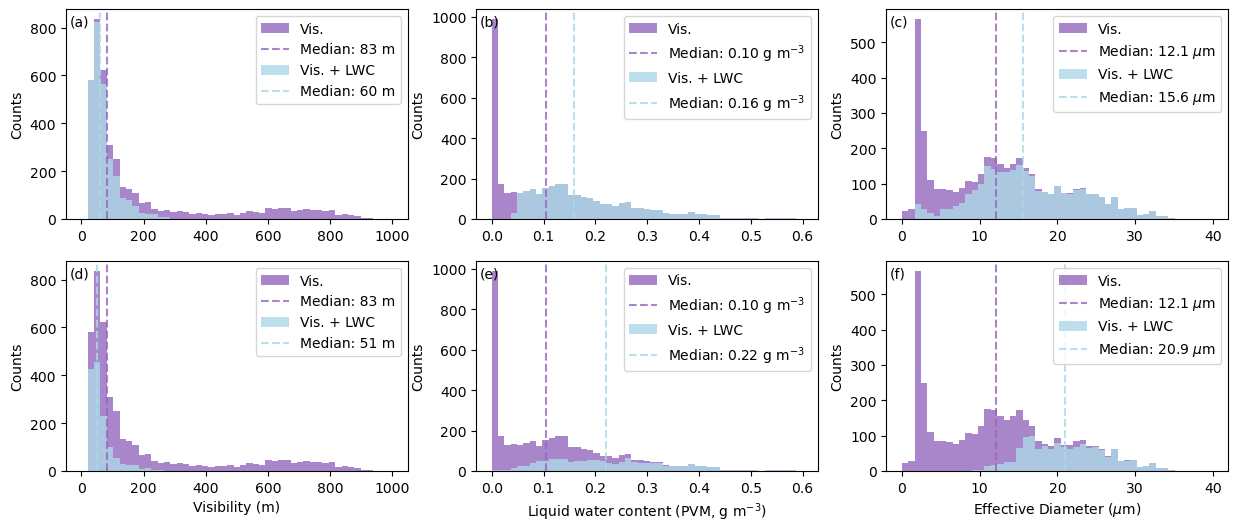

In [102]:
fig,ax=plt.subplots(figsize=(15,6))
ax1 = plt.subplot(231)
ax1.hist(Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>=0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'],
         bins=np.linspace(0,1000,50),color='C4',label='Vis.',alpha=0.8);
ax1.axvline(x=Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>=0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].median(),
            label='Median: %.0f m'%Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>=0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].median(),
            c='C4',ls='--',alpha=0.8)
ax1.hist(Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'],
         bins=np.linspace(0,1000,50),color='lightblue',label='Vis. + LWC',alpha=0.8);
ax1.axvline(x=Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].median(),
            label='Median: %.0f m'%Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].median(),
            c='lightblue',ls='--',alpha=0.8)
ax1.legend()
ax1.set_ylabel('Counts')
ax1.annotate('(a)',xy=(0.01,0.92), xycoords='axes fraction')

ax3 = plt.subplot(232)
ax3.hist(Functions_Neuberger26.keepData(PVM.loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>=0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'],
         bins=np.linspace(0,0.6,50),color='C4',label='Vis.',alpha=0.8);
ax3.axvline(x=Functions_Neuberger26.keepData(PVM.loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>=0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].median(),
            label='Median: %.2f g m$^{-3}$'%Functions_Neuberger26.keepData(PVM.loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>=0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].median(),
            c='C4',ls='--',alpha=0.8)
ax3.hist(Functions_Neuberger26.keepData(PVM.loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'],
         bins=np.linspace(0,0.6,50),color='lightblue',label='Vis. + LWC',alpha=0.8);
ax3.axvline(x=Functions_Neuberger26.keepData(PVM.loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].median(),
            label='Median: %.2f g m$^{-3}$'%Functions_Neuberger26.keepData(PVM.loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].median(),
            c='lightblue',ls='--',alpha=0.8)
ax3.legend()
ax3.set_ylabel('Counts')
ax3.annotate('(b)',xy=(0.01,0.92), xycoords='axes fraction')

ax2 = plt.subplot(233)
ax2.hist(Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>=0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'],
         bins=np.linspace(0,40,50),color='C4',label='Vis.',alpha=0.8);
ax2.axvline(x=Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>=0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].median(),
            label='Median: %.1f $\mu$m'%Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>=0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].median(),
            c='C4',ls='--',alpha=0.8)
ax2.hist(Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'],
         bins=np.linspace(0,40,50),color='lightblue',label='Vis. + LWC',alpha=0.8);
ax2.axvline(x=Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].median(),
            label='Median: %.1f $\mu$m'%Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['LWC (g m^-3)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].median(),
            c='lightblue',ls='--',alpha=0.8)
ax2.legend()
ax2.set_ylabel('Counts')
ax2.annotate('(c)',xy=(0.01,0.92), xycoords='axes fraction')


ax4 = plt.subplot(234)
ax4.hist(Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'],
         bins=np.linspace(0,1000,50),color='C4',label='Vis.',alpha=0.8);
ax4.axvline(x=Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].median(),
            label='Median: %.0f m'%Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].median(),
            c='C4',ls='--',alpha=0.8)
ax4.hist(Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'],
         bins=np.linspace(0,1000,50),color='lightblue',label='Vis. + LWC',alpha=0.8);
ax4.axvline(x=Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].median(),
            label='Median: %.0f m'%Functions_Neuberger26.keepData(GCVI.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'visiblty'].median(),
            c='lightblue',ls='--',alpha=0.8)
ax4.legend()
ax4.set_xlabel('Visibility (m)')
ax4.set_ylabel('Counts')
ax4.annotate('(d)',xy=(0.01,0.92), xycoords='axes fraction')

ax6 = plt.subplot(235)
ax6.hist(Functions_Neuberger26.keepData(PVM.loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'],
         bins=np.linspace(0,0.6,50),color='C4',label='Vis.',alpha=0.8);
ax6.axvline(x=Functions_Neuberger26.keepData(PVM.loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].median(),
            label='Median: %.2f g m$^{-3}$'%Functions_Neuberger26.keepData(PVM.loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].median(),
            c='C4',ls='--',alpha=0.8)
ax6.hist(Functions_Neuberger26.keepData(PVM.loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'],
         bins=np.linspace(0,0.6,50),color='lightblue',label='Vis. + LWC',alpha=0.8);
ax6.axvline(x=Functions_Neuberger26.keepData(PVM.loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].median(),
            label='Median: %.2f g m$^{-3}$'%Functions_Neuberger26.keepData(PVM.loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'LWC (g m^-3)'].median(),
            c='lightblue',ls='--',alpha=0.8)
ax6.legend()
ax6.set_xlabel('Liquid water content (PVM, g m$^{-3}$)')
ax6.set_ylabel('Counts')
ax6.annotate('(e)',xy=(0.01,0.92), xycoords='axes fraction')

ax5 = plt.subplot(236)
ax5.hist(Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'],
         bins=np.linspace(0,40,50),color='C4',label='Vis.',alpha=0.8);
ax5.axvline(x=Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].median(),
            label='Median: %.1f $\mu$m'%Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>0].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].median(),
            c='C4',ls='--',alpha=0.8)
ax5.hist(Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'],
         bins=np.linspace(0,40,50),color='lightblue',label='Vis. + LWC',alpha=0.8);
ax5.axvline(x=Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].median(),
            label='Median: %.1f $\mu$m'%Functions_Neuberger26.keepData(GFAS_processed_corrected.resample('60S').mean().loc[LWC_processed_corrected.loc[LWC_processed_corrected['Volume Conc (um^3/cc)']>LWC_thresh_dense].index,:],fog_times_Vis['starttime_fog'],fog_times_Vis['endtime_fog']).loc[:,'ED (um)'].median(),
            c='lightblue',ls='--',alpha=0.8)
ax5.legend()
ax5.set_xlabel('Effective Diameter ($\mu$m)')
ax5.set_ylabel('Counts')
ax5.annotate('(f)',xy=(0.01,0.92), xycoords='axes fraction')
#plt.savefig('Fig_S16.png',bbox_inches='tight',dpi=300)


(0.0, 0.8)

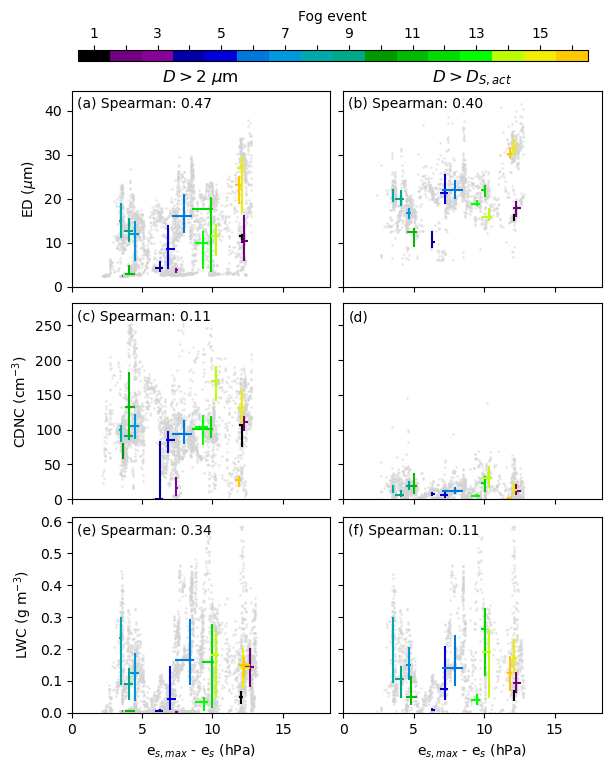

In [104]:
N = 21
test_cmaps = ['nipy_spectral']
segmented_cmaps = [mpl.colors.ListedColormap(plt.get_cmap(t)(np.linspace(0,1,N))) for t in test_cmaps]

p=0.01

# --- NEW: saturation vapor pressure function (T in °C -> e_s in hPa) ---
def sat_vapor_pressure(T):
    return 6.112 * np.exp((17.67 * T) / (T + 243.5))

fig,axs=plt.subplots(nrows=3,ncols=2,figsize=(6,7),layout='constrained')
plt.subplots_adjust(wspace=0.15, hspace=0.15)

for i in fog_times.index[:16]:
    # compute Δ saturation vapor pressure series: e_s(max 24h-before) - e_s(current during fog)
    T_max_before = Meteo.loc[fog_times_Vis['starttime_fog'][i]-pd.Timedelta('24H'):fog_times_Vis['starttime_fog'][i],'T_air[C]'].max()
    T_series_during = Meteo.loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'T_air[C]']
    # vectorized ΔSVP series (hPa)
    dSVP = sat_vapor_pressure(T_max_before) - sat_vapor_pressure(T_series_during)

    ED_DSact=GFAS_processed_corrected_fog_fitted_1m.loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'ED_DSact']
    ED_2=GFAS_processed_corrected.loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'ED_2']
    Nconc_DSact=GFAS_processed_corrected_fog_fitted_1m.loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'Nconc_DSact']
    Nconc_2=GFAS_processed_corrected.loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'Nconc_2']
    LWC=PVM.loc[fog_times_Vis['starttime_fog'][i]:fog_times_Vis['endtime_fog'][i],'LWC (g m^-3)']

    # nanmasks use dSVP instead of dT
    nanmask_dSVP_ED_act=~np.isnan(ED_DSact)&~np.isnan(dSVP)
    nanmask_dSVP_ED=~np.isnan(ED_2)&~np.isnan(dSVP)
    nanmask_dSVP_CDNC_act=~np.isnan(Nconc_DSact)&~np.isnan(dSVP)&(Nconc_DSact>0)
    nanmask_dSVP_CDNC=~np.isnan(Nconc_2)&~np.isnan(dSVP)
    nanmask_dSVP_LWC_act=~np.isnan(LWC)&~np.isnan(dSVP)&(Nconc_DSact>0)
    nanmask_dSVP_LWC=~np.isnan(LWC)&~np.isnan(dSVP)

    axs[1,0].errorbar(dSVP[nanmask_dSVP_CDNC].median(),
                      Nconc_2[nanmask_dSVP_CDNC].median(),
                      xerr=np.vstack([dSVP[nanmask_dSVP_CDNC].median()-dSVP[nanmask_dSVP_CDNC].quantile(0.25),
                                      dSVP[nanmask_dSVP_CDNC].quantile(0.75)-dSVP[nanmask_dSVP_CDNC].median()]),
                      yerr=np.vstack([Nconc_2[nanmask_dSVP_CDNC].median()-Nconc_2[nanmask_dSVP_CDNC].quantile(0.25),
                                      Nconc_2[nanmask_dSVP_CDNC].quantile(0.75)-Nconc_2[nanmask_dSVP_CDNC].median()]),
                      c=segmented_cmaps[0](i))
    axs[1,0].scatter(dSVP[nanmask_dSVP_CDNC],Nconc_2[nanmask_dSVP_CDNC],c='lightgrey',alpha=0.4,s=1)
    
    axs[0,0].errorbar(dSVP[nanmask_dSVP_ED].median(),
                      ED_2[nanmask_dSVP_ED].median(),
                      xerr=np.vstack([dSVP[nanmask_dSVP_ED].median()-dSVP[nanmask_dSVP_ED].quantile(0.25),
                                      dSVP[nanmask_dSVP_ED].quantile(0.75)-dSVP[nanmask_dSVP_ED].median()]),
                      yerr=np.vstack([ED_2[nanmask_dSVP_ED].median()-ED_2[nanmask_dSVP_ED].quantile(0.25),
                                      ED_2[nanmask_dSVP_ED].quantile(0.75)-ED_2[nanmask_dSVP_ED].median()]),
                      c=segmented_cmaps[0](i))
    axs[0,0].scatter(dSVP[nanmask_dSVP_ED],ED_2[nanmask_dSVP_ED],c='lightgrey',alpha=0.4,s=1)
    
    axs[2,0].errorbar(dSVP[nanmask_dSVP_LWC].median(),
                      LWC[nanmask_dSVP_LWC].median(),
                      xerr=np.vstack([dSVP[nanmask_dSVP_LWC].median()-dSVP[nanmask_dSVP_LWC].quantile(0.25),
                                      dSVP[nanmask_dSVP_LWC].quantile(0.75)-dSVP[nanmask_dSVP_LWC].median()]),
                      yerr=np.vstack([LWC[nanmask_dSVP_LWC].median()-LWC[nanmask_dSVP_LWC].quantile(0.25),
                                      LWC[nanmask_dSVP_LWC].quantile(0.75)-LWC[nanmask_dSVP_LWC].median()]),
                      c=segmented_cmaps[0](i))
    axs[2,0].scatter(dSVP[nanmask_dSVP_LWC],LWC[nanmask_dSVP_LWC],c='lightgrey',alpha=0.4,s=1)
    
    axs[1,1].errorbar(dSVP[nanmask_dSVP_CDNC_act].median(),
                      Nconc_DSact[nanmask_dSVP_CDNC_act].median(),
                      xerr=np.vstack([dSVP[nanmask_dSVP_CDNC_act].median()-dSVP[nanmask_dSVP_CDNC_act].quantile(0.25),
                                      dSVP[nanmask_dSVP_CDNC_act].quantile(0.75)-dSVP[nanmask_dSVP_CDNC_act].median()]),
                      yerr=np.vstack([Nconc_DSact[nanmask_dSVP_CDNC_act].median()-Nconc_DSact[nanmask_dSVP_CDNC_act].quantile(0.25),
                                      Nconc_DSact[nanmask_dSVP_CDNC_act].quantile(0.75)-Nconc_DSact[nanmask_dSVP_CDNC_act].median()]),
                      c=segmented_cmaps[0](i))
    axs[1,1].scatter(dSVP[nanmask_dSVP_CDNC_act],Nconc_DSact[nanmask_dSVP_CDNC_act],c='lightgrey',alpha=0.4,s=1)
    
    axs[0,1].errorbar(dSVP[nanmask_dSVP_ED_act].median(),
                      ED_DSact[nanmask_dSVP_ED_act].median(),
                      xerr=np.vstack([dSVP[nanmask_dSVP_ED_act].median()-dSVP[nanmask_dSVP_ED_act].quantile(0.25),
                                      dSVP[nanmask_dSVP_ED_act].quantile(0.75)-dSVP[nanmask_dSVP_ED_act].median()]),
                      yerr=np.vstack([ED_DSact[nanmask_dSVP_ED_act].median()-ED_DSact[nanmask_dSVP_ED_act].quantile(0.25),
                                      ED_DSact[nanmask_dSVP_ED_act].quantile(0.75)-ED_DSact[nanmask_dSVP_ED_act].median()]),
                      c=segmented_cmaps[0](i))
    axs[0,1].scatter(dSVP[nanmask_dSVP_ED_act],ED_DSact[nanmask_dSVP_ED_act],c='lightgrey',alpha=0.4,s=1)
    
    axs[2,1].errorbar(dSVP[nanmask_dSVP_LWC_act].median(),
                      LWC[nanmask_dSVP_LWC_act].median(),
                      xerr=np.vstack([dSVP[nanmask_dSVP_LWC_act].median()-dSVP[nanmask_dSVP_LWC_act].quantile(0.25),
                                      dSVP[nanmask_dSVP_LWC_act].quantile(0.75)-dSVP[nanmask_dSVP_LWC_act].median()]),
                      yerr=np.vstack([LWC[nanmask_dSVP_LWC_act].median()-LWC[nanmask_dSVP_LWC_act].quantile(0.25),
                                      LWC[nanmask_dSVP_LWC_act].quantile(0.75)-LWC[nanmask_dSVP_LWC_act].median()]),
                      c=segmented_cmaps[0](i))
    axs[2,1].scatter(dSVP[nanmask_dSVP_LWC_act],LWC[nanmask_dSVP_LWC_act],c='lightgrey',alpha=0.4,s=1)
    
    if i==0:
        dSVP_long=dSVP
        ED_DSact_long=ED_DSact
        ED_2_long=ED_2
        Nconc_DSact_long=Nconc_DSact
        Nconc_2_long=Nconc_2
        LWC_long=LWC
    else:
        dSVP_long=pd.concat([dSVP_long,dSVP],axis=0)
        ED_DSact_long=pd.concat([ED_DSact_long,ED_DSact],axis=0)
        ED_2_long=pd.concat([ED_2_long,ED_2],axis=0)
        Nconc_DSact_long=pd.concat([Nconc_DSact_long,Nconc_DSact],axis=0)
        Nconc_2_long=pd.concat([Nconc_2_long,Nconc_2],axis=0)
        LWC_long=pd.concat([LWC_long,LWC],axis=0)
nanmask_dSVP_ED_act_long=~np.isnan(ED_DSact_long)&~np.isnan(dSVP_long)
nanmask_dSVP_ED2_long=~np.isnan(ED_2_long)&~np.isnan(dSVP_long)
nanmask_dSVP_CDNC_act_long=~np.isnan(Nconc_DSact_long)&~np.isnan(dSVP_long)&(Nconc_DSact_long>0)
nanmask_dSVP_CDNC2_long=~np.isnan(Nconc_2_long)&~np.isnan(dSVP_long)
nanmask_dSVP_LWC_act_long=~np.isnan(LWC_long)&~np.isnan(dSVP_long)&(Nconc_DSact_long>0)
nanmask_dSVP_LWC_long=~np.isnan(LWC_long)&~np.isnan(dSVP_long)

axs[0,0].set_title('$D>2$ $\mu$m')
axs[0,1].set_title('$D>D_{S,act}$')

xmin,xmax=axs[0,0].get_xlim()
for row in range(3):
    for col in range(2):
        axs[row,col].set_xlim(0,xmax+5)
        axs[0,col].set_xticklabels('')
        axs[1,col].set_xticklabels('')
    axs[row,1].set_yticklabels('')
ymin,ymax=axs[0,1].get_ylim()
axs[0,0].set_ylim(0,ymax)
axs[0,1].set_ylim(0,ymax)
ymin,ymax=axs[1,0].get_ylim()
axs[1,0].set_ylim(0,ymax)
axs[1,1].set_ylim(0,ymax)
ymin,ymax=axs[2,1].get_ylim()
axs[2,0].set_ylim(0,ymax)
axs[2,1].set_ylim(0,ymax)


axs[1,0].set_ylabel('CDNC (cm$^{-3}$)')
axs[0,0].set_ylabel('ED ($\mu$m)')
# Updated x-axis labels to indicate Δ saturation vapor pressure (hPa)
axs[2,0].set_xlabel('e$_{s,max}$ - e$_s$ (hPa)')
axs[2,0].set_ylabel('LWC (g m$^{-3}$)')
axs[2,1].set_xlabel('e$_{s,max}$ - e$_s$ (hPa)')

if stats.spearmanr(dSVP_long[nanmask_dSVP_CDNC2_long],Nconc_2_long[nanmask_dSVP_CDNC2_long],nan_policy='omit')[1]<p:
    axs[1,0].annotate('(c) Spearman: %.2f'%stats.spearmanr(dSVP_long[nanmask_dSVP_CDNC2_long],Nconc_2_long[nanmask_dSVP_CDNC2_long],nan_policy='omit')[0],
                        xy=(0.02,0.91), xycoords='axes fraction')
else:
    axs[1,0].annotate('(c)',xy=(0.02,0.91), xycoords='axes fraction')
if stats.spearmanr(dSVP_long[nanmask_dSVP_ED2_long],ED_2_long[nanmask_dSVP_ED2_long],nan_policy='omit')[1]<p:
    axs[0,0].annotate('(a) Spearman: %.2f'%stats.spearmanr(dSVP_long[nanmask_dSVP_ED2_long],ED_2_long[nanmask_dSVP_ED2_long],nan_policy='omit')[0],
                        xy=(0.02,0.91), xycoords='axes fraction')
else:
    axs[0,0].annotate('(a)',xy=(0.02,0.91), xycoords='axes fraction')
if stats.spearmanr(dSVP_long[nanmask_dSVP_LWC_long],LWC_long[nanmask_dSVP_LWC_long],nan_policy='omit')[1]<p:
    axs[2,0].annotate('(e) Spearman: %.2f'%stats.spearmanr(dSVP_long[nanmask_dSVP_LWC_long],LWC_long[nanmask_dSVP_LWC_long],nan_policy='omit')[0],
                        xy=(0.02,0.91), xycoords='axes fraction')
else:
    axs[2,0].annotate('(e)',xy=(0.02,0.91), xycoords='axes fraction')
if stats.spearmanr(dSVP_long[nanmask_dSVP_CDNC_act_long],Nconc_DSact_long[nanmask_dSVP_CDNC_act_long],nan_policy='omit')[1]<p:
    axs[1,1].annotate('(d) Spearman: %.2f'%stats.spearmanr(dSVP_long[nanmask_dSVP_CDNC_act_long],Nconc_DSact_long[nanmask_dSVP_CDNC_act_long],nan_policy='omit')[0],
                        xy=(0.02,0.91), xycoords='axes fraction')
else:
    axs[1,1].annotate('(d)',xy=(0.02,0.91), xycoords='axes fraction')
if stats.spearmanr(dSVP_long[nanmask_dSVP_ED_act_long],ED_DSact_long[nanmask_dSVP_ED_act_long],nan_policy='omit')[1]<p:
    axs[0,1].annotate('(b) Spearman: %.2f'%stats.spearmanr(dSVP_long[nanmask_dSVP_ED_act_long],ED_DSact_long[nanmask_dSVP_ED_act_long],nan_policy='omit')[0],
                        xy=(0.02,0.91), xycoords='axes fraction')
else:
    axs[0,1].annotate('(b)',xy=(0.02,0.91), xycoords='axes fraction')
if stats.spearmanr(dSVP_long[nanmask_dSVP_LWC_act_long],LWC_long[nanmask_dSVP_LWC_act_long],nan_policy='omit')[1]<p:
    axs[2,1].annotate('(f) Spearman: %.2f'%stats.spearmanr(dSVP_long[nanmask_dSVP_LWC_act_long],LWC_long[nanmask_dSVP_LWC_act_long],nan_policy='omit')[0],
                        xy=(0.02,0.91), xycoords='axes fraction')
else:
    axs[2,1].annotate('(f)',xy=(0.02,0.91), xycoords='axes fraction')

cax = fig.add_axes([0.12, 1.005, 0.85, 0.015])
cbar=fig.colorbar(mpl.cm.ScalarMappable(norm=mpl.colors.BoundaryNorm(np.linspace(0,1,N), segmented_cmaps[0].N),
                                   cmap=segmented_cmaps[0]),
             cax=cax,location='top', orientation='horizontal', label='Fog event')
cbar.ax.set_xticks([0.025,0.075,0.125,0.175,0.225,0.275,0.325,0.375,0.425,0.475,0.525,0.575,0.625,0.675,0.725,0.775,0.825,0.875,0.925,0.975])
cbar.ax.set_xticklabels(np.linspace(1,20,20).astype('int'))
for label in cbar.ax.get_xticklabels()[1::2]:
    label.set_visible(False)
cbar.ax.minorticks_off()
cbar.ax.set_xlim(0,0.8)
#plt.savefig('Fig_S17.png', dpi = 300)
